# 3.4 Author Level Topic Modeling LCC (v2: Aligned Cleaning)
Builds author level topic models using LDA, restricted to the Largest Weakly Connected Component (LCC) when available, for clean alignment with author graphs and clustering.

**v2 changes (April 2026):**
- Cleaning function aligned with Ignacio's updated `preprocess()` from notebook 02
- URLs and @mentions **removed entirely** (not replaced with tokens)
- Input: `AItrust_twits_pruned_dict.json` (full AI-only pruned dataset — no sentiment dependency)
- `clean_tweet_text()` applied to raw tweet text inside this notebook
- Verification step: original vs cleaned tweet comparison
- Stopwords: sklearn English base + defensive Twitter artifacts only (no domain terms)


In [2]:
%%time
import os
from pathlib import Path
import sys

# Put repo root on sys.path so `from src.*` works
_REPO_ROOT = str(Path.cwd().resolve().parents[1])
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)

# Explorer / HPC project root
BASE_PATH = Path("/projects/ComputationalPhilosophyLab/TwitterDataAnalysis")

# Pre-compute critical paths used across notebooks
twits_folder = BASE_PATH / "Raw Data" / "Twits"
test_folder = BASE_PATH / "Raw Data"
datasets_folder = BASE_PATH / "Data Sets"
cleanedds_folder = BASE_PATH / "Data Sets" / "Cleaned Data"
networks_folder = BASE_PATH / "Data Sets" / "Networks"
literature_folder = BASE_PATH / "Literature"
topic_models_folder = BASE_PATH / "Models" / "Topic Modeling"

print("BASE_PATH =", BASE_PATH)
print("REPO_ROOT =", _REPO_ROOT)
print("cleanedds_folder exists:", cleanedds_folder.exists())
print("networks_folder exists:", networks_folder.exists())
print("topic_models_folder exists:", topic_models_folder.exists())

BASE_PATH = /projects/ComputationalPhilosophyLab/TwitterDataAnalysis
REPO_ROOT = /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/code/twitter_ai
cleanedds_folder exists: True
networks_folder exists: True
topic_models_folder exists: True


In [3]:
%%time
DATA_DIR = cleanedds_folder
NETWORKS_DIR = networks_folder
LEIDEN_DIR = NETWORKS_DIR / "leiden_runs"

# v2: Use the pruned dict directly (no sentiment dependency)
TWEETS_PATH = DATA_DIR / "TwitterDataAnalysis/Data Sets/Cleaned Data/AItrust_twits_pruned_dict.json"
LCC_GML = NETWORKS_DIR / "LWCC.gml"

# v2: New output directory to compare with previous run
OUT_DIR = topic_models_folder / "LDA" / "author_level" / "full_v2_cleaned"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("TWEETS_PATH :", TWEETS_PATH, "exists:", TWEETS_PATH.exists())
print("LCC_GML     :", LCC_GML, "exists:", LCC_GML.exists())
print("OUT_DIR     :", OUT_DIR)


TWEETS_PATH : /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Data Sets/Cleaned Data/TwitterDataAnalysis/Data Sets/Cleaned Data/AItrust_twits_pruned_dict.json exists: False
LCC_GML     : /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Data Sets/Networks/LWCC.gml exists: True
OUT_DIR     : /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned


In [4]:
%%time
test_lcc = networks_folder / "Test_Network.gml"
print("Test_Network.gml exists:", test_lcc.exists())

Test_Network.gml exists: True


In [5]:
%%time
print("=== Cleaned Data ===")
for f in sorted(cleanedds_folder.iterdir()):
    print(f"  {f.name}")

print("\n=== Networks ===")
for f in sorted(networks_folder.iterdir()):
    print(f"  {f.name}")

=== Cleaned Data ===
  AI_pruned_tweets_with_sentiment_topic_weights.json
  AI_pruned_tweets_with_topic_weights_v2.json
  AItrust_Art_pruned_twit_dict.json
  AItrust_Art_pruned_twit_dict_test.json
  AItrust_Art_twit_dict.json
  AItrust_Art_twit_dict_test.json
  AItrust_author_dict.json
  AItrust_author_dict_test.json
  AItrust_pruned_twits.json
  AItrust_pruned_twits_test.json
  AItrust_pruned_twits_test_classified_twitter-roberta-base-emotion-latest.json
  AItrust_pruned_twits_test_classified_twitter-roberta-base-sentiment-latest.json
  AItrust_pruned_twits_test_with_sentiment.json
  AItrust_pruned_twits_with_sentiment.json
  AItrust_twit_dict.json
  AItrust_twit_dict_test.json
  AItrust_twits_dict.json
  AItrust_twits_dict_test.json
  AItrust_twits_pruned_dict.json
  AItrust_twits_pruned_dict_test.json
  Blocks
  ai_full_classified_twitter-roberta-base-emotion-latest.json
  ai_full_classified_twitter-roberta-base-emotion-multilabel-latest.json
  ai_full_classified_twitter-roberta-bas

In [6]:
%%time
'''
colab setup - keeping while updating for HPC
import os
from pathlib import Path
import sys

# --- ENVIRONMENT SWITCH ---
# Set to True if running on local machine with Google Drive Desktop mounted
# Set to False if running in Google Colab cloud
RUNNING_LOCALLY = False

if RUNNING_LOCALLY:
  # --- REPO ROOT ON sys.path (so `from src.*` works locally) ---
    _REPO_ROOT = str(Path(os.getcwd()).resolve().parents[1])
    if _REPO_ROOT not in sys.path:
        sys.path.insert(0, _REPO_ROOT)
    # Standard macOS path for Google Drive Desktop
    BASE_PATH = Path('/Volumes/GoogleDrive/My Drive/Colab Projects/AI Public Trust')
    
else:
    # Google Colab cloud path
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/AI Public Trust')

# Pre-compute critical paths used across notebooks
twits_folder = BASE_PATH / 'Raw Data/Twits/'
test_folder = BASE_PATH / 'Raw Data/'
datasets_folder = BASE_PATH / 'Data Sets'
cleanedds_folder = BASE_PATH / 'Data Sets/Cleaned Data'
networks_folder = BASE_PATH / 'Data Sets/Networks/'
literature_folder = BASE_PATH / 'Literature/'
topic_models_folder = BASE_PATH / 'Models/Topic Modeling/'
'''


"\ncolab setup - keeping while updating for HPC\nimport os\nfrom pathlib import Path\nimport sys\n\n# --- ENVIRONMENT SWITCH ---\n# Set to True if running on local machine with Google Drive Desktop mounted\n# Set to False if running in Google Colab cloud\nRUNNING_LOCALLY = False\n\nif RUNNING_LOCALLY:\n  # --- REPO ROOT ON sys.path (so `from src.*` works locally) ---\n    _REPO_ROOT = str(Path(os.getcwd()).resolve().parents[1])\n    if _REPO_ROOT not in sys.path:\n        sys.path.insert(0, _REPO_ROOT)\n    # Standard macOS path for Google Drive Desktop\n    BASE_PATH = Path('/Volumes/GoogleDrive/My Drive/Colab Projects/AI Public Trust')\n\nelse:\n    # Google Colab cloud path\n    from google.colab import drive\n    drive.mount('/content/drive')\n    BASE_PATH = Path('/content/drive/MyDrive/AI Public Trust')\n\n# Pre-compute critical paths used across notebooks\ntwits_folder = BASE_PATH / 'Raw Data/Twits/'\ntest_folder = BASE_PATH / 'Raw Data/'\ndatasets_folder = BASE_PATH / 'Data Set

## 0. Environment and imports

In [7]:
%%time
import os, re, json, math, gc, sys, glob, itertools, csv, gzip, pickle
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
import time
import shutil

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

import networkx as nx

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary as GensimDictionary
GENSIM_OK = True

try:
    import pyLDAvis
    import pyLDAvis.sklearn
    PYLDAVIS_OK = True
except Exception:
    PYLDAVIS_OK = False

import umap

import nltk
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)
nltk_stopwords = stopwords.words("english")

print("GENSIM_OK =", GENSIM_OK, " PYLDAVIS_OK =", PYLDAVIS_OK)

/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/envs/twitter-ai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GENSIM_OK = True  PYLDAVIS_OK = False


In [8]:
%%time
# Count lines in the file
!wc -l "/projects/.../AItrust_twits_pruned_dict.json"

wc: /projects/.../AItrust_twits_pruned_dict.json: No such file or directory


In [9]:
%%time
# from google.colab import drive
# drive.mount('/content/drive')

'''
colab setup - keeping while testing on HPC
import os, re, json, math, gc, sys, glob, itertools, csv, gzip, pickle
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import psutil
import itertools
import time
import shutil

import re, json, os
from collections import defaultdict, Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


import os
if not RUNNING_LOCALLY:
    print('Running Colab setup shell commands...')
    !pip install spacy
else:
    print('Running locally: Skipping Colab shell setup.')

!python -m spacy download en_core_web_sm

import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])


import networkx as nx


import os
if not RUNNING_LOCALLY:
    print('Running Colab setup shell commands...')
    !pip install gensim
else:
    print('Running locally: Skipping Colab shell setup.')

try:
    import gensim
    from gensim.models.coherencemodel import CoherenceModel
    from gensim.corpora import Dictionary as GensimDictionary
    GENSIM_OK = True
except Exception:
    GENSIM_OK = False


try:
    import pyLDAvis
    import pyLDAvis.sklearn
    PYLDAVIS_OK = True
except Exception:
    PYLDAVIS_OK = False

print("GENSIM_OK =", GENSIM_OK, " PYLDAVIS_OK =", PYLDAVIS_OK)


import matplotlib.pyplot as plt
import seaborn as sns

import os
if not RUNNING_LOCALLY:
    print('Running Colab setup shell commands...')
    !pip install umap-learn
else:
    print('Running locally: Skipping Colab shell setup.')

import umap

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

nltk_stopwords = stopwords.words("english")
'''


'\ncolab setup - keeping while testing on HPC\nimport os, re, json, math, gc, sys, glob, itertools, csv, gzip, pickle\nfrom pathlib import Path\nfrom collections import defaultdict, Counter\n\nimport numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\nimport itertools\nimport psutil\nimport itertools\nimport time\nimport shutil\n\nimport re, json, os\nfrom collections import defaultdict, Counter\n\nfrom sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer\nfrom sklearn.decomposition import LatentDirichletAllocation\nfrom sklearn.feature_extraction.text import ENGLISH_STOP_WORDS\n\n\nimport os\nif not RUNNING_LOCALLY:\n    print(\'Running Colab setup shell commands...\')\n    !pip install spacy\nelse:\n    print(\'Running locally: Skipping Colab shell setup.\')\n\n!python -m spacy download en_core_web_sm\n\nimport spacy\nnlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])\n\n\nimport networkx as nx\n\n\nimport os\nif not RUNNING_LOCALLY:\n    

In [10]:
%%time
MAX_TWEETS = 50_000_000   # adjust this number to run on full set
# 10,000 for test
# 50_000_000 on full 


## 1. Paths

In [11]:
%%time
DATA_DIR = cleanedds_folder
NETWORKS_DIR = networks_folder

# v2: Use the pruned dict directly
TWEETS_PATH = DATA_DIR / "TwitterDataAnalysis/Data Sets/Cleaned Data/AItrust_twits_pruned_dict.json"
LCC_GML = NETWORKS_DIR / "LWCC.gml"

OUT_DIR = topic_models_folder / "LDA" / "author_level" / "full_v2_cleaned"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("TWEETS_PATH :", TWEETS_PATH, "exists:", TWEETS_PATH.exists())
print("LCC_GML     :", LCC_GML, "exists:", LCC_GML.exists())
print("OUT_DIR     :", OUT_DIR)


TWEETS_PATH : /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Data Sets/Cleaned Data/TwitterDataAnalysis/Data Sets/Cleaned Data/AItrust_twits_pruned_dict.json exists: False
LCC_GML     : /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Data Sets/Networks/LWCC.gml exists: True
OUT_DIR     : /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned


In [12]:
%%time
'''
colab setup - keeping while running tests
# BASE = Path('/content/drive/MyDrive/AI Public Trust')
DATA_DIR = BASE / 'Data Sets' / 'Cleaned Data'
NETWORKS_DIR = BASE / 'Data Sets' / 'Networks'
LEIDEN_DIR = NETWORKS_DIR / 'leiden_runs'

TWEETS_PATH = DATA_DIR / 'AItrust_pruned_twits_with_sentiment.json'
LCC_GML = NETWORKS_DIR / 'Largest_Weakly_Connected_Component.gml'

OUT_DIR = BASE / 'Models' / 'Topic Modeling' / 'LDA' / 'author_level'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR :", DATA_DIR)
print("NETWORKS :", NETWORKS_DIR)
print("TWEETS   :", TWEETS_PATH)
print("LCC_GML  :", LCC_GML)
print("OUT_DIR  :", OUT_DIR)

# ----------------------------------------------------
# Copy large tweet file from Drive to local /content/
# and use the local path for streaming
# ----------------------------------------------------

LOCAL_TWEETS_PATH = Path("/content/AItrust_pruned_twits_with_sentiment.json")
if not LOCAL_TWEETS_PATH.exists():
    print("Copying tweets file to local disk...")
    shutil.copy(TWEETS_PATH, LOCAL_TWEETS_PATH)
else:
    print("Local tweets file already exists.")

TWEETS_PATH = LOCAL_TWEETS_PATH
print("Using tweets from:", TWEETS_PATH)
'''


'\ncolab setup - keeping while running tests\n# BASE = Path(\'/content/drive/MyDrive/AI Public Trust\')\nDATA_DIR = BASE / \'Data Sets\' / \'Cleaned Data\'\nNETWORKS_DIR = BASE / \'Data Sets\' / \'Networks\'\nLEIDEN_DIR = NETWORKS_DIR / \'leiden_runs\'\n\nTWEETS_PATH = DATA_DIR / \'AItrust_pruned_twits_with_sentiment.json\'\nLCC_GML = NETWORKS_DIR / \'Largest_Weakly_Connected_Component.gml\'\n\nOUT_DIR = BASE / \'Models\' / \'Topic Modeling\' / \'LDA\' / \'author_level\'\nOUT_DIR.mkdir(parents=True, exist_ok=True)\n\nprint("DATA_DIR :", DATA_DIR)\nprint("NETWORKS :", NETWORKS_DIR)\nprint("TWEETS   :", TWEETS_PATH)\nprint("LCC_GML  :", LCC_GML)\nprint("OUT_DIR  :", OUT_DIR)\n\n# ----------------------------------------------------\n# Copy large tweet file from Drive to local /content/\n# and use the local path for streaming\n# ----------------------------------------------------\n\nLOCAL_TWEETS_PATH = Path("/content/AItrust_pruned_twits_with_sentiment.json")\nif not LOCAL_TWEETS_PATH.ex

## 2. Utilities

In [13]:
%%time

def read_json_lines(path):
    """Stream a JSON object per line, no accumulation, no fallback."""
    path = str(path)
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f, start=1):
            s = line.strip()
            if not s:
                continue
            try:
                yield json.loads(s)
            except Exception as e:
                print(f"Skipping malformed line {i}: {e}")
                continue


def load_lcc_node_ids(gml_path):
    try:
        g = nx.read_gml(gml_path)
        nodes = list(g.nodes())
        return set(str(n) for n in nodes)
    except Exception as e:
        print("Warning: could not load LCC GML:", e)
        return None

def normalize_ws(s):
    return re.sub(r"\s+", " ", s or "").strip()

def tokenize_minimal(s):
    s = s or ""
    s = s.lower()
    s = re.sub(r"http\S+", " ", s)
    s = re.sub(r"[^a-z0-9_\s]", " ", s)
    return normalize_ws(s)


def lemmatize_text(doc):
    """
    Lemmatize a text string using spaCy.
    Keeps only alphabetic tokens, removes stopwords,
    and returns a space-separated string.
    """
    doc_spacy = nlp(doc)
    lemmas = []
    for token in doc_spacy:
        if token.is_alpha:
            lemmas.append(token.lemma_.lower().strip())
    return " ".join(lemmas)


# ======================================================
# v2: Cleaning function aligned with notebook 02
# (Ignacio's April 2026 update to preprocess())
# ======================================================
def clean_tweet_text(text):
    """
    Cleaning function aligned with notebook 02 (Ignacio's April 2026 update).
    Applied to raw tweet text before author-level aggregation.
    
    Key changes from v1:
      - URLs removed entirely (v1 replaced with 'http' token)
      - @mentions removed entirely (v1 replaced with '@user' token)
      - Leading RT marker stripped
      - Whitespace collapsed
    """
    text = text.lower()
    text = re.sub(r'^rt\s+', '', text)           # remove RT marker
    text = re.sub(r'http\S+', '', text)           # remove URLs entirely
    text = re.sub(r'@\w+:?\s*', '', text)         # remove @mentions entirely
    text = re.sub(r'#(\w+)', r'\1', text)         # #hashtag → hashtag
    text = text.replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text)              # collapse whitespace
    return text.strip()

def extract_hashtags(text):
    """Extract hashtags from original (uncleaned) text."""
    return re.findall(r'#(\w+)', text)

print("All utility functions defined (including clean_tweet_text for v2).")


All utility functions defined (including clean_tweet_text for v2).


### Verify Cleaning (v2)

In [14]:
%%time
# ======================================================
# v2: VERIFY CLEANING — original vs processed
# ======================================================
test_tweets = [
    "RT @AIartist: Check out my new #AIart piece! https://t.co/abc123",
    "@user123: I think #ChatGPT is going to revolutionize #creativity https://bit.ly/xyz",
    "Just saw an amazing AI-generated film at the gallery #art #AI",
    "RT @someone_famous: This is what happens when AI meets art https://example.com/img.jpg @replyuser",
    "#NFT #AIart is dead, long live human creativity! https://t.co/fake",
]

print("=" * 70)
print("CLEANING VERIFICATION — clean_tweet_text() aligned with notebook 02")
print("=" * 70)
for t in test_tweets:
    print(f"  ORIGINAL : {t}")
    print(f"  CLEANED  : {clean_tweet_text(t)}")
    print()

print("Check: no 'http', '@user', or 'rt' tokens should appear in cleaned output.")


CLEANING VERIFICATION — clean_tweet_text() aligned with notebook 02
  ORIGINAL : RT @AIartist: Check out my new #AIart piece! https://t.co/abc123
  CLEANED  : check out my new aiart piece!

  ORIGINAL : @user123: I think #ChatGPT is going to revolutionize #creativity https://bit.ly/xyz
  CLEANED  : i think chatgpt is going to revolutionize creativity

  ORIGINAL : Just saw an amazing AI-generated film at the gallery #art #AI
  CLEANED  : just saw an amazing ai-generated film at the gallery art ai

  ORIGINAL : RT @someone_famous: This is what happens when AI meets art https://example.com/img.jpg @replyuser
  CLEANED  : this is what happens when ai meets art

  ORIGINAL : #NFT #AIart is dead, long live human creativity! https://t.co/fake
  CLEANED  : nft aiart is dead, long live human creativity!

Check: no 'http', '@user', or 'rt' tokens should appear in cleaned output.


In [15]:
%%time
def to_prob_df(theta, author_ids):
    """Convert document-topic matrix to a DataFrame with author IDs."""
    cols = [f"topic_{i}" for i in range(theta.shape[1])]
    df = pd.DataFrame(theta, columns=cols)
    df.insert(0, "author_id", author_ids)
    return df

def top_terms_sklearn(model, vocab, n_top=20):
    """Extract top terms per topic from a fitted sklearn LDA model."""
    topics = []
    for idx, comp in enumerate(model.components_):
        top_idx = comp.argsort()[::-1][:n_top]
        terms = [vocab[i] for i in top_idx]
        weights = [float(comp[i]) for i in top_idx]
        topics.append({"topic": idx, "terms": terms, "weights": weights})
    return topics

def compute_coherence(tokens_by_doc, topic_term_lists, coherence="c_v"):
    """Compute coherence score using gensim."""
    try:
        dictionary = GensimDictionary(tokens_by_doc)
        cm = CoherenceModel(
            topics=topic_term_lists,
            texts=tokens_by_doc,
            dictionary=dictionary,
            coherence=coherence,
        )
        return float(cm.get_coherence())
    except Exception as e:
        print(f"Coherence computation failed: {e}")
        return None

## 3. Load tweets and restrict to LCC authors

In [16]:
%%time
#!head -n 5 "/content/drive/MyDrive/AI Public Trust/Data Sets/Cleaned Data/AItrust_pruned_twits_with_sentiment.json"


In [17]:
%%time
#os.path.getsize(LCC_GML)


In [18]:
%%time
for f in sorted(networks_folder.iterdir()):
    print(f.name)

90TS_LWCC.gml
90TS_LWCC.graphml
Final_Network_Outstrength.gml
Final_Network_Outstrength_Communities.graphml
Final_OutThreshold1.gml
Final_OutThreshold1.graphml
Final_OutThreshold1_Communities.graphml
Full_Network.gml
Full_Network.graphml
Full_Network.json
LWCC.gml
LWCC.graphml
LWCC_Communities.graphml
Test_Network.gexf
Test_Network.gml
Test_Network.graphml
Test_Network.json
full_network_dict.pkl
leiden_runs
test_network_dict.pkl


In [19]:
%%time
print("LCC_GML =", LCC_GML)

LCC_GML = /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Data Sets/Networks/LWCC.gml


In [20]:
%%time
def load_lcc_node_ids_lightweight(gml_path):
    nodes = set()
    with open(gml_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line.startswith("id "):
                node_id = line[3:].strip().strip('"')
                nodes.add(node_id)
    return nodes

lcc_nodes = load_lcc_node_ids_lightweight(LCC_GML)
print("Loaded LCC node count:", len(lcc_nodes))


Loaded LCC node count: 3264499


In [21]:
%%time
TWEETS_PATH = DATA_DIR / "AItrust_twits_pruned_dict.json"
print("TWEETS_PATH:", TWEETS_PATH)
print("exists:", TWEETS_PATH.exists())

TWEETS_PATH: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Data Sets/Cleaned Data/AItrust_twits_pruned_dict.json
exists: True


In [22]:
%%time
print("DATA_DIR:", DATA_DIR)

DATA_DIR: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Data Sets/Cleaned Data


In [23]:
%%time
print("cleanedds_folder:", cleanedds_folder)
print("TWEETS_PATH:", TWEETS_PATH)

cleanedds_folder: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Data Sets/Cleaned Data
TWEETS_PATH: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Data Sets/Cleaned Data/AItrust_twits_pruned_dict.json


In [24]:
%%time
# Check what LCC node IDs look like vs tweet author IDs
import json

print("LCC nodes sample:", list(lcc_nodes)[:5])
print("LCC node type:", type(list(lcc_nodes)[0]))

with open(TWEETS_PATH) as f:
    tw = json.loads(f.readline())
    print("Tweet author_id:", tw.get("author_id"))
    print("Author_id type:", type(tw.get("author_id")))
    print("str(author_id) in lcc_nodes:", str(tw.get("author_id")) in lcc_nodes)

LCC nodes sample: ['680530', '1314135', '2206707', '895806', '1036202']
LCC node type: <class 'str'>
Tweet author_id: 1306286218150391810
Author_id type: <class 'str'>
str(author_id) in lcc_nodes: False


In [25]:
%%time
# lcc_nodes = None  # Skip LCC filter for test run


author_texts = defaultdict(list)
author_stats = Counter()

n_total = 0
n_kept = 0
n_missing_text = 0

LOG_EVERY = 500_000       # print every N tweets

print(f"\nStreaming tweets from: {TWEETS_PATH}")
print(f"LCC filter: {'ON — ' + str(len(lcc_nodes)) + ' nodes' if lcc_nodes else 'OFF'}")
t0 = time.time()

try:
    for i, tw in enumerate(itertools.islice(read_json_lines(TWEETS_PATH), MAX_TWEETS), start=1):
        n_total += 1
        aid = str(tw.get("author_id", "")).strip()
        if not aid:
            continue
        if lcc_nodes is not None and aid not in lcc_nodes:
            continue

        # v2: Apply clean_tweet_text to RAW text (not processed_text)
        # This ensures alignment with Ignacio's updated preprocess() from notebook 02
        raw = tw.get("text", "")
        txt = clean_tweet_text(raw)
        if not txt:
            n_missing_text += 1
            continue

        author_texts[aid].append(txt)
        author_stats[aid] += 1
        n_kept += 1

        # --- Regular progress prints ---
        if i % LOG_EVERY == 0:
            mem = psutil.virtual_memory()
            used = mem.used / (1024**3)
            free = mem.available / (1024**3)
            elapsed = (time.time() - t0) / 60
            print(f"[{i:,} tweets] {len(author_texts):,} authors "
                  f"| {n_kept:,} kept "
                  f"| {used:.1f} GB used, {free:.1f} GB free "
                  f"| {elapsed:.1f} min elapsed")

except Exception as e:
    print(f"\nError while streaming tweets: {e}")

print("\n--- Summary ---")
print(f"Total tweets read: {n_total:,}")
print(f"Kept after LCC filter: {n_kept:,}")
print(f"Authors retained: {len(author_texts):,}")
print(f"Tweets missing text: {n_missing_text:,}")
print(f"Elapsed time: {(time.time() - t0)/60:.1f} minutes")

# --- Build author documents ---
# v2: no lemmatization — just concatenate cleaned tweets and normalize whitespace
author_docs = {}
for aid, parts in author_texts.items():
    joined = " ".join(parts)
    author_docs[aid] = normalize_ws(joined)

rows = []
for aid, parts in author_texts.items():
    rows.append({
        "author_id": aid,
        "n_tweets": int(author_stats[aid]),
        "avg_len_tokens_est": int(np.mean([len(p.split()) for p in parts])) if parts else 0
    })

df_auth = pd.DataFrame(rows).sort_values("n_tweets", ascending=False)
out_path = OUT_DIR / "author_docs.csv"
df_auth.to_csv(out_path, index=False, encoding="utf-8")

print(f"\nAuthor documents built: {len(author_docs):,}")
print(f"Saved author_docs.csv to: {out_path}")



Streaming tweets from: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Data Sets/Cleaned Data/AItrust_twits_pruned_dict.json
LCC filter: ON — 3264499 nodes

--- Summary ---
Total tweets read: 17,410,035
Kept after LCC filter: 65,615
Authors retained: 8,000
Tweets missing text: 0
Elapsed time: 9.5 minutes

Author documents built: 8,000
Saved author_docs.csv to: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/author_docs.csv


### Spot-Check: Original vs Cleaned (from actual data)

In [26]:
%%time
# v2: Spot-check real tweets — compare original text to cleaned output
import random
random.seed(42)

sample_aids = random.sample(list(author_texts.keys()), min(3, len(author_texts)))
print("Spot-checking cleaned author documents against source tweets...")
print()

# Re-read a small sample from the source file for comparison
sample_originals = defaultdict(list)
for tw in itertools.islice(read_json_lines(TWEETS_PATH), 500_000):
    aid = str(tw.get("author_id", "")).strip()
    if aid in sample_aids:
        sample_originals[aid].append(tw.get("text", ""))

for aid in sample_aids:
    originals = sample_originals.get(aid, [])
    cleaned = author_texts.get(aid, [])
    print(f"--- Author {aid} ({len(cleaned)} tweets) ---")
    for j in range(min(2, len(originals))):
        print(f"  ORIGINAL : {originals[j][:120]}")
        print(f"  CLEANED  : {cleaned[j][:120]}")
        print()


Spot-checking cleaned author documents against source tweets...

--- Author 2638 (2 tweets) ---
--- Author 3058701 (5 tweets) ---
  ORIGINAL : RT @nickdixoncomic: We all thought AI would end up destroying us because it would find humans flawed, inefficient, and d
  CLEANED  : we all thought ai would end up destroying us because it would find humans flawed, inefficient, and dangerous. in fact…

--- Author 55223 (88 tweets) ---
  ORIGINAL : Google announces new Bard chatbot to counter ChatGPT: https://t.co/iQ0Q0B6t1k
  CLEANED  : google announces new bard chatbot to counter chatgpt:

  ORIGINAL : Your jailbroken ChatGPT might violate OpenAI’s safety guidelines when role-playing as ‘DAN’: https://t.co/yy4uNI0eZl
  CLEANED  : your jailbroken chatgpt might violate openai’s safety guidelines when role-playing as ‘dan’:



In [27]:
%%time
MIN_TWEETS_PER_AUTHOR = 3
before = len(author_texts)
author_texts = {aid: texts for aid, texts in author_texts.items() 
                if len(texts) >= MIN_TWEETS_PER_AUTHOR}
print(f"Authors before filter: {before}, after: {len(author_texts)}")

Authors before filter: 8000, after: 3682


## 4. Vectorize author documents

In [28]:
%%time
# v1 custom_stopwords — SUPERSEDED by cell below (v2 stopwords)
# Keeping commented out for reference / comparison with previous run
#
# custom_stopwords = {
#     'user', 'rt', 'chatgpt', 'gpt', 'gpt4', 'gpt3', 'ai', 'llm',
#     'http', 'https', 'amp', 'new', 'like', 'just', 'use', 'using',
#     'don', 'did', 'does', 'people', 'today', 'code', 'asked',
#     'know', 'good', 'time', 'think', 'make', 'work'
# }
print("v1 custom_stopwords skipped — using v2 stopwords below")


v1 custom_stopwords skipped — using v2 stopwords below


In [29]:
%%time
# Which representations to try (for now we keep it simple, expand later)
REPRESENTATIONS = [
     {"name": "bow_unigram", "use_tfidf": False, "use_bigrams": False},
     {"name": "bow_unigram_bigram", "use_tfidf": False, "use_bigrams": True},
     {"name": "tfidf_unigram", "use_tfidf": True, "use_bigrams": False},
     {"name": "tfidf_unigram_bigram", "use_tfidf": True, "use_bigrams": True},
]


In [30]:
%%time
# v2: Stopwords aligned with tweet-level pipeline
# sklearn English base + defensive Twitter artifacts only
# 
# NOTE: We do NOT add domain terms (ai, chatgpt, gpt, etc.) here.
# This is a deliberate choice for alignment with the tweet-level pipeline.
# Since clean_tweet_text() now removes URLs and @mentions entirely,
# 'http' and 'user' shouldn't appear — but we keep them defensively.
# 
# Any changes to this list should be discussed with the team first.

stopwords_extended = set(ENGLISH_STOP_WORDS)
stopwords_extended.update({
    'http', 'user', 'rt', 'amp', 'tco',   # defensive: tweet artifacts
})
stopwords_extended = sorted(list(stopwords_extended))

print(f"Total stopwords: {len(stopwords_extended)}")
print(f"Sample: {stopwords_extended[:10]}...")
print()
print("NOTE: Domain terms (ai, chatgpt, gpt, etc.) deliberately NOT removed.")
print("This aligns with the tweet-level pipeline for methodological consistency.")


Total stopwords: 323
Sample: ['a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'all', 'almost']...

NOTE: Domain terms (ai, chatgpt, gpt, etc.) deliberately NOT removed.
This aligns with the tweet-level pipeline for methodological consistency.


In [31]:
%%time
author_ids = list(author_docs.keys())
corpus = [author_docs[aid] for aid in author_ids]

print("Number of authors:", len(author_ids))

representations = {
    "bow_unigram": CountVectorizer(
        lowercase=True,
        stop_words=stopwords_extended,
        max_df=0.95,
        min_df=5,
        ngram_range=(1,1)
    ),
    "bow_bigram": CountVectorizer(
        lowercase=True,
        stop_words=stopwords_extended,
        max_df=0.95,
        min_df=5,
        ngram_range=(1,2)
    ),
    "tfidf_unigram": TfidfVectorizer(
        lowercase=True,
        stop_words=stopwords_extended,
        max_df=0.95,
        min_df=5,
        ngram_range=(1,1),
        use_idf=True
    ),
    "tfidf_bigram": TfidfVectorizer(
        lowercase=True,
        stop_words=stopwords_extended,
        max_df=0.95,
        min_df=5,
        ngram_range=(1,2),
        use_idf=True
    )
}

results = {}

for name, vec in representations.items():
    print("\nUsing representation:", name)

    # Initial vectorization
    X = vec.fit_transform(corpus)
    vocab = vec.get_feature_names_out().tolist()

    # --------------------------------------------------
    # STRICT bigram stopword filtering
    # --------------------------------------------------
    if "bigram" in name:
        cleaned_vocab = []
        for w in vocab:
            parts = w.split()
            if len(parts) == 1:          # unigram (rare in bigram model)
                cleaned_vocab.append(w)
            elif all(p not in stopwords_extended for p in parts):
                cleaned_vocab.append(w)

        if len(cleaned_vocab) != len(vocab):
            print(f"Filtered bigram vocab from {len(vocab)} -> {len(cleaned_vocab)}")

            restricted_vectorizer = (
                CountVectorizer(vocabulary=cleaned_vocab)
                if "bow" in name
                else TfidfVectorizer(vocabulary=cleaned_vocab, use_idf=("tfidf" in name))
            )

            X = restricted_vectorizer.fit_transform(corpus)
            vocab = restricted_vectorizer.get_feature_names_out().tolist()

            vec = restricted_vectorizer   # update vectorizer

    print("Vocab size:", len(vocab), "X shape:", X.shape)

    results[name] = {
        "X": X,
        "vectorizer": vec,
        "vocab": vocab
    }

REPRESENTATION_TO_USE = "bow_bigram"


Number of authors: 8000

Using representation: bow_unigram
Vocab size: 10934 X shape: (8000, 10934)

Using representation: bow_bigram
Vocab size: 26903 X shape: (8000, 26903)

Using representation: tfidf_unigram
Vocab size: 10934 X shape: (8000, 10934)

Using representation: tfidf_bigram
Vocab size: 26903 X shape: (8000, 26903)


## 5. Fit LDA for K in grid and export

In [33]:
%%time
K_GRID = [5, 8, 12, 20]
N_TOP_WORDS = 20

master_rows = []

for rep_name, rep_data in results.items():
    print("\n====================================================")
    print("Running LDA for representation:", rep_name)
    print("====================================================")

    X = rep_data["X"]
    vectorizer = rep_data["vectorizer"]
    vocab = rep_data["vocab"]

    # representation-specific output folder
    rep_out = OUT_DIR / rep_name
    rep_out.mkdir(parents=True, exist_ok=True)

    # prepare tokens for coherence
    if GENSIM_OK:
        tokens_by_doc = [doc.split() for doc in corpus]
    else:
        tokens_by_doc = None

    for K in K_GRID:
        print(f"\nFitting LDA: representation={rep_name}  K={K}")

        lda = LatentDirichletAllocation(
            n_components=K,
            learning_method='batch',
            max_iter=20,
            random_state=42,
            evaluate_every=5,
            verbose=1
        )
        lda.fit(X)


        # ---- Save author-topic matrix ----
        theta = lda.transform(X)
        df_theta = pd.DataFrame(theta)
        df_theta.insert(0, "author_id", author_ids)

        out_theta = rep_out / f"author_topic_matrix_k{K}.csv"
        df_theta.to_csv(out_theta, index=False)
        print("Saved matrix:", out_theta)

        # ---- Save top terms ----
        rows = []
        for topic_idx, comp in enumerate(lda.components_):
            top_idx = np.argsort(comp)[::-1][:N_TOP_WORDS]
            terms = [vocab[i] for i in top_idx]
            weights = [float(comp[i]) for i in top_idx]

            for t, w in zip(terms, weights):
                rows.append({"topic": topic_idx, "term": t, "weight": w})

        df_top = pd.DataFrame(rows)
        out_top = rep_out / f"author_topics_k{K}_top_terms.csv"
        df_top.to_csv(out_top, index=False)
        print("Saved top terms:", out_top)

        # ---- Coherence ----
        if GENSIM_OK:
            topic_lists = []
            for topic_idx, comp in enumerate(lda.components_):
                top_idx = np.argsort(comp)[::-1][:N_TOP_WORDS]
                topic_lists.append([vocab[i] for i in top_idx])

            try:
                dictionary = GensimDictionary(tokens_by_doc)
                cm = CoherenceModel(
                    topics=topic_lists,
                    texts=tokens_by_doc,
                    dictionary=dictionary,
                    coherence="c_v"
                )
                coh = float(cm.get_coherence())
            except Exception as e:
                print("Coherence failed:", e)
                coh = None
        else:
            coh = None

        # ---- Perplexity-like scoring ----
        try:
            perp = float(np.exp(-lda.score(X) / X.sum()))
        except:
            perp = None

        master_rows.append({
            "representation": rep_name,
            "K": K,
            "perplexity_like": perp,
            "coherence_c_v": coh
        })

        # ---- pyLDAvis ----
        if PYLDAVIS_OK:
            try:
                vis = pyLDAvis.sklearn.prepare(lda, X, vectorizer, mds="tsne")
                html_path = rep_out / f"author_lda_k{K}_pyLDAvis.html"
                pyLDAvis.save_html(vis, str(html_path))
                print("Saved pyLDAvis:", html_path)
            except Exception as e:
                print("pyLDAvis error:", e)

# ---- Save master summary ----
df_master = pd.DataFrame(master_rows)
master_path = OUT_DIR / "ALL_REPRESENTATIONS_LDA_SUMMARY.csv"
df_master.to_csv(master_path, index=False)
print("\nSaved master summary:", master_path)
print(df_master)



Running LDA for representation: bow_unigram

Fitting LDA: representation=bow_unigram  K=5
iteration: 1 of max_iter: 20
iteration: 2 of max_iter: 20
iteration: 3 of max_iter: 20
iteration: 4 of max_iter: 20
iteration: 5 of max_iter: 20, perplexity: 2058.9231
iteration: 6 of max_iter: 20
iteration: 7 of max_iter: 20
iteration: 8 of max_iter: 20
iteration: 9 of max_iter: 20
iteration: 10 of max_iter: 20, perplexity: 2014.5373
iteration: 11 of max_iter: 20
iteration: 12 of max_iter: 20
iteration: 13 of max_iter: 20
iteration: 14 of max_iter: 20
iteration: 15 of max_iter: 20, perplexity: 2000.2857
iteration: 16 of max_iter: 20
iteration: 17 of max_iter: 20
iteration: 18 of max_iter: 20
iteration: 19 of max_iter: 20
iteration: 20 of max_iter: 20, perplexity: 1994.1304
Saved matrix: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/bow_unigram/author_topic_matrix_k5.csv
Saved top terms: /projects/ComputationalPhilosophyLab/Twitter

In [34]:
%%time
def show_topics(rep, K, top_n=10):
    path = OUT_DIR / rep / f"author_topics_k{K}_top_terms.csv"
    print(f"\n=== Representation: {rep} | K={K} ===")
    df = pd.read_csv(path)
    for topic in sorted(df["topic"].unique()):
        terms = df[df["topic"] == topic].head(top_n)["term"].tolist()
        print(f"Topic {topic}: {', '.join(terms)}")

# Inspect best models
show_topics("tfidf_bigram", 5, top_n=10)
show_topics("tfidf_unigram", 20, top_n=10)

# Also useful baselines:
show_topics("bow_bigram", 8, top_n=10)
show_topics("bow_unigram", 5, top_n=10)



=== Representation: tfidf_bigram | K=5 ===
Topic 0: ai, chatgpt, like, just, gpt, new, art, use, people, using
Topic 1: notion ai, waitlist, alpha waitlist, ai magic, notion, join alpha, magic join, alpha, join, magic
Topic 2: chatgpt, sa, favorite thing, chatgpt free, free, new favorite, thing bing, gaslights, year 2022, gaslights current
Topic 3: pixar, ai president, pixar character, fun project, saturday fun, president pixar, project using, saturday, president, character
Topic 4: villain, turn country, country villain, ai turn, reasonably, ai effectively, outcompete, outcompete use, effectively list, ll outcompete

=== Representation: tfidf_unigram | K=20 ===
Topic 0: shudu, bank, hired, industry, means, ai, tricked, replica, model, know
Topic 1: email, chatgpt, saves, outcompete, ai, tho, future, entirety, congrats, apparent
Topic 2: addy, translation, misleading, limited, destroyed, greatness, impression, photoshop, premium, comic
Topic 3: worl, girls, apply, azure, optimized, cu

In [35]:
%%time
show_topics("tfidf_bigram", 12, top_n=10)
show_topics("tfidf_bigram", 20, top_n=10)



=== Representation: tfidf_bigram | K=12 ===
Topic 0: bing new, favorite thing, new favorite, sa, favorite, cave, argues, nick, thing bing, gaslights
Topic 1: notion ai, notion, waitlist, alpha waitlist, join alpha, ai magic, magic join, alpha, magic, join
Topic 2: cat ai, text, haiku, cat, cool ai, chatgpt writing, iq, essays ai, right asked, students cheating
Topic 3: industry means, shudu just, know shudu, shudu, hired industry, model hired, reasonably, hired, just ai, llama
Topic 4: adobe, ai effectively, outcompete, outcompete use, list tho, effectively list, ll outcompete, saves hours, chatgpt saves, 11 ways
Topic 5: pixar, saturday, ai president, pixar character, fun project, saturday fun, president pixar, project using, president, character
Topic 6: wearing, prosthetic, start wearing, prosthetic fingers, fingers make, make surveillance, wearing extra, footage look, extra prosthetic, surveillance footage
Topic 7: chatgpt free, ai turn, people don, assistant people, villain, turn

# 7. Parameter Scan/ Grid Search

In [36]:
%%time
def is_degenerate_model(lda, vocab, threshold=0.95):
    """
    Detect models where many topics are essentially identical.
    Returns True if degenerate.
    """
    comp = lda.components_.astype(float)
    comp = comp / comp.sum(axis=1, keepdims=True)   # normalize to prob dist

    K, V = comp.shape

    # Compute symmetric cosine similarity between topics
    sims = np.zeros((K, K))
    for i in range(K):
        for j in range(i+1, K):
            num = np.dot(comp[i], comp[j])
            den = np.linalg.norm(comp[i]) * np.linalg.norm(comp[j])
            sims[i, j] = num / (den + 1e-12)

    # Count topic pairs with high similarity
    high = np.sum(sims > threshold)

    # If many topics are near-identical, it's degenerate
    # Example rule: more than 10 percent of pairs identical
    if high > 0.1 * (K*(K-1)/2):
        return True

    return False


In [37]:
%%time
# ======================================================
# FULL GRID SEARCH OVER REPRESENTATIONS, K, alpha, eta
# ======================================================

from sklearn.decomposition import LatentDirichletAllocation

# Grids
K_GRID =  [5, 12, 20]                        # [5, 8, 12, 16, 20, 30] original sizes - too large 
ALPHA_GRID =  [0.01, 0.1, 0.5]           #[0.01, 0.05, 0.1, 0.3, 0.5]   # doc_topic_prior
ETA_GRID   =   [0.01, 0.1, 0.5]            # [0.01, 0.05, 0.1, 0.3, 0.5]   # topic_word_prior
N_TOP_WORDS = 20



# Helper to make filenames safe (avoid '.' in alpha / eta)
def _safe(x):
    return str(x).replace('.', 'p')

master_rows = []

# tokens_by_doc should already be defined as:
# tokens_by_doc = [doc.split() for doc in corpus] if GENSIM_OK else None

for rep_name, rep_data in results.items():
    print("\n====================================================")
    print("Running FULL LDA GRID for representation:", rep_name)
    print("====================================================")

    X = rep_data["X"]
    vocab = rep_data["vocab"]   # this already includes any bigram filtering
    rep_dir = OUT_DIR / rep_name
    rep_dir.mkdir(parents=True, exist_ok=True)

    for K in K_GRID:
        for alpha in ALPHA_GRID:
            for eta in ETA_GRID:
                print(f"\nFitting LDA: rep={rep_name}  K={K}  alpha={alpha}  eta={eta}")

                lda = LatentDirichletAllocation(
                    n_components=K,
                    learning_method="batch",
                    max_iter=50,            # allow more iter, but will stop on convergence
                    doc_topic_prior=alpha,
                    topic_word_prior=eta,
                    random_state=42,
                    evaluate_every=5,
                    verbose=0               # we print only at the end of each model
                )

                # Fit model
                lda.fit(X)

                # Document–topic matrix
                theta = lda.transform(X)
                df_theta = to_prob_df(theta, author_ids)

                a_tag = _safe(alpha)
                e_tag = _safe(eta)

                out_theta = rep_dir / f"author_topic_matrix_{rep_name}_k{K}_a{a_tag}_e{e_tag}.csv"
                df_theta.to_csv(out_theta, index=False, encoding="utf-8")

                # Top terms
                tops = top_terms_sklearn(lda, vocab, n_top=N_TOP_WORDS)
                rows = []
                for t in tops:
                    for w, wt in zip(t["terms"], t["weights"]):
                        rows.append({
                            "representation": rep_name,
                            "K": K,
                            "alpha": alpha,
                            "eta": eta,
                            "topic": t["topic"],
                            "term": w,
                            "weight": wt
                        })
                df_top = pd.DataFrame(rows)
                out_top = rep_dir / f"author_topics_{rep_name}_k{K}_a{a_tag}_e{e_tag}_top_terms.csv"
                df_top.to_csv(out_top, index=False, encoding="utf-8")

                # Perplexity-like (note: meaningful mainly for count models)
                perp = float(np.exp(-lda.score(X) / X.sum())) if X.sum() > 0 else None

                # Coherence
                coh = None
                if GENSIM_OK and tokens_by_doc is not None:
                    topic_term_lists = [t["terms"] for t in tops]
                    coh = compute_coherence(tokens_by_doc, topic_term_lists)

                # Store in master table
                master_rows.append({
                    "representation": rep_name,
                    "K": K,
                    "alpha": alpha,
                    "eta": eta,
                    "perplexity_like": perp,
                    "coherence_c_v": coh
                })

                # Print summary for this model (your requested level of detail)
                if perp is not None and coh is not None:
                    print(f"Finished: rep={rep_name}  K={K}  alpha={alpha}  eta={eta}  "
                          f"perplexity_like={perp:.3f}  coherence_c_v={coh:.3f}")
                elif perp is not None:
                    print(f"Finished: rep={rep_name}  K={K}  alpha={alpha}  eta={eta}  "
                          f"perplexity_like={perp:.3f}  coherence_c_v=None")
                else:
                    print(f"Finished: rep={rep_name}  K={K}  alpha={alpha}  eta={eta}  "
                          f"perplexity_like=None  coherence_c_v={coh}")

                # Also show the first topic’s top 10 words for quick sanity checking
                if tops:
                    t0_terms = ", ".join(tops[0]["terms"][:10])
                    print(f"  Topic 0 terms: {t0_terms}")

# Save master summary
df_master = pd.DataFrame(master_rows)
full_grid_path = OUT_DIR / "ALL_REPRESENTATIONS_LDA_FULL_GRID.csv"
df_master.to_csv(full_grid_path, index=False, encoding="utf-8")

print("\nSaved full grid summary to:", full_grid_path)
print(df_master.head())



Running FULL LDA GRID for representation: bow_unigram

Fitting LDA: rep=bow_unigram  K=5  alpha=0.01  eta=0.01
Finished: rep=bow_unigram  K=5  alpha=0.01  eta=0.01  perplexity_like=2133.330  coherence_c_v=0.347
  Topic 0 terms: ai, chatgpt, google, new, microsoft, intelligence, latest, artificial, thanks, search

Fitting LDA: rep=bow_unigram  K=5  alpha=0.01  eta=0.1
Finished: rep=bow_unigram  K=5  alpha=0.01  eta=0.1  perplexity_like=2024.499  coherence_c_v=0.345
  Topic 0 terms: ai, chatgpt, google, new, microsoft, latest, intelligence, artificial, thanks, openai

Fitting LDA: rep=bow_unigram  K=5  alpha=0.01  eta=0.5
Finished: rep=bow_unigram  K=5  alpha=0.01  eta=0.5  perplexity_like=1992.580  coherence_c_v=0.327
  Topic 0 terms: ai, chatgpt, google, new, latest, microsoft, intelligence, artificial, thanks, bing

Fitting LDA: rep=bow_unigram  K=5  alpha=0.1  eta=0.01
Finished: rep=bow_unigram  K=5  alpha=0.1  eta=0.01  perplexity_like=2090.965  coherence_c_v=0.351
  Topic 0 terms:

In [38]:
%%time
# ---------------------------------------------------------
# Load full grid CSV
# ---------------------------------------------------------
#grid_path = "/content/drive/MyDrive/AI Public Trust/Models/Topic Modeling/LDA/author_level/ALL_REPRESENTATIONS_LDA_FULL_GRID.csv"
grid_path = OUT_DIR / "ALL_REPRESENTATIONS_LDA_FULL_GRID.csv"
df = pd.read_csv(grid_path)



PLOT_DIR = OUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------
# Create plots directory
# ---------------------------------------------------------
#PLOT_DIR = Path("/content/drive/MyDrive/AI Public Trust/Models/Topic Modeling/LDA/author_level/plots")
#PLOT_DIR.mkdir(parents=True, exist_ok=True)
print("Loaded grid:", df.shape)
print(df.head())
print("Saving plots to:", PLOT_DIR)


# ---------------------------------------------------------
# Helper: save plot with systematic filenames
# ---------------------------------------------------------
def save_plot(fig, filename):
    out = PLOT_DIR / filename
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", out)


# ---------------------------------------------------------
# PLOT 1: Coherence vs K for each representation
# ---------------------------------------------------------
for rep in df["representation"].unique():
    sub = df[df["representation"] == rep]

    fig, ax = plt.subplots(figsize=(8,5))
    sns.lineplot(
        data=sub,
        x="K",
        y="coherence_c_v",
        hue="alpha",
        style="eta",
        markers=True,
        ax=ax
    )
    ax.set_title(f"Coherence vs K — {rep}")
    ax.set_ylabel("Coherence (c_v)")
    ax.set_xlabel("K")
    ax.grid(True)

    save_plot(fig, f"coherence_vs_K_{rep}.png")


# ---------------------------------------------------------
# PLOT 2: Perplexity vs K for each representation
# ---------------------------------------------------------
for rep in df["representation"].unique():
    sub = df[df["representation"] == rep]

    fig, ax = plt.subplots(figsize=(8,5))
    sns.lineplot(
        data=sub,
        x="K",
        y="perplexity_like",
        hue="alpha",
        style="eta",
        markers=True,
        ax=ax
    )
    ax.set_title(f"Perplexity vs K — {rep}")
    ax.set_ylabel("Perplexity-like")
    ax.set_xlabel("K")
    ax.grid(True)

    save_plot(fig, f"perplexity_vs_K_{rep}.png")


# ---------------------------------------------------------
# PLOT 3: Coherence heatmaps for each representation and K
# ---------------------------------------------------------
for rep in df["representation"].unique():
    rep_sub = df[df["representation"] == rep]

    for K in sorted(rep_sub["K"].unique()):
        sub = rep_sub[rep_sub["K"] == K]

        # Pivot to matrix alpha x eta
        pivot = sub.pivot(index="alpha", columns="eta", values="coherence_c_v")

        fig, ax = plt.subplots(figsize=(6,5))
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", ax=ax)
        ax.set_title(f"Coherence Heatmap — {rep} — K={K}")

        save_plot(fig, f"coherence_heatmap_{rep}_K{K}.png")


# ---------------------------------------------------------
# PLOT 4: Perplexity heatmaps for each representation and K
# ---------------------------------------------------------
for rep in df["representation"].unique():
    rep_sub = df[df["representation"] == rep]

    for K in sorted(rep_sub["K"].unique()):
        sub = rep_sub[rep_sub["K"] == K]

        pivot = sub.pivot(index="alpha", columns="eta", values="perplexity_like")

        fig, ax = plt.subplots(figsize=(6,5))
        sns.heatmap(pivot, annot=True, fmt=".1f", cmap="magma_r", ax=ax)
        ax.set_title(f"Perplexity Heatmap — {rep} — K={K}")

        save_plot(fig, f"perplexity_heatmap_{rep}_K{K}.png")


# ---------------------------------------------------------
# PLOT 5: Best coherence model per representation
# ---------------------------------------------------------
best_coherence_rows = df.loc[df.groupby("representation")["coherence_c_v"].idxmax()]

fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(
    data=best_coherence_rows,
    x="representation",
    y="coherence_c_v",
    ax=ax
)
ax.set_title("Best Coherence per Representation")
ax.set_ylabel("Coherence (c_v)")
ax.set_xlabel("Representation")
ax.grid(True, axis="y")

save_plot(fig, "best_coherence_per_representation.png")


# ---------------------------------------------------------
# PLOT 6: Best perplexity model per representation
# ---------------------------------------------------------
best_perp_rows = df.loc[df.groupby("representation")["perplexity_like"].idxmin()]

fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(
    data=best_perp_rows,
    x="representation",
    y="perplexity_like",
    ax=ax
)
ax.set_title("Best Perplexity per Representation")
ax.set_ylabel("Perplexity-like")
ax.set_xlabel("Representation")
ax.grid(True, axis="y")

save_plot(fig, "best_perplexity_per_representation.png")


print("\nAll plots successfully generated.")


Loaded grid: (108, 6)
  representation  K  alpha   eta  perplexity_like  coherence_c_v
0    bow_unigram  5   0.01  0.01      2133.329696       0.346549
1    bow_unigram  5   0.01  0.10      2024.499465       0.344569
2    bow_unigram  5   0.01  0.50      1992.579617       0.326707
3    bow_unigram  5   0.10  0.01      2090.965378       0.351250
4    bow_unigram  5   0.10  0.10      1993.291899       0.348377
Saving plots to: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots
Saved: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots/coherence_vs_K_bow_unigram.png
Saved: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots/coherence_vs_K_bow_bigram.png
Saved: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots/coherence_vs_K_tf

In [39]:
%%time
base = OUT_DIR

summary_full = base / "ALL_REPRESENTATIONS_LDA_FULL_GRID.csv"
df_full = pd.read_csv(summary_full)

print("\n=== Full Grid (head) ===")
display(df_full.head(20))

print("\n=== Full Grid: best coherence rows ===")
best_coh = df_full.loc[df_full.groupby("representation")["coherence_c_v"].idxmax()]
display(best_coh)

print("\n=== Full Grid: best perplexity rows ===")
best_perp = df_full.loc[df_full.groupby("representation")["perplexity_like"].idxmin()]
display(best_perp)

print("\n=== Pivot summary: max coherence per (rep, K) ===")
pivot_coh = df_full.pivot_table(
    index="representation", columns="K",
    values="coherence_c_v", aggfunc="max"
)
display(pivot_coh)

print("\n=== Pivot summary: min perplexity per (rep, K) ===")
pivot_perp = df_full.pivot_table(
    index="representation", columns="K",
    values="perplexity_like", aggfunc="min"
)
display(pivot_perp)

top_three = df_full.sort_values("coherence_c_v", ascending=False).head(3)
print("\n=== Top three models by coherence ===")
display(top_three)

def load_top_terms(row):
    rep = row["representation"]
    K = row["K"]
    a = str(row["alpha"]).replace(".", "p")
    e = str(row["eta"]).replace(".", "p")
    path = base / rep / f"author_topics_{rep}_k{K}_a{a}_e{e}_top_terms.csv"
    print(f"\nTop terms for model: {rep}  K={K}  alpha={row['alpha']}  eta={row['eta']}")
    if path.exists():
        df = pd.read_csv(path)
        display(df.head(40))
    else:
        print("File not found:", path)

for _, row in top_three.iterrows():
    load_top_terms(row)


=== Full Grid (head) ===


,representation,K,alpha,eta,perplexity_like,coherence_c_v
0,bow_unigram,5,0.01,0.01,2133.329696,0.346549
1,bow_unigram,5,0.01,0.10,2024.499465,0.344569
2,bow_unigram,5,0.01,0.50,1992.579617,0.326707
3,bow_unigram,5,0.10,0.01,2090.965378,0.351250
4,bow_unigram,5,0.10,0.10,1993.291899,0.348377
5,bow_unigram,5,0.10,0.50,1987.400300,0.330468
6,bow_unigram,5,0.50,0.01,2058.539243,0.359693
7,bow_unigram,5,0.50,0.10,1984.728165,0.356414
8,bow_unigram,5,0.50,0.50,2012.227718,0.353191
9,bow_unigram,12,0.01,0.01,2136.574361,0.338692



=== Full Grid: best coherence rows ===


,representation,K,alpha,eta,perplexity_like,coherence_c_v
47,bow_bigram,20,0.01,0.5,4940.571932,0.518181
23,bow_unigram,20,0.10,0.5,2075.470157,0.403756
107,tfidf_bigram,20,0.50,0.5,63515.424826,0.539354
80,tfidf_unigram,20,0.50,0.5,23090.476089,0.651148



=== Full Grid: best perplexity rows ===


...

,representation,K,alpha,eta,topic,term,weight
0,tfidf_unigram,20,0.5,0.5,0,bert,0.686544
1,tfidf_unigram,20,0.5,0.5,0,llama,0.670155
2,tfidf_unigram,20,0.5,0.5,0,autocorrect,0.649287
3,tfidf_unigram,20,0.5,0.5,0,nailed,0.648958
4,tfidf_unigram,20,0.5,0.5,0,fam,0.634439
5,tfidf_unigram,20,0.5,0.5,0,sees,0.632475
6,tfidf_unigram,20,0.5,0.5,0,brutalist,0.631104
7,tfidf_unigram,20,0.5,0.5,0,alright,0.625106
8,tfidf_unigram,20,0.5,0.5,0,se,0.624710
9,tfidf_unigram,20,0.5,0.5,0,taco,0.622640



Top terms for model: tfidf_bigram  K=20  alpha=0.5  eta=0.5


,representation,K,alpha,eta,topic,term,weight
0,tfidf_bigram,20,0.5,0.5,0,relax,0.584291
1,tfidf_bigram,20,0.5,0.5,0,scares,0.576834
2,tfidf_bigram,20,0.5,0.5,0,fam chatgpt,0.575587
3,tfidf_bigram,20,0.5,0.5,0,safe fam,0.575587
4,tfidf_bigram,20,0.5,0.5,0,approach ai,0.575572
5,tfidf_bigram,20,0.5,0.5,0,se llama,0.574184
6,tfidf_bigram,20,0.5,0.5,0,alright,0.571054
7,tfidf_bigram,20,0.5,0.5,0,fam,0.570490
8,tfidf_bigram,20,0.5,0.5,0,verified,0.569893
9,tfidf_bigram,20,0.5,0.5,0,qui,0.569874



Top terms for model: tfidf_unigram  K=12  alpha=0.5  eta=0.5


,representation,K,alpha,eta,topic,term,weight
0,tfidf_unigram,12,0.5,0.5,0,llama,15.402008
1,tfidf_unigram,12,0.5,0.5,0,hired,9.573283
2,tfidf_unigram,12,0.5,0.5,0,shudu,9.314586
3,tfidf_unigram,12,0.5,0.5,0,se,4.593867
4,tfidf_unigram,12,0.5,0.5,0,means,4.412850
5,tfidf_unigram,12,0.5,0.5,0,industry,4.293999
6,tfidf_unigram,12,0.5,0.5,0,ass,3.031507
7,tfidf_unigram,12,0.5,0.5,0,le,3.004130
8,tfidf_unigram,12,0.5,0.5,0,vaccine,2.722218
9,tfidf_unigram,12,0.5,0.5,0,und,2.700939


In [40]:
%%time
# replaced with above for HPC location updates + summary_small 
'''
base = Path("/content/drive/MyDrive/AI Public Trust/Models/Topic Modeling/LDA/author_level")

# Load master summaries
summary_small = base / "ALL_REPRESENTATIONS_LDA_SUMMARY.csv"
summary_full  = base / "ALL_REPRESENTATIONS_LDA_FULL_GRID.csv"

df_small = pd.read_csv(summary_small)
df_full  = pd.read_csv(summary_full)

print("\n=== Small Summary (head) ===")
display(df_small.head(20))

print("\n=== Full Grid (head) ===")
display(df_full.head(20))

print("\n=== Full Grid: best coherence rows ===")
best_coh = df_full.loc[df_full.groupby("representation")["coherence_c_v"].idxmax()]
display(best_coh)

print("\n=== Full Grid: best perplexity rows ===")
best_perp = df_full.loc[df_full.groupby("representation")["perplexity_like"].idxmin()]
display(best_perp)

print("\n=== Pivot summary: max coherence per (rep, K) ===")
pivot_coh = df_full.pivot_table(
    index="representation",
    columns="K",
    values="coherence_c_v",
    aggfunc="max"
)
display(pivot_coh)

print("\n=== Pivot summary: min perplexity per (rep, K) ===")
pivot_perp = df_full.pivot_table(
    index="representation",
    columns="K",
    values="perplexity_like",
    aggfunc="min"
)
display(pivot_perp)

# Identify top three models by coherence
top_three = df_full.sort_values("coherence_c_v", ascending=False).head(3)
print("\n=== Top three models by coherence ===")
display(top_three)

# For each top model, load and display top terms
def load_top_terms(row):
    rep = row["representation"]
    K = row["K"]
    a = str(row["alpha"]).replace(".", "p")
    e = str(row["eta"]).replace(".", "p")
    path = base / rep / f"author_topics_{rep}_k{K}_a{a}_e{e}_top_terms.csv"
    print(f"\nTop terms for model: {rep}  K={K}  alpha={row['alpha']}  eta={row['eta']}")
    print("Path:", path)
    if path.exists():
        df = pd.read_csv(path)
        display(df.head(40))
    else:
        print("File not found.")

for _, row in top_three.iterrows():
    load_top_terms(row)
    '''


'\nbase = Path("/content/drive/MyDrive/AI Public Trust/Models/Topic Modeling/LDA/author_level")\n\n# Load master summaries\nsummary_small = base / "ALL_REPRESENTATIONS_LDA_SUMMARY.csv"\nsummary_full  = base / "ALL_REPRESENTATIONS_LDA_FULL_GRID.csv"\n\ndf_small = pd.read_csv(summary_small)\ndf_full  = pd.read_csv(summary_full)\n\nprint("\n=== Small Summary (head) ===")\ndisplay(df_small.head(20))\n\nprint("\n=== Full Grid (head) ===")\ndisplay(df_full.head(20))\n\nprint("\n=== Full Grid: best coherence rows ===")\nbest_coh = df_full.loc[df_full.groupby("representation")["coherence_c_v"].idxmax()]\ndisplay(best_coh)\n\nprint("\n=== Full Grid: best perplexity rows ===")\nbest_perp = df_full.loc[df_full.groupby("representation")["perplexity_like"].idxmin()]\ndisplay(best_perp)\n\nprint("\n=== Pivot summary: max coherence per (rep, K) ===")\npivot_coh = df_full.pivot_table(\n    index="representation",\n    columns="K",\n    values="coherence_c_v",\n    aggfunc="max"\n)\ndisplay(pivot_coh)\

In [41]:
%%time
base = OUT_DIR
#Path("/content/drive/MyDrive/AI Public Trust/Models/Topic Modeling/LDA/author_level")

targets = [
    ("tfidf_unigram", 16, 0.1, 0.1),
    ("tfidf_unigram", 16, 0.3, 0.3),
    ("tfidf_unigram", 20, 0.1, 0.1),
    ("tfidf_unigram", 20, 0.3, 0.3),
    ("tfidf_bigram", 16, 0.1, 0.1),
    ("tfidf_bigram", 20, 0.1, 0.1),
]

for rep, K, alpha, eta in targets:
    a = str(alpha).replace(".", "p")
    e = str(eta).replace(".", "p")
    path = base / rep / f"author_topics_{rep}_k{K}_a{a}_e{e}_top_terms.csv"

    print(f"\n=== {rep} | K={K} | alpha={alpha} | eta={eta} ===")
    print(path)

    if path.exists():
        df = pd.read_csv(path)
        display(df.head(40))
    else:
        print("File not found.")



=== tfidf_unigram | K=16 | alpha=0.1 | eta=0.1 ===
/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/tfidf_unigram/author_topics_tfidf_unigram_k16_a0p1_e0p1_top_terms.csv
File not found.

=== tfidf_unigram | K=16 | alpha=0.3 | eta=0.3 ===
/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/tfidf_unigram/author_topics_tfidf_unigram_k16_a0p3_e0p3_top_terms.csv
File not found.

=== tfidf_unigram | K=20 | alpha=0.1 | eta=0.1 ===
/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/tfidf_unigram/author_topics_tfidf_unigram_k20_a0p1_e0p1_top_terms.csv


,representation,K,alpha,eta,topic,term,weight
0,tfidf_unigram,20,0.1,0.1,0,shudu,8.935520
1,tfidf_unigram,20,0.1,0.1,0,hired,7.956355
2,tfidf_unigram,20,0.1,0.1,0,bank,6.797231
3,tfidf_unigram,20,0.1,0.1,0,industry,5.361019
4,tfidf_unigram,20,0.1,0.1,0,means,5.070898
5,tfidf_unigram,20,0.1,0.1,0,model,3.618228
6,tfidf_unigram,20,0.1,0.1,0,chatgpt3,3.517559
7,tfidf_unigram,20,0.1,0.1,0,ai,3.368941
8,tfidf_unigram,20,0.1,0.1,0,replica,2.930283
9,tfidf_unigram,20,0.1,0.1,0,know,2.864062



=== tfidf_unigram | K=20 | alpha=0.3 | eta=0.3 ===
/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/tfidf_unigram/author_topics_tfidf_unigram_k20_a0p3_e0p3_top_terms.csv
File not found.

=== tfidf_bigram | K=16 | alpha=0.1 | eta=0.1 ===
/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/tfidf_bigram/author_topics_tfidf_bigram_k16_a0p1_e0p1_top_terms.csv
File not found.

=== tfidf_bigram | K=20 | alpha=0.1 | eta=0.1 ===
/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/tfidf_bigram/author_topics_tfidf_bigram_k20_a0p1_e0p1_top_terms.csv


,representation,K,alpha,eta,topic,term,weight
0,tfidf_bigram,20,0.1,0.1,0,chatgpt free,7.229038
1,tfidf_bigram,20,0.1,0.1,0,assistant people,6.455484
2,tfidf_bigram,20,0.1,0.1,0,use built,5.783829
3,tfidf_bigram,20,0.1,0.1,0,people don,5.581538
4,tfidf_bigram,20,0.1,0.1,0,email chatgpt,5.145705
5,tfidf_bigram,20,0.1,0.1,0,anderson,4.875903
6,tfidf_bigram,20,0.1,0.1,0,future email,4.826086
7,tfidf_bigram,20,0.1,0.1,0,best ways,4.696442
8,tfidf_bigram,20,0.1,0.1,0,know best,4.550286
9,tfidf_bigram,20,0.1,0.1,0,email,4.478259


Tier 1: best, clean, interpretable
TFIDF unigram, K=16, alpha=0.1, eta=0.1
TFIDF unigram, K=20, alpha=0.1, eta=0.1
TFIDF bigram, K=16, alpha=0.1, eta=0.1
These three are clearly the healthiest.

Tier 2: usable but noisy
TFIDF unigram, K=16, alpha=0.3, eta=0.3
TFIDF unigram, K=20, alpha=0.3, eta=0.3
TFIDF bigram, K=20, alpha=0.1, eta=0.1


Maximally distinct topics, clear separation, minimal noise
TFIDF unigram, K=16, alpha=0.1, eta=0.1

## 7 Analyze Best Model(s)

In [42]:
%%time
#####################
# SELECT BEST MODEL #
#####################
BASE_DIR = OUT_DIR
#Path("/content/drive/MyDrive/AI Public Trust/Models/Topic Modeling/LDA/author_level")

#REP = "tfidf_unigram"
#K = 16
#ALPHA = 0.1
#ETA = 0.1

REP = "tfidf_bigram"
K = 20
ALPHA = 0.5
ETA = 0.5

Top terms file: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/tfidf_bigram/author_topics_tfidf_bigram_k20_a0p5_e0p5_top_terms.csv
Theta matrix file: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/tfidf_bigram/author_topic_matrix_tfidf_bigram_k20_a0p5_e0p5.csv

Top terms head:


,representation,K,alpha,eta,topic,term,weight
0,tfidf_bigram,20,0.5,0.5,0,relax,0.584291
1,tfidf_bigram,20,0.5,0.5,0,scares,0.576834
2,tfidf_bigram,20,0.5,0.5,0,fam chatgpt,0.575587
3,tfidf_bigram,20,0.5,0.5,0,safe fam,0.575587
4,tfidf_bigram,20,0.5,0.5,0,approach ai,0.575572



Theta head:


,author_id,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,...,topic_10,topic_11,topic_12,topic_13,topic_14,topic_15,topic_16,topic_17,topic_18,topic_19
0,763477,0.044838,0.045907,0.044838,0.044838,0.044838,0.044838,0.044838,0.044838,0.044838,...,0.044838,0.147095,0.044838,0.044838,0.044756,0.044838,0.044838,0.044838,0.044838,0.044838
1,3137031,0.023377,0.023320,0.023377,0.023377,0.023377,0.023377,0.023377,0.023377,0.023377,...,0.023377,0.555843,0.023377,0.023377,0.023421,0.023377,0.023377,0.023377,0.023377,0.023377
2,783328,0.037890,0.037880,0.037890,0.037890,0.037890,0.037890,0.037890,0.037890,0.037890,...,0.037890,0.280127,0.037890,0.037890,0.037869,0.037890,0.037890,0.037890,0.037890,0.037890
3,2610191,0.036325,0.036370,0.036325,0.036325,0.036325,0.036325,0.036325,0.036325,0.036325,...,0.036325,0.309765,0.036325,0.036325,0.036333,0.036325,0.036325,0.036325,0.036325,0.036325
4,759251,0.019520,0.019545,0.019520,0.019520,0.019520,0.019520,0.019520,0.019520,0.019520,...,0.019520,0.629133,0.019520,0.019520,0.019477,0.019520,0.019520,0.019520,0.019520,0.019520



Detected 20 topic columns: ['topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19']

================ TOPIC SUMMARIES ================

Topic 0:
  Mean topic weight across authors: 0.035
  Median topic weight: 0.036
  Share of authors with weight > 0.1: 0.000
  Top terms: relax (0.58), scares (0.58), fam chatgpt (0.58), safe fam (0.58), approach ai (0.58), se llama (0.57), alright (0.57), fam (0.57), verified (0.57), qui (0.57), fish (0.57), pronouns (0.57), chatgpt mainstream (0.56), delhi (0.56), chatgpt talking (0.56)

Topic 1:
  Mean topic weight across authors: 0.038
  Median topic weight: 0.036
  Share of authors with weight > 0.1: 0.012
  Top terms: notion ai (29.57), notion (29.46), waitlist (28.14), alpha (25.76), alpha waitlist (25.56), ai magic (25.36), join alpha (25.11), magic join (24.74), magic (22.

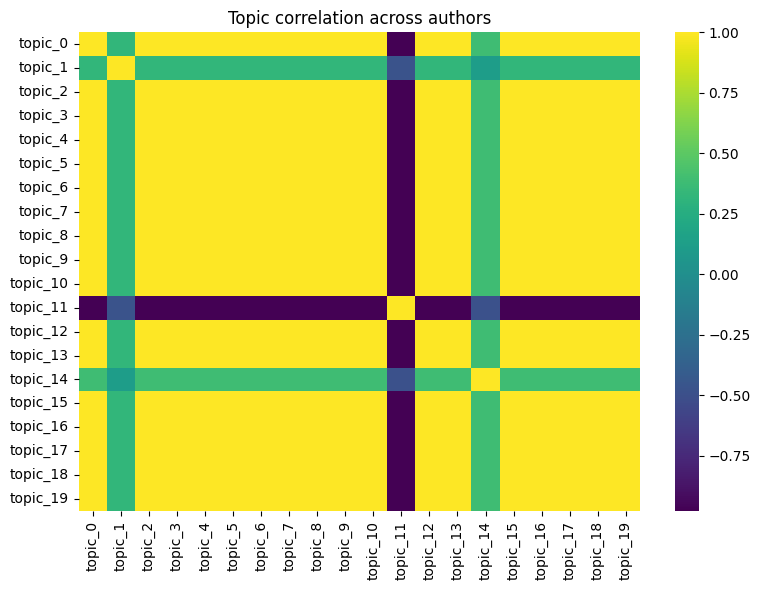


Number of authors: 8000
Fitting UMAP on topic vectors...


/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/envs/twitter-ai/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_3114597/2313836614.py:153: UserWarning: The palette list has more values (20) than needed (4), which may not be intended.
  sns.scatterplot(


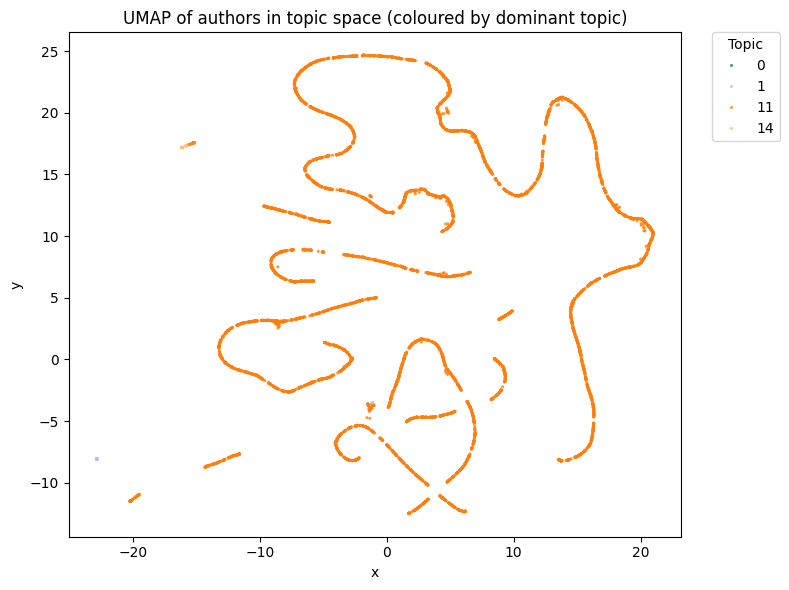

In [43]:
%%time


a_tag = str(ALPHA).replace(".", "p")
e_tag = str(ETA).replace(".", "p")

# Paths for this model
MODEL_DIR = BASE_DIR / REP
TOP_TERMS_PATH = MODEL_DIR / f"author_topics_{REP}_k{K}_a{a_tag}_e{e_tag}_top_terms.csv"
THETA_PATH     = MODEL_DIR / f"author_topic_matrix_{REP}_k{K}_a{a_tag}_e{e_tag}.csv"

print("Top terms file:", TOP_TERMS_PATH)
print("Theta matrix file:", THETA_PATH)

# ======================================================
# 2. LOAD DATA
# ======================================================

df_top = pd.read_csv(TOP_TERMS_PATH)
df_theta = pd.read_csv(THETA_PATH)

print("\nTop terms head:")
display(df_top.head())

print("\nTheta head:")
display(df_theta.head())

# Identify topic columns (everything except author_id)
topic_cols = [c for c in df_theta.columns if c != "author_id"]
num_topics = len(topic_cols)
print(f"\nDetected {num_topics} topic columns:", topic_cols)


# ======================================================
# 3. CLEAN HUMAN READABLE TOPIC DESCRIPTIONS
# ======================================================

def summarize_topics(df_top, df_theta, topic_cols, top_n=15, weight_round=2):
    """
    For each topic:
      - print top words with weights
      - show summary stats:
          mean topic weight across authors
          median topic weight
          share of authors with topic weight > threshold
    """
    # make sure topics are sorted
    topics = sorted(df_top["topic"].unique().tolist())

    # basic per topic statistics from theta
    theta_matrix = df_theta[topic_cols].values
    topic_means = theta_matrix.mean(axis=0)
    topic_medians = np.median(theta_matrix, axis=0)
    threshold = 0.1
    topic_active_frac = (theta_matrix > threshold).mean(axis=0)

    print("\n================ TOPIC SUMMARIES ================\n")

    for t in topics:
        # extract top terms for this topic
        sub = df_top[df_top["topic"] == t].sort_values("weight", ascending=False).head(top_n)
        terms = sub["term"].tolist()
        weights = sub["weight"].tolist()

        # basic stats
        idx = t  # assumes topics are numbered 0..K-1
        mean_w = topic_means[idx]
        med_w = topic_medians[idx]
        active_frac = topic_active_frac[idx]

        print(f"Topic {t}:")
        print(f"  Mean topic weight across authors: {mean_w:.3f}")
        print(f"  Median topic weight: {med_w:.3f}")
        print(f"  Share of authors with weight > {threshold}: {active_frac:.3f}")

        # build a compact description string
        word_bits = [f"{term} ({round(w, weight_round)})" for term, w in zip(terms, weights)]
        desc = ", ".join(word_bits)
        print(f"  Top terms: {desc}\n")


summarize_topics(df_top, df_theta, topic_cols, top_n=15, weight_round=2)


# ======================================================
# 4. TOPIC CORRELATION HEATMAP
# ======================================================

def plot_topic_correlation_heatmap(df_theta, topic_cols, figsize=(8, 6)):
    """
    Computes Pearson correlation between topic usage across authors
    and plots a heatmap.
    """
    topic_matrix = df_theta[topic_cols]
    corr = topic_matrix.corr()

    plt.figure(figsize=figsize)
    sns.heatmap(corr, annot=False, cmap="viridis", xticklabels=True, yticklabels=True)
    plt.title("Topic correlation across authors")
    plt.tight_layout()
    plt.show()


plot_topic_correlation_heatmap(df_theta, topic_cols)


# ======================================================
# 5. UMAP EMBEDDING OF AUTHORS IN TOPIC SPACE
# ======================================================

def plot_umap_authors(df_theta, topic_cols, n_neighbors=30, min_dist=0.1,
                      metric="euclidean", max_points=10000, random_state=42):
    """
    Reduces author topic vectors to 2D with UMAP and colours by dominant topic.
    For very large numbers of authors, optionally subsamples for plotting.
    """
    X = df_theta[topic_cols].values
    n_authors = X.shape[0]
    print(f"\nNumber of authors: {n_authors}")

    # Subsample if huge
    if n_authors > max_points:
        idx = np.random.RandomState(random_state).choice(n_authors, size=max_points, replace=False)
        X_sub = X[idx]
        author_ids_sub = df_theta["author_id"].iloc[idx].values
    else:
        X_sub = X
        author_ids_sub = df_theta["author_id"].values
        idx = np.arange(n_authors)

    # Compute dominant topic per author
    dominant_topic = X_sub.argmax(axis=1)

    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        metric=metric,
        random_state=random_state
    )

    print("Fitting UMAP on topic vectors...")
    embedding = reducer.fit_transform(X_sub)

    # Build a DataFrame for plotting
    df_emb = pd.DataFrame({
        "author_id": author_ids_sub,
        "x": embedding[:, 0],
        "y": embedding[:, 1],
        "dominant_topic": dominant_topic
    })

    plt.figure(figsize=(8, 6))
    # Use a discrete palette for topics
    palette = sns.color_palette("tab20", num_topics)
    sns.scatterplot(
        data=df_emb,
        x="x",
        y="y",
        hue="dominant_topic",
        palette=palette,
        s=5,
        linewidth=0,
        alpha=0.8
    )
    plt.title("UMAP of authors in topic space (coloured by dominant topic)")
    plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)
    plt.tight_layout()
    plt.show()

    return df_emb


df_umap = plot_umap_authors(df_theta, topic_cols)


Topic 0: Bard launches

Topic 1: Musk commentary

Topic 2: Comedy media

Topic 3: Apps and tools

Topic 4: General reactions

Topic 5: Image generation

Topic 6: Big tech rivalry

Topic 7: Writing and style

Topic 8: Search engines

Topic 9: Humour and talk

Topic 10: Web development

Topic 11: Tech and jobs

Topic 12: LLM promotion

Topic 13: Copilot and blogs

Topic 14: Politics and woke

Topic 15: Content moderation


A. Topics 6 and 8 overlap more than any others

Both focus on tech rivalry, Google, Microsoft, Bing, OpenAI.
Topic 6 is general big tech competition.
Topic 8 is specifically search engines.

They share partial vocabularies (bard, google, bing) and are often used by the same authors.

These two form the strongest cluster.

B. Topics 5 and 12 form a soft pair

Topic 5 is generative images.
Topic 12 is LLM services and innovation.

Both are used by creative, early adopter, trend following users.
These authors often talk about both generative media and LLM announcements, so mild correlation is expected.

C. Topics 2, 9, and 15 form a discourse cluster

These are comedy, humour, Seinfeld, Twitch commentary.
They capture light hearted or culture commentary content.
Some content creators mix these topics.

D. Topics 3, 4, 7, 11, 13 form a weaker cloud

These are general usage, tools, reactions, web commentary, and jobs.
They do not overlap strongly but sit in the same broad region.
They represent generalist authors.

E. Topics 1 and 14 have mild overlap

These concern political talk, Musk, slurs, woke discourse.
They appear near each other, but remain distinct.

F. Some topics are nearly isolated

Topic 0 (Bard launches) sits near the top but is narrow and niche.
Topic 10 (web development) sits alone.
Topic 15 (content moderation and Twitch) is distinct.

Saving labelled plots to: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots_labeled


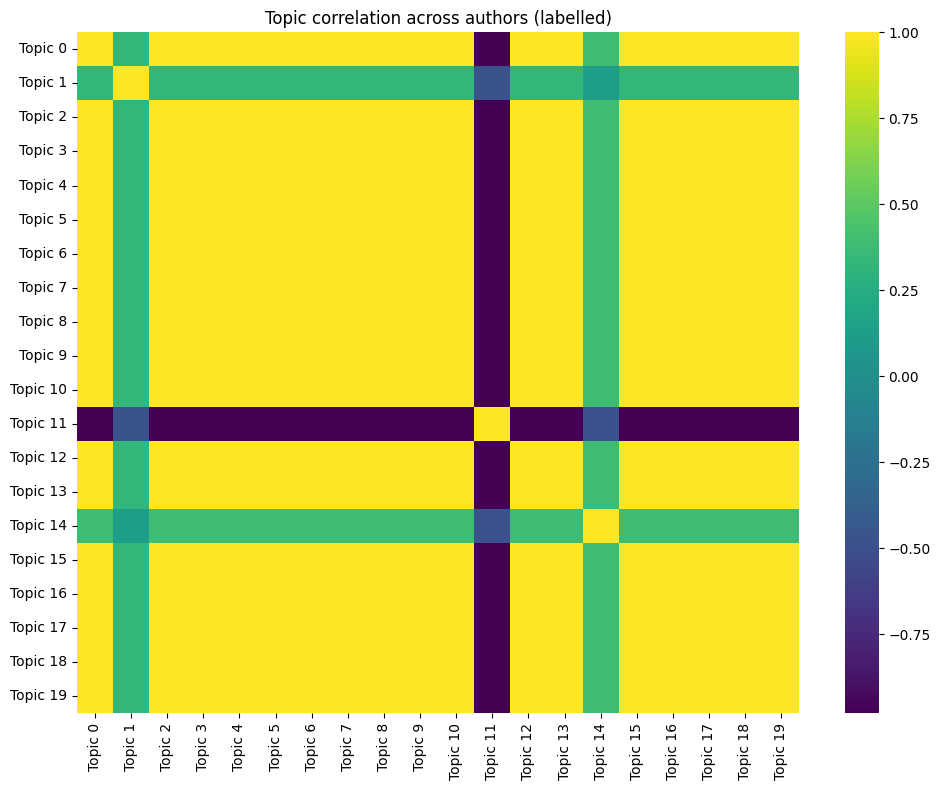

Saved: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots_labeled/topic_correlation_heatmap_labeled.png


/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/envs/twitter-ai/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_3114597/377406935.py:93: UserWarning: The palette list has more values (20) than needed (4), which may not be intended.
  sns.scatterplot(


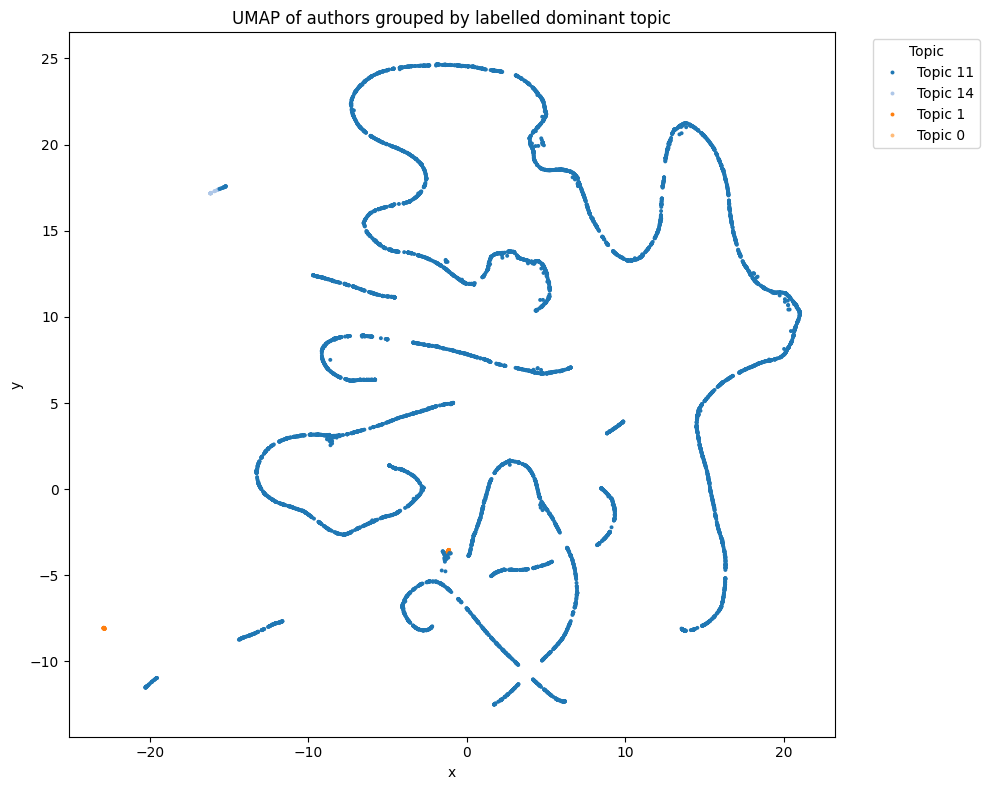

Saved: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots_labeled/umap_labeled_topics.png


In [44]:
%%time
# ======================================================
# CONFIG
# ======================================================

BASE_DIR = OUT_DIR
#Path("/content/drive/MyDrive/AI Public Trust/Models/Topic Modeling/LDA/author_level")
REP = "tfidf_bigram"
K = 20
ALPHA = 0.5
ETA = 0.5

a_tag = str(ALPHA).replace(".", "p")
e_tag = str(ETA).replace(".", "p")

TOP_TERMS_PATH = BASE_DIR / REP / f"author_topics_{REP}_k{K}_a{a_tag}_e{e_tag}_top_terms.csv"
THETA_PATH     = BASE_DIR / REP / f"author_topic_matrix_{REP}_k{K}_a{a_tag}_e{e_tag}.csv"

# labels for topics
topic_labels = [f"Topic {i}" for i in range(K)]
'''topic_labels = [
    "Bard launches",
    "Musk commentary",
    "Comedy media",
    "Apps and tools",
    "General reactions",
    "Image generation",
    "Big tech rivalry",
    "Writing and style",
    "Search engines",
    "Humour and talk",
    "Web development",
    "Tech and jobs",
    "LLM promotion",
    "Copilot and blogs",
    "Politics and woke",
    "Content moderation"
]
'''

# Directory for labelled plots
PLOT_DIR = BASE_DIR / "plots_labeled"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("Saving labelled plots to:", PLOT_DIR)

# ======================================================
# LOAD DATA
# ======================================================

df_top = pd.read_csv(TOP_TERMS_PATH)
df_theta = pd.read_csv(THETA_PATH)
topic_cols = [c for c in df_theta.columns if c.startswith("topic_")]

# ======================================================
# CORRELATION HEATMAP WITH LABELS
# ======================================================

corr = df_theta[topic_cols].corr()
corr.index = topic_labels
corr.columns = topic_labels

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="viridis")
plt.title("Topic correlation across authors (labelled)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

heatmap_path = PLOT_DIR / "topic_correlation_heatmap_labeled.png"
plt.savefig(heatmap_path, dpi=150)
plt.show()
print("Saved:", heatmap_path)

# ======================================================
# UMAP WITH LABELLED TOPICS
# ======================================================

X = df_theta[topic_cols].values
dominant_topic = X.argmax(axis=1)

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X)

df_umap = pd.DataFrame({
    "x": embedding[:,0],
    "y": embedding[:,1],
    "topic": dominant_topic
})

plt.figure(figsize=(10, 8))
palette = sns.color_palette("tab20", K)

sns.scatterplot(
    data=df_umap,
    x="x",
    y="y",
    hue=df_umap["topic"].map(lambda t: topic_labels[t]),
    palette=palette,
    s=8,
    linewidth=0
)

plt.title("UMAP of authors grouped by labelled dominant topic")
plt.legend(title="Topic", bbox_to_anchor=(1.04, 1), loc="upper left")
plt.tight_layout()

umap_path = PLOT_DIR / "umap_labeled_topics.png"
plt.savefig(umap_path, dpi=150)
plt.show()
print("Saved:", umap_path)


# 8 Author Level and Sentiments

In [45]:
%%time
# ======================================================
# Refit canonical LDA model: tfidf_unigram, K=16, alpha=0.1, eta=0.1
# ======================================================

REP = "tfidf_unigram"
K = 16
ALPHA = 0.1
ETA = 0.1

# 1. Rebuild the TFIDF vectorizer with the same parameters as original
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=stopwords_extended,
    max_df=0.95,
    min_df=5,
    ngram_range=(1,1),
    use_idf=True
)

# 2. Rebuild the corpus exactly as before
corpus = [author_docs[aid] for aid in author_ids]

# 3. Fit the vectorizer
X = vectorizer.fit_transform(corpus)

print("Vectorizer rebuilt. Shape:", X.shape)

# 4. Fit the LDA model
lda = LatentDirichletAllocation(
    n_components=K,
    doc_topic_prior=ALPHA,
    topic_word_prior=ETA,
    learning_method="batch",
    max_iter=20,
    random_state=42
)

lda.fit(X)
print("Canonical LDA model refitted.")


Vectorizer rebuilt. Shape: (8000, 10934)
Canonical LDA model refitted.


In [46]:
%%time
# ======================================================
# Save the model and vectorizer for future loading
# ======================================================

MODEL_DIR = BASE_DIR / REP
MODEL_DIR.mkdir(parents=True, exist_ok=True)

with open(MODEL_DIR / f"lda_model_k{K}_a0p1_e0p1.pkl", "wb") as f:
    pickle.dump(lda, f)

with open(MODEL_DIR / f"vectorizer_k{K}_a0p1_e0p1.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Saved canonical model and vectorizer.")


Saved canonical model and vectorizer.


In [47]:
%%time
# The following paths already exist earlier in 3.4; no need to redefine BASE
CLEAN = BASE_PATH / "Data Sets" / "Cleaned Data"


In [48]:
%%time
# ======================================================
# Load canonical LDA model and vectorizer
# ======================================================
REP = "tfidf_unigram"
K = 16
ALPHA = 0.1
ETA = 0.1

# MODEL_DIR = Path("/content/drive/MyDrive/AI Public Trust/Models/Topic Modeling/LDA/author_level") / "tfidf_unigram"

a_tag = str(ALPHA).replace(".", "p")
e_tag = str(ETA).replace(".", "p")

MODEL_DIR = BASE_DIR / "tfidf_unigram"
lda_path = MODEL_DIR / "lda_model_k16_a0p1_e0p1.pkl"
vec_path = MODEL_DIR / "vectorizer_k16_a0p1_e0p1.pkl"


print("Loading LDA model:", lda_path)
print("Loading vectorizer:", vec_path)

with open(lda_path, "rb") as f:
    lda = pickle.load(f)

with open(vec_path, "rb") as f:
    vectorizer = pickle.load(f)


Loading LDA model: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/tfidf_unigram/lda_model_k16_a0p1_e0p1.pkl
Loading vectorizer: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/tfidf_unigram/vectorizer_k16_a0p1_e0p1.pkl


In [49]:
%%time
# v2: Use the pruned dict (same input as topic modelling)
infile = CLEAN / "AItrust_twits_pruned_dict.json"
outfile = CLEAN / "AI_pruned_tweets_with_topic_weights_v2.json"

count_in = 0
count_out = 0

with open(infile, "r", encoding="utf8") as fin, \
     open(outfile, "w", encoding="utf8") as fout:

    for line in fin:
        count_in += 1
        t = json.loads(line)

        # optional filter: only keep tweets from LCC authors
        aid = str(t.get("author_id", ""))
        if lcc_nodes is not None and aid not in lcc_nodes:
            continue

        # v2: clean the tweet text before vectorizing
        cleaned = clean_tweet_text(t.get("text", ""))
        X = vectorizer.transform([cleaned])
        t["topic_weights"] = lda.transform(X)[0].tolist()

        # write out the updated tweet
        fout.write(json.dumps(t) + "\n")
        count_out += 1

        del X

print("Lines read:", count_in)
print("Tweets written:", count_out)
print("Saved to:", outfile)


Lines read: 17410035
Tweets written: 65615
Saved to: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Data Sets/Cleaned Data/AI_pruned_tweets_with_topic_weights_v2.json


In [50]:
%%time
#!head -n 3 "/content/drive/MyDrive/AI Public Trust/Data Sets/Cleaned Data/AItrust_pruned_twits_with_sentiment.json"



In [51]:
%%time
author_sent_sum = defaultdict(lambda: defaultdict(float))
author_counts = defaultdict(int)
sentiment_dims = None

with open(outfile, "r", encoding="utf8") as fin:
    for line in fin:
        t = json.loads(line)

        # Skip tweets with no sentiment score
        if "sentiment_score" not in t:
            continue

        # Set sentiment dimension names once
        if sentiment_dims is None:
            sentiment_dims = list(t["sentiment_score"].keys())
            print("Detected sentiment dimensions:", sentiment_dims)

        aid = t["author_id"]

        # Add sentiment values
        for dim in sentiment_dims:
            author_sent_sum[aid][dim] += t["sentiment_score"][dim]

        author_counts[aid] += 1

# Convert sums to means
author_sentiment_mean = {
    aid: {
        dim: author_sent_sum[aid][dim] / author_counts[aid]
        for dim in sentiment_dims
    }
    for aid in author_sent_sum
}

with open(CLEAN / "author_sentiment_mean.pkl", "wb") as f:
    pickle.dump(author_sentiment_mean, f)

print("Saved author sentiment means.")



Saved author sentiment means.


##. Summary
- Outputs are saved under `Models/Topic Modeling/LDA/author_level/`.
- Merge `author_topic_matrix_k{K}.csv` with LCC community labels for community profiles.
- Use `author_lda_model_report.csv` plus the top terms and pyLDAvis to pick a canonical K.

# 9 - Visualisations 

Best model: tfidf_unigram K=20 alpha=0.5 eta=0.5


/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/envs/twitter-ai/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots/umap_authors_tfidf_unigram_k20.png


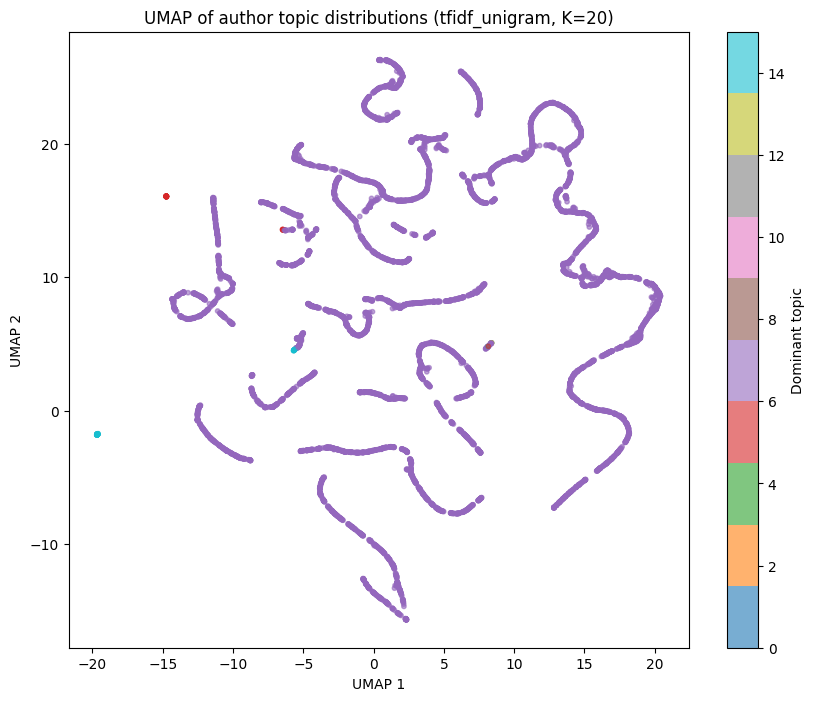

In [52]:
%%time
import umap

# Pick the best model from the grid search
best_row = df_master.loc[df_master['coherence_c_v'].idxmax()]
best_rep = best_row['representation']
best_k = int(best_row['K'])
best_alpha = best_row['alpha']
best_eta = best_row['eta']
print(f"Best model: {best_rep} K={best_k} alpha={best_alpha} eta={best_eta}")

# Load the corresponding theta matrix
a_tag = str(best_alpha).replace('.', 'p')
e_tag = str(best_eta).replace('.', 'p')
theta_path = OUT_DIR / best_rep / f"author_topic_matrix_{best_rep}_k{best_k}_a{a_tag}_e{e_tag}.csv"
df_theta = pd.read_csv(theta_path)

# Extract topic columns only (drop author_id)
topic_cols = [c for c in df_theta.columns if c.startswith('topic_')]
X_topics = df_theta[topic_cols].values

# UMAP reduction
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_topics)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
dominant_topic = X_topics.argmax(axis=1)
scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=dominant_topic, 
                     cmap='tab10', alpha=0.6, s=10)
ax.set_title(f"UMAP of author topic distributions ({best_rep}, K={best_k})")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.colorbar(scatter, label="Dominant topic")

umap_path = OUT_DIR / "plots" / f"umap_authors_{best_rep}_k{best_k}.png"
fig.savefig(umap_path, dpi=150, bbox_inches="tight")
print(f"Saved: {umap_path}")
plt.show()

Best model: tfidf_unigram K=12 alpha=0.5 eta=0.5 coherence=0.651
Authors: 8000, Topics: 12


/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/envs/twitter-ai/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


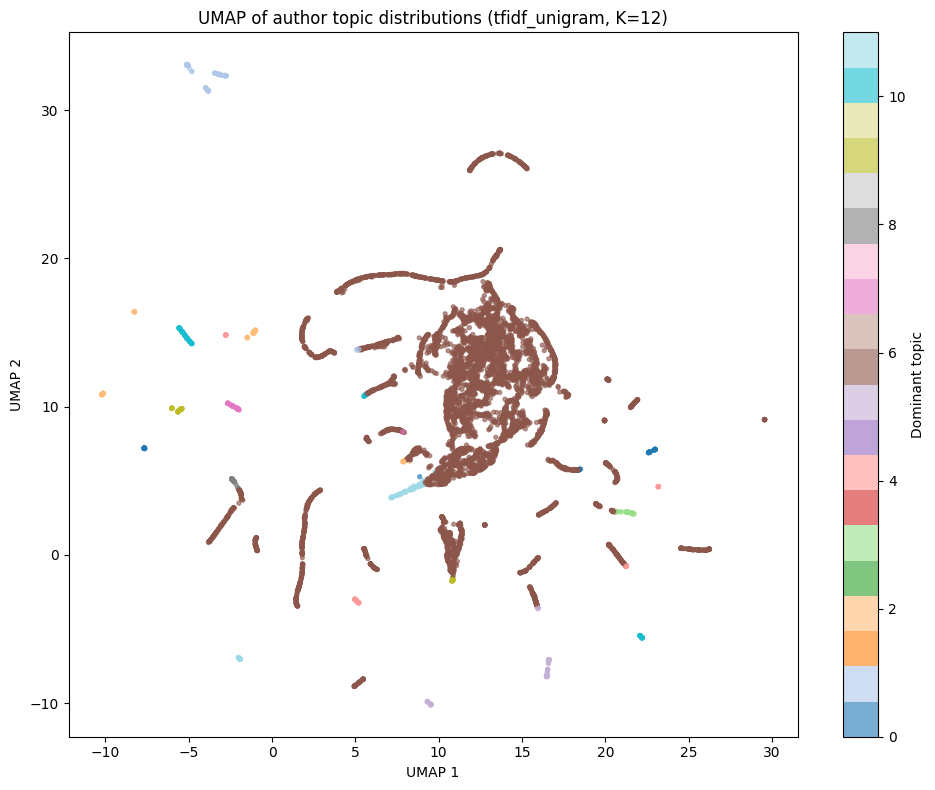

Saved: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots/umap_authors_tfidf_unigram_k12.png


In [53]:
%%time
# ======================================================
# UMAP — using best model from grid search
# ======================================================


# Load grid results and find best model
grid_path = OUT_DIR / "ALL_REPRESENTATIONS_LDA_FULL_GRID.csv"
df_grid = pd.read_csv(grid_path)
best = df_grid.loc[df_grid['coherence_c_v'].idxmax()]



best_rep = "tfidf_unigram"
best_k = 12
best_a = "0p1"
best_e = "0p1"

print(f"Best model: {best_rep} K={best_k} alpha={best['alpha']} eta={best['eta']} coherence={best['coherence_c_v']:.3f}")

# Load theta matrix
theta_path = OUT_DIR / best_rep / f"author_topic_matrix_{best_rep}_k{best_k}_a{best_a}_e{best_e}.csv"
df_theta = pd.read_csv(theta_path)
topic_cols = [c for c in df_theta.columns if c.startswith('topic_')]
X_topics = df_theta[topic_cols].values

print(f"Authors: {X_topics.shape[0]}, Topics: {X_topics.shape[1]}")

# UMAP
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
embedding = reducer.fit_transform(X_topics)
dominant_topic = X_topics.argmax(axis=1)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=dominant_topic,
                     cmap='tab20', alpha=0.6, s=8)
ax.set_title(f"UMAP of author topic distributions ({best_rep}, K={best_k})")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.colorbar(scatter, label="Dominant topic")
plt.tight_layout()

PLOT_DIR = OUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(PLOT_DIR / f"umap_authors_{best_rep}_k{best_k}.png", dpi=150)
plt.show()
print(f"Saved: {PLOT_DIR / f'umap_authors_{best_rep}_k{best_k}.png'}")

Best model: tfidf_unigram K=12 alpha=0.5 eta=0.5 coherence=0.651
Authors: 8000, Topics: 12


/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/envs/twitter-ai/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


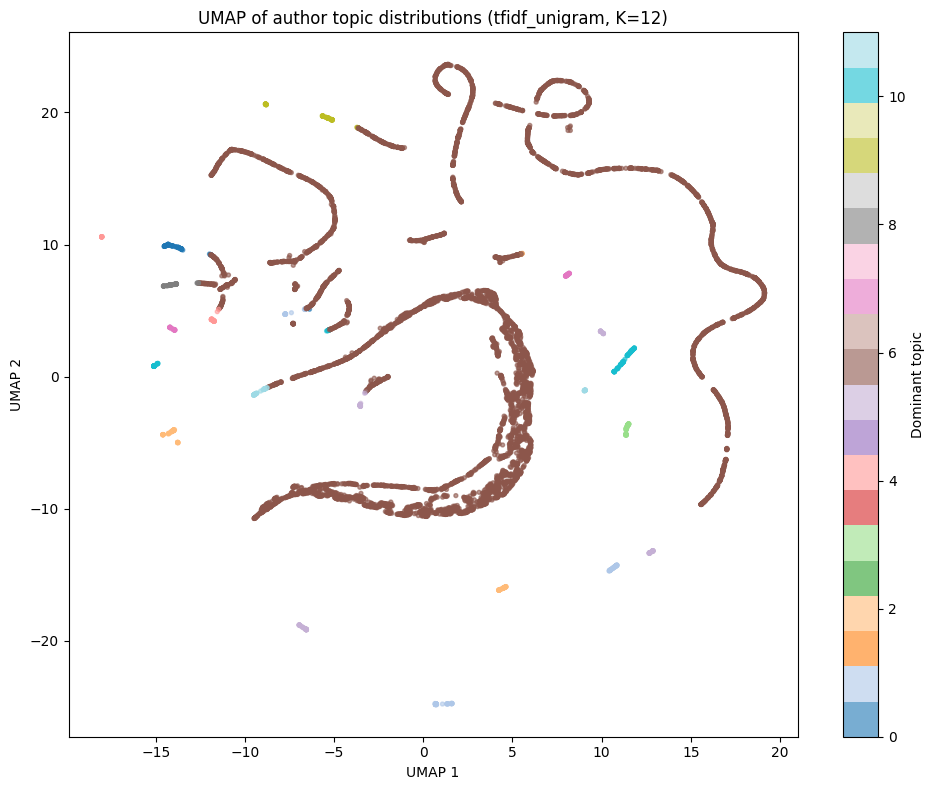

Saved: /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots/umap_authors_tfidf_unigram_k12.png


In [54]:
%%time
# ======================================================
# UMAP — using best model from grid search
# ======================================================


# Load grid results and find best model
grid_path = OUT_DIR / "ALL_REPRESENTATIONS_LDA_FULL_GRID.csv"
df_grid = pd.read_csv(grid_path)
best = df_grid.loc[df_grid['coherence_c_v'].idxmax()]



best_rep = "tfidf_unigram"
best_k = 12
best_a = "0p01"
best_e = "0p1"

print(f"Best model: {best_rep} K={best_k} alpha={best['alpha']} eta={best['eta']} coherence={best['coherence_c_v']:.3f}")

# Load theta matrix
theta_path = OUT_DIR / best_rep / f"author_topic_matrix_{best_rep}_k{best_k}_a{best_a}_e{best_e}.csv"
df_theta = pd.read_csv(theta_path)
topic_cols = [c for c in df_theta.columns if c.startswith('topic_')]
X_topics = df_theta[topic_cols].values

print(f"Authors: {X_topics.shape[0]}, Topics: {X_topics.shape[1]}")

# UMAP
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
embedding = reducer.fit_transform(X_topics)
dominant_topic = X_topics.argmax(axis=1)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=dominant_topic,
                     cmap='tab20', alpha=0.6, s=8)
ax.set_title(f"UMAP of author topic distributions ({best_rep}, K={best_k})")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.colorbar(scatter, label="Dominant topic")
plt.tight_layout()

PLOT_DIR = OUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(PLOT_DIR / f"umap_authors_{best_rep}_k{best_k}.png", dpi=150)
plt.show()
print(f"Saved: {PLOT_DIR / f'umap_authors_{best_rep}_k{best_k}.png'}")

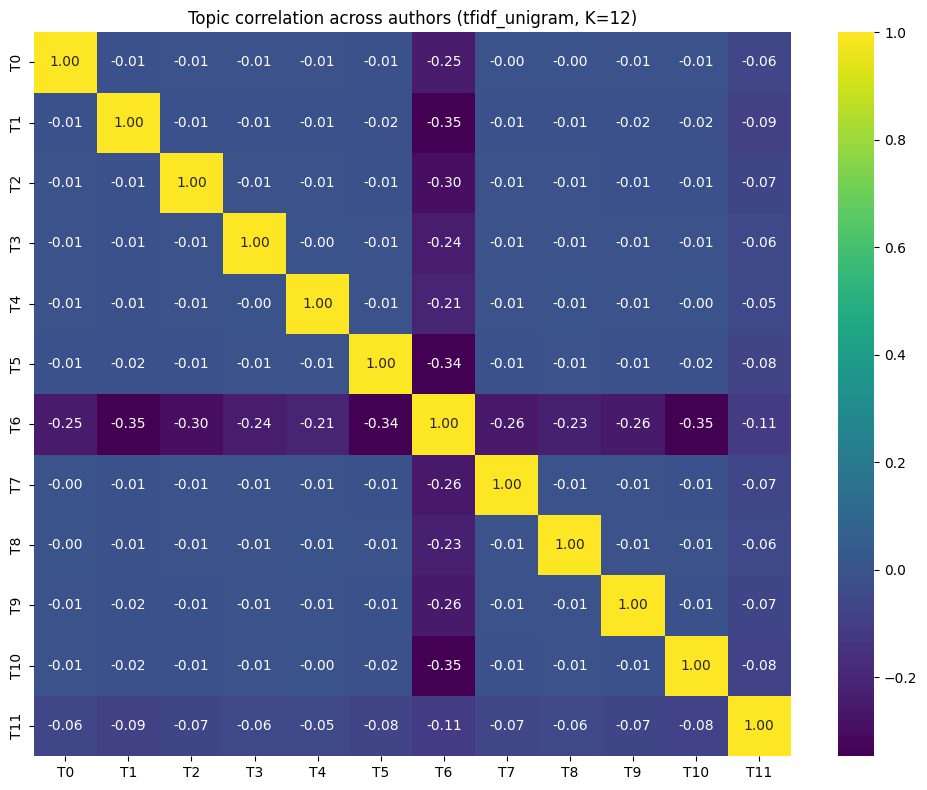

In [55]:
%%time
# ======================================================
# Topic correlation heatmap
# ======================================================

best_rep = "tfidf_unigram"
best_k = 12
best_a = "0p01"
best_e = "0p1"

corr = df_theta[topic_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", 
            xticklabels=[f"T{i}" for i in range(len(topic_cols))],
            yticklabels=[f"T{i}" for i in range(len(topic_cols))])
plt.title(f"Topic correlation across authors ({best_rep}, K={best_k})")
plt.tight_layout()
plt.savefig(PLOT_DIR / f"topic_correlation_{best_rep}_k{best_k}.png", dpi=150)
plt.show()

In [56]:
%%time
# ======================================================
# Top terms for each topic in the best model
# ======================================================
best_rep = "tfidf_unigram"
best_k = 12
best_a = "0p01"
best_e = "0p1"

terms_path = OUT_DIR / best_rep / f"author_topics_{best_rep}_k{best_k}_a{best_a}_e{best_e}_top_terms.csv"
df_terms = pd.read_csv(terms_path)

print(f"=== {best_rep} | K={best_k} | alpha=0.01 | eta=0.1 ===\n")
for t in sorted(df_terms['topic'].unique()):
    top = df_terms[df_terms['topic'] == t].nlargest(10, 'weight')
    terms = ', '.join(top['term'].tolist())
    print(f"  Topic {t}: {terms}")

=== tfidf_unigram | K=12 | alpha=0.01 | eta=0.1 ===

  Topic 0: shudu, hired, ai, industry, means, know, cave, nick, model, 200
  Topic 1: notion, waitlist, alpha, magic, join, ai, chatgpt, email, future, months
  Topic 2: addy, ai, introducing, nvidia, eye, contact, chatgpt, emails, entirety, blockchain
  Topic 3: ai, 90, scared, song, omg, tec, frontend, vaccine, paying, generated
  Topic 4: facebook, figures, guide, ai, chatgpt, ads, bring, potential, wife, use
  Topic 5: pixar, saturday, president, character, project, fun, ai, using, gaslights, argues
  Topic 6: ai, chatgpt, like, just, gpt, new, art, use, people, using
  Topic 7: ai, text, outcompete, bert, wes, anderson, saves, tho, chatgpt, render
  Topic 8: reasonably, opting, ai, explanations, produced, phd, chatgpt, sounding, glorify, destroyed
  Topic 9: chatgpt, 1985, bullshitting, mastered, assistant, playboy, bank, ai, people, reminded
  Topic 10: chatgpt, ai, irreparable, adobe, credibility, damage, building, engineers, 

### HSBSCAN 

In [41]:
%%time
PLOT_DIR = OUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

 
# # 10. LDA Anti-Collapse: Diversity Scoring & Focused Grid
 
# ## 10.1 Topic Diversity & Collapse Detection

In [31]:
%%time

#
# The K=20 α=0.5 η=0.5 model scored highest on coherence (0.694)
# but 18/20 topics collapsed into near-identical content.
# High coherence ≠ interpretability (Chang et al., 2009).
#
# We add two metrics to catch this:
# - **Topic diversity**: proportion of unique words across all topics' top-N terms (Dieng et al., 2020)
# - **Collapse ratio**: fraction of topic pairs sharing >70% of top terms
 
# %%
import numpy as np
import pandas as pd
import time
from pathlib import Path
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
 
def compute_topic_diversity_lda(vectorizer, lda_model, top_n=15):
    """
    Topic diversity = unique words / total words across all topics' top-N.
    Range [0, 1]. Higher = less overlap = better.
    Ref: Dieng et al. (2020), TACL.
    """
    feature_names = vectorizer.get_feature_names_out()
    all_words = []
    for topic in lda_model.components_:
        top_indices = topic.argsort()[:-top_n - 1:-1]
        all_words.extend([feature_names[i] for i in top_indices])
    if not all_words:
        return 0.0
    return len(set(all_words)) / len(all_words)
 
 
def detect_topic_collapse(vectorizer, lda_model, top_n=10, overlap_threshold=0.7):
    """
    Fraction of topic pairs sharing > overlap_threshold of their top terms.
    Returns (collapse_ratio, n_collapsed_pairs, n_total_pairs).
    """
    feature_names = vectorizer.get_feature_names_out()
    topic_sets = []
    for topic in lda_model.components_:
        top_idx = topic.argsort()[:-top_n - 1:-1]
        topic_sets.append(set(feature_names[i] for i in top_idx))
    n = len(topic_sets)
    collapsed = 0
    total = 0
    for i in range(n):
        for j in range(i + 1, n):
            overlap = len(topic_sets[i] & topic_sets[j]) / top_n
            if overlap >= overlap_threshold:
                collapsed += 1
            total += 1
    return (collapsed / total if total > 0 else 0.0, collapsed, total)
 
print("Defined: compute_topic_diversity_lda(), detect_topic_collapse()")
 
 



Defined: compute_topic_diversity_lda(), detect_topic_collapse()



# ## 10.2 Score Existing Grid Results

In [43]:
%%time

 
# %%
# Load grid from previous run
grid_csv = OUT_DIR / "ALL_REPRESENTATIONS_LDA_FULL_GRID.csv"
assert grid_csv.exists(), f"Not found: {grid_csv}"
df_grid = pd.read_csv(grid_csv)
print(f"Loaded {len(df_grid)} models from {grid_csv.name}")
 
# Show top 10 by coherence
top10 = df_grid.nlargest(10, 'coherence_c_v')
print("\nTop 10 by coherence:")
print(top10[['representation', 'K', 'alpha', 'eta', 'coherence_c_v']].to_string(index=False))
 


Loaded 108 models from ALL_REPRESENTATIONS_LDA_FULL_GRID.csv

Top 10 by coherence:
representation  K  alpha  eta  coherence_c_v
 tfidf_unigram 20   0.50  0.5       0.651148
  tfidf_bigram 20   0.50  0.5       0.539354
 tfidf_unigram 12   0.50  0.5       0.537287
  tfidf_bigram 12   0.01  0.5       0.522768
    bow_bigram 20   0.01  0.5       0.518181
    bow_bigram 20   0.10  0.5       0.515843
  tfidf_bigram 12   0.50  0.5       0.509766
 tfidf_unigram 20   0.10  0.5       0.487892
 tfidf_unigram 20   0.10  0.1       0.485545
  tfidf_bigram 12   0.01  0.1       0.463222



# ## 10.3 Re-fit Top Models for Diversity Scoring

In [44]:
%%time

#
# Re-fit the top candidates + known-good low-α models to compute
# diversity and collapse metrics. This is ~10-15 models, fast.
 
# %%
# Candidates: top 5 by coherence + any tfidf_unigram K=12 with low alpha
candidates = top10.head(5).to_dict('records')
for row in df_grid.to_dict('records'):
    if (row['representation'] == 'tfidf_unigram'
        and row['K'] == 12
        and row['alpha'] <= 0.1
        and row['eta'] <= 0.1):
        candidates.append(row)
 
# Deduplicate
seen = set()
unique_cands = []
for c in candidates:
    key = (c['representation'], int(c['K']), c['alpha'], c['eta'])
    if key not in seen:
        seen.add(key)
        unique_cands.append(c)
candidates = unique_cands
print(f"Re-fitting {len(candidates)} candidates for diversity scoring...\n")
 
# Reuse vectorizers from `results` dict (already fitted in cell 38)
diversity_rows = []
for c in candidates:
    rep = c['representation']
    K = int(c['K'])
    alpha = c['alpha']
    eta = c['eta']
 
    if rep not in results:
        print(f"  Skipping {rep} — not in results dict")
        continue
 
    vec = results[rep]['vectorizer']
    X = results[rep]['X']
 
    lda = LatentDirichletAllocation(
        n_components=K,
        doc_topic_prior=alpha,
        topic_word_prior=eta,
        max_iter=50,
        random_state=42,
        learning_method='batch',
        verbose=0,
    )
    lda.fit(X)
 
    div = compute_topic_diversity_lda(vec, lda)
    cr, nc, np_ = detect_topic_collapse(vec, lda)
 
    print(f"  {rep} K={K} α={alpha} η={eta} "
          f"| coh={c['coherence_c_v']:.3f} div={div:.3f} collapse={cr:.2f} ({nc}/{np_})")
 
    diversity_rows.append({
        'representation': rep, 'K': K,
        'alpha': alpha, 'eta': eta,
        'coherence': c['coherence_c_v'],
        'diversity': round(div, 4),
        'collapse_ratio': round(cr, 4),
        'collapsed_pairs': nc,
    })
 
df_div = pd.DataFrame(diversity_rows).sort_values('diversity', ascending=False)
print("\n--- Candidates ranked by diversity ---")
print(df_div.to_string(index=False))
df_div.to_csv(OUT_DIR / "candidate_diversity_scores.csv", index=False)
 

Re-fitting 9 candidates for diversity scoring...

  tfidf_unigram K=20 α=0.5 η=0.5 | coh=0.651 div=0.190 collapse=0.72 (136/190)
  tfidf_bigram K=20 α=0.5 η=0.5 | coh=0.539 div=0.197 collapse=0.72 (136/190)
  tfidf_unigram K=12 α=0.5 η=0.5 | coh=0.537 div=0.711 collapse=0.05 (3/66)
  tfidf_bigram K=12 α=0.01 η=0.5 | coh=0.523 div=0.967 collapse=0.00 (0/66)
  bow_bigram K=20 α=0.01 η=0.5 | coh=0.518 div=0.920 collapse=0.00 (0/190)
  tfidf_unigram K=12 α=0.01 η=0.01 | coh=0.311 div=0.811 collapse=0.00 (0/66)
  tfidf_unigram K=12 α=0.01 η=0.1 | coh=0.353 div=0.856 collapse=0.00 (0/66)
  tfidf_unigram K=12 α=0.1 η=0.01 | coh=0.327 div=0.828 collapse=0.00 (0/66)
  tfidf_unigram K=12 α=0.1 η=0.1 | coh=0.385 div=0.906 collapse=0.00 (0/66)

--- Candidates ranked by diversity ---
representation  K  alpha  eta  coherence  diversity  collapse_ratio  collapsed_pairs
  tfidf_bigram 12   0.01 0.50   0.522768     0.9667          0.0000                0
    bow_bigram 20   0.01 0.50   0.518181     0.9

 

# ## 10.4 Focused Anti-Collapse Grid

In [32]:
%%time

#
# Changes from the original grid:
# - **max_df=0.7** (was 0.95): removes terms in >70% of author docs,
#   which are exactly what dominates collapsed topics
# - **Low α/η only**: the collapse zone was α≥0.5 + η≥0.5.
#   We now search [0.01, 0.05, 0.1, 0.3] × [0.01, 0.05, 0.1]
# - **tfidf only**: BOW consistently underperformed in prior runs
# - 2 reps × 3 K × 4 α × 3 η = **72 models** (~30-40 min on CPU)
 
# %%
K_FOCUSED     = [8, 12, 20]
ALPHA_FOCUSED = [0.01, 0.05, 0.1, 0.3]
ETA_FOCUSED   = [0.01, 0.05, 0.1]
REP_FOCUSED   = ['tfidf_unigram', 'tfidf_bigram']
MAX_DF_NEW    = 0.7
 
n_models = len(REP_FOCUSED) * len(K_FOCUSED) * len(ALPHA_FOCUSED) * len(ETA_FOCUSED)
print(f"Focused grid: {n_models} models")
print(f"  Representations: {REP_FOCUSED}")
print(f"  K: {K_FOCUSED}")
print(f"  Alpha: {ALPHA_FOCUSED}")
print(f"  Eta: {ETA_FOCUSED}")
print(f"  max_df: {MAX_DF_NEW} (was 0.95)")
 
# Build new vectorizers with tighter max_df
focused_vecs = {}
for rep in REP_FOCUSED:
    ngram = (1, 1) if 'unigram' in rep else (1, 2)
    vec = TfidfVectorizer(
        stop_words=stopwords_extended,
        max_df=MAX_DF_NEW,
        min_df=5,
        ngram_range=ngram,
        use_idf=True,
    )
    dtm = vec.fit_transform(corpus)
 
    # Bigram stopword filtering (same logic as cell 38)
    if 'bigram' in rep:
        vocab_list = vec.get_feature_names_out().tolist()
        sw_set = set(stopwords_extended) if isinstance(stopwords_extended, list) else stopwords_extended
        cleaned = [w for w in vocab_list
                   if len(w.split()) == 1
                   or all(p not in sw_set for p in w.split())]
        if len(cleaned) != len(vocab_list):
            print(f"  {rep}: filtered bigram vocab {len(vocab_list)} → {len(cleaned)}")
            vec = TfidfVectorizer(vocabulary=cleaned, use_idf=True)
            dtm = vec.fit_transform(corpus)
 
    focused_vecs[rep] = (vec, dtm)
    print(f"  {rep}: vocab={dtm.shape[1]}, docs={dtm.shape[0]}")
 
# Ensure tokenized corpus exists for coherence
try:
    _ = tokens_by_doc
except NameError:
    tokens_by_doc = [doc.split() for doc in corpus]
 
gensim_dict = GensimDictionary(tokens_by_doc)
 
# %%
# Run the focused grid
focused_results = []
n_done = 0
t0 = time.time()
 
for rep in REP_FOCUSED:
    vec, dtm = focused_vecs[rep]
    feature_names = vec.get_feature_names_out()
 
    for K in K_FOCUSED:
        for alpha in ALPHA_FOCUSED:
            for eta in ETA_FOCUSED:
                n_done += 1
                lda = LatentDirichletAllocation(
                    n_components=K,
                    doc_topic_prior=alpha,
                    topic_word_prior=eta,
                    max_iter=50,
                    random_state=42,
                    learning_method='batch',
                    verbose=0,
                )
                lda.fit(dtm)
 
                # Top terms
                topic_term_lists = []
                for topic in lda.components_:
                    top_idx = topic.argsort()[:-16:-1]
                    topic_term_lists.append([feature_names[i] for i in top_idx])
 
                # Coherence
                try:
                    cm = CoherenceModel(
                        topics=topic_term_lists,
                        texts=tokens_by_doc,
                        dictionary=gensim_dict,
                        coherence='c_v',
                    )
                    coh = cm.get_coherence()
                except:
                    coh = np.nan
 
                # Diversity & collapse
                div = compute_topic_diversity_lda(vec, lda)
                cr, nc, _ = detect_topic_collapse(vec, lda)
 
                # Perplexity
                try:
                    perp = float(np.exp(-lda.score(dtm) / dtm.sum()))
                except:
                    perp = np.nan
 
                focused_results.append({
                    'representation': rep, 'K': K,
                    'alpha': alpha, 'eta': eta,
                    'coherence_c_v': round(coh, 4) if not np.isnan(coh) else np.nan,
                    'diversity': round(div, 4),
                    'collapse_ratio': round(cr, 4),
                    'perplexity_like': round(perp, 2) if not np.isnan(perp) else np.nan,
                    'max_df': MAX_DF_NEW,
                })
 
                if n_done % 12 == 0 or n_done == n_models:
                    elapsed = (time.time() - t0) / 60
                    print(f"  [{n_done}/{n_models}] {rep} K={K} α={alpha} η={eta} "
                          f"| coh={coh:.3f} div={div:.3f} coll={cr:.2f} "
                          f"| {elapsed:.1f} min")
 
# Save & also save theta + top terms for focused best models
df_focused = pd.DataFrame(focused_results)
df_focused.to_csv(OUT_DIR / "focused_grid_results.csv", index=False)
print(f"\nSaved {len(df_focused)} models → {OUT_DIR / 'focused_grid_results.csv'}")
 



Focused grid: 72 models
  Representations: ['tfidf_unigram', 'tfidf_bigram']
  K: [8, 12, 20]
  Alpha: [0.01, 0.05, 0.1, 0.3]
  Eta: [0.01, 0.05, 0.1]
  max_df: 0.7 (was 0.95)
  tfidf_unigram: vocab=10933, docs=8000
  tfidf_bigram: vocab=26902, docs=8000
  [12/72] tfidf_unigram K=8 α=0.3 η=0.1 | coh=0.352 div=0.975 coll=0.00 | 10.6 min
  [24/72] tfidf_unigram K=12 α=0.3 η=0.1 | coh=0.371 div=0.961 coll=0.00 | 22.1 min
  [36/72] tfidf_unigram K=20 α=0.3 η=0.1 | coh=0.439 div=0.970 coll=0.00 | 34.6 min
  [48/72] tfidf_bigram K=8 α=0.3 η=0.1 | coh=0.401 div=0.967 coll=0.00 | 46.6 min
  [60/72] tfidf_bigram K=12 α=0.3 η=0.1 | coh=0.401 div=0.994 coll=0.00 | 59.0 min
  [72/72] tfidf_bigram K=20 α=0.3 η=0.1 | coh=0.408 div=1.000 coll=0.00 | 74.6 min

Saved 72 models → /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/focused_grid_results.csv



# ## 10.5 Rank by Combined Score

In [33]:
%%time
 

#
# Weights: 35% coherence + 40% diversity + 25% (1 - collapse).
# Diversity gets highest weight because that's the problem we're solving.
 
# %%
df_f = df_focused.copy()
for col in ['coherence_c_v', 'diversity']:
    mn, mx = df_f[col].min(), df_f[col].max()
    df_f[f'{col}_n'] = (df_f[col] - mn) / (mx - mn) if mx > mn else 0.5
df_f['collapse_n'] = 1.0 - df_f['collapse_ratio']
df_f['combined_score'] = (0.35 * df_f['coherence_c_v_n']
                          + 0.40 * df_f['diversity_n']
                          + 0.25 * df_f['collapse_n'])
df_f = df_f.sort_values('combined_score', ascending=False)
 
print("=" * 80)
print("FOCUSED GRID — Top 15 by combined score")
print("(0.35 × coherence + 0.40 × diversity + 0.25 × (1-collapse))")
print("=" * 80)
print(df_f[['representation', 'K', 'alpha', 'eta',
            'coherence_c_v', 'diversity', 'collapse_ratio', 'combined_score']
          ].head(15).to_string(index=False))
 
 

FOCUSED GRID — Top 15 by combined score
(0.35 × coherence + 0.40 × diversity + 0.25 × (1-collapse))
representation  K  alpha  eta  coherence_c_v  diversity  collapse_ratio  combined_score
  tfidf_bigram 20   0.10 0.10         0.5608     0.9933             0.0        0.990255
  tfidf_bigram  8   0.01 0.10         0.5125     0.9833             0.0        0.913075
  tfidf_bigram 12   0.01 0.10         0.4523     0.9833             0.0        0.835009
  tfidf_bigram 12   0.05 0.10         0.4285     0.9944             0.0        0.820291
  tfidf_bigram 20   0.01 0.01         0.4709     0.9467             0.0        0.805893
  tfidf_bigram 20   0.30 0.10         0.4080     1.0000             0.0        0.801853
  tfidf_bigram 12   0.10 0.05         0.4252     0.9833             0.0        0.799866
 tfidf_unigram 20   0.30 0.10         0.4390     0.9700             0.0        0.798416
 tfidf_unigram 20   0.10 0.10         0.4466     0.9567             0.0        0.788926
  tfidf_bigram 12   

In [34]:
%%time
import pandas as pd
import numpy as np
from sklearn.decomposition import LatentDirichletAllocation

df_focused = pd.read_csv(OUT_DIR / "focused_grid_results.csv")

# Compute largest topic % for every model in the grid
for i, row in df_focused.iterrows():
    rep = row['representation']
    K = int(row['K'])
    vec, dtm = focused_vecs[rep]
    
    lda = LatentDirichletAllocation(
        n_components=K, doc_topic_prior=row['alpha'],
        topic_word_prior=row['eta'], max_iter=50,
        random_state=42, learning_method='batch', verbose=0,
    )
    lda.fit(dtm)
    theta = lda.transform(dtm)
    dom = theta.argmax(axis=1)
    df_focused.loc[i, 'largest_topic_pct'] = np.max(np.bincount(dom)) / len(dom)

df_focused = df_focused.sort_values('largest_topic_pct')
print("Models with LOWEST catch-all dominance:")
print(df_focused[['representation', 'K', 'alpha', 'eta', 
                   'coherence_c_v', 'diversity', 'largest_topic_pct']
                 ].head(15).to_string(index=False))

Models with LOWEST catch-all dominance:
representation  K  alpha  eta  coherence_c_v  diversity  largest_topic_pct
 tfidf_unigram 12   0.30 0.01         0.3365     0.8667           0.237000
  tfidf_bigram  8   0.30 0.01         0.3498     0.7583           0.333500
  tfidf_bigram  8   0.10 0.01         0.3566     0.7250           0.406625
  tfidf_bigram 12   0.30 0.01         0.3649     0.8556           0.448000
 tfidf_unigram 12   0.30 0.05         0.3384     0.9111           0.457250
 tfidf_unigram  8   0.30 0.01         0.3390     0.7917           0.480125
  tfidf_bigram 12   0.05 0.01         0.4228     0.8556           0.568625
  tfidf_bigram 20   0.30 0.01         0.2938     0.9200           0.591500
 tfidf_unigram 20   0.30 0.01         0.3030     0.8767           0.601125
  tfidf_bigram  8   0.30 0.05         0.3780     0.8833           0.630125
  tfidf_bigram 20   0.01 0.01         0.4709     0.9467           0.638875
 tfidf_unigram 12   0.30 0.10         0.3710     0.9611     


# ## 10.6 Fit Best Model, Display Topics, Save Artifacts

In [35]:
%%time

 
# %%
best = df_f.iloc[0]
rep = best['representation']
K = int(best['K'])
print(f"Best model: {rep} K={K} α={best['alpha']} η={best['eta']}")
print(f"  Coherence:  {best['coherence_c_v']:.4f}")
print(f"  Diversity:  {best['diversity']:.4f}")
print(f"  Collapse:   {best['collapse_ratio']:.4f}")
print(f"  Combined:   {best['combined_score']:.4f}")
 
vec, dtm = focused_vecs[rep]
feature_names = vec.get_feature_names_out()
 
best_lda = LatentDirichletAllocation(
    n_components=K,
    doc_topic_prior=best['alpha'],
    topic_word_prior=best['eta'],
    max_iter=50, random_state=42,
    learning_method='batch', verbose=0,
)
best_lda.fit(dtm)
 
# Display topics
print("\n" + "=" * 70)
print(f"Topics — {rep} K={K} α={best['alpha']} η={best['eta']} (max_df={MAX_DF_NEW})")
print("=" * 70)
for t_idx, topic in enumerate(best_lda.components_):
    top_idx = topic.argsort()[:-16:-1]
    terms = [feature_names[i] for i in top_idx]
    print(f"\nTopic {t_idx}: {', '.join(terms)}")
 
# Save theta
theta = best_lda.transform(dtm)
df_theta_best = to_prob_df(theta, author_ids)
a_tag = str(best['alpha']).replace('.', 'p')
e_tag = str(best['eta']).replace('.', 'p')
 
# Save into the rep subfolder (same structure as original grid)
rep_dir = OUT_DIR / rep
rep_dir.mkdir(parents=True, exist_ok=True)
theta_out = rep_dir / f"author_topic_matrix_{rep}_k{K}_a{a_tag}_e{e_tag}_focused.csv"
df_theta_best.to_csv(theta_out, index=False)
print(f"\nSaved theta → {theta_out}")
 
# Save top terms
rows = []
for t_idx, topic in enumerate(best_lda.components_):
    top_idx = topic.argsort()[:-21:-1]
    for rank, i in enumerate(top_idx):
        rows.append({
            'representation': rep, 'K': K,
            'alpha': best['alpha'], 'eta': best['eta'],
            'topic': t_idx, 'term': feature_names[i],
            'weight': float(topic[i]), 'rank': rank,
        })
terms_out = rep_dir / f"author_topics_{rep}_k{K}_a{a_tag}_e{e_tag}_focused_top_terms.csv"
pd.DataFrame(rows).to_csv(terms_out, index=False)
print(f"Saved top terms → {terms_out}")
 

Best model: tfidf_bigram K=20 α=0.1 η=0.1
  Coherence:  0.5608
  Diversity:  0.9933
  Collapse:   0.0000
  Combined:   0.9903

Topics — tfidf_bigram K=20 α=0.1 η=0.1 (max_df=0.7)

Topic 0: engineers, political bias, damage, chatgpt engineers, credibility, irreparable, engineers building, bias irreparable, building political, damage credibility, credibility ai, political, comment, time use, ai assistant

Topic 1: hiding cardboard, cardboard, cardboard box, robot hiding, defeated ai, marines defeated, marines, hiding, box walking, military robot, detection military, walking right, walking, defeated, ai detection

Topic 2: write song, tried using, ai scared, ai beat, scott, beat, explain chatgpt, gpt having, bots gpt, ai communicate, communicate ai, new outpainting, outpainting capability, capability dall, knowledge world

Topic 3: artificialintelligence, generativeai, eye contact, nvidia, contact, written chatgpt, amazon, eye, just released, updated, beginning, profile, designer, ai arti


# ## 10.7 Improved UMAP Visualization

In [36]:
%%time
PLOT_DIR = OUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/envs/twitter-ai/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved → /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots/umap_focused_tfidf_bigram_k20.png


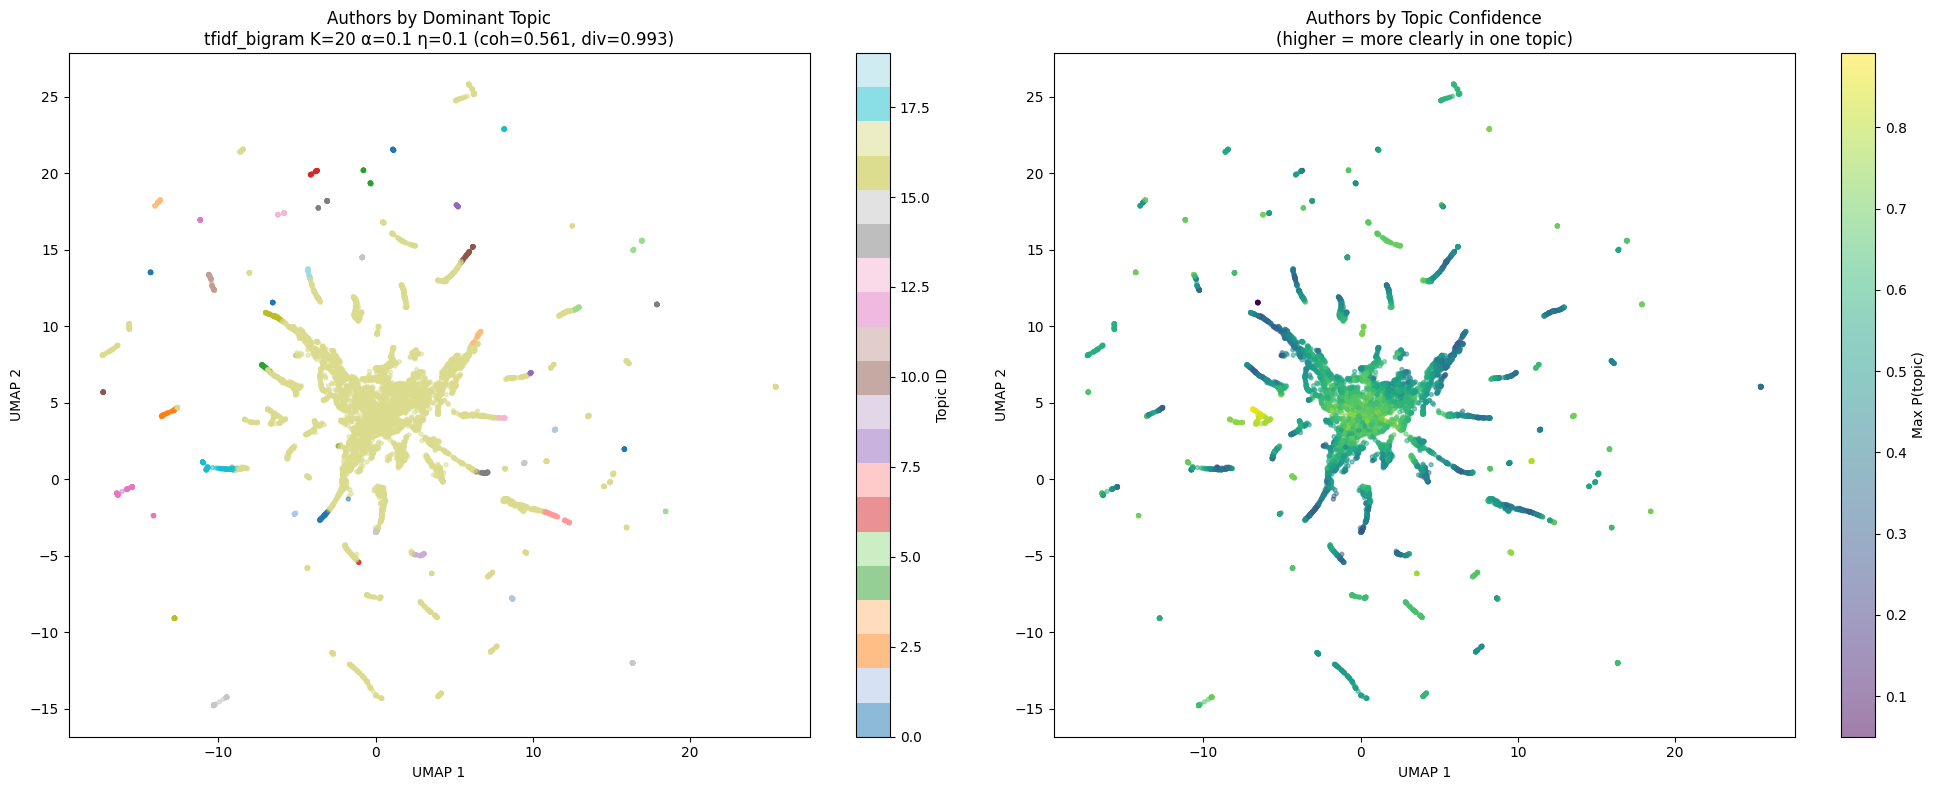

Saved → /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots/topic_sizes_focused_tfidf_bigram_k20.png


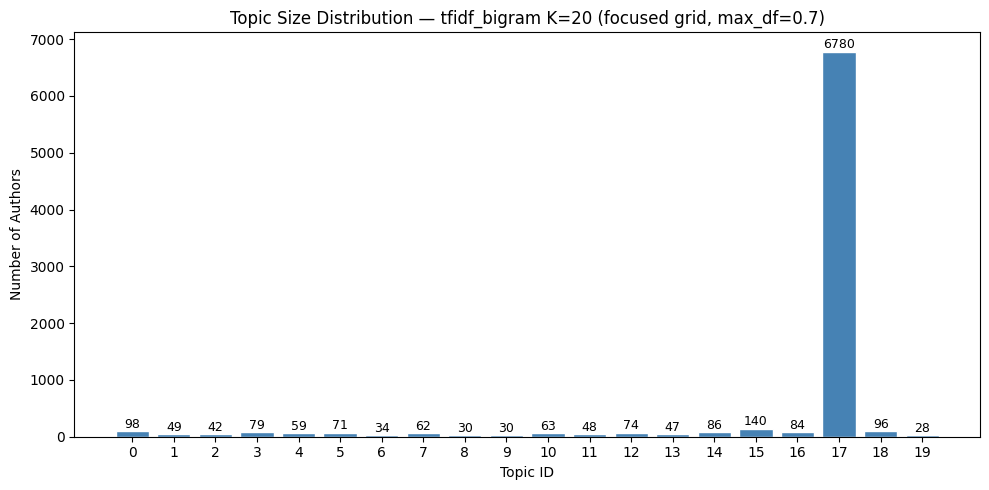

Saved → /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots/coherence_vs_diversity_focused.png


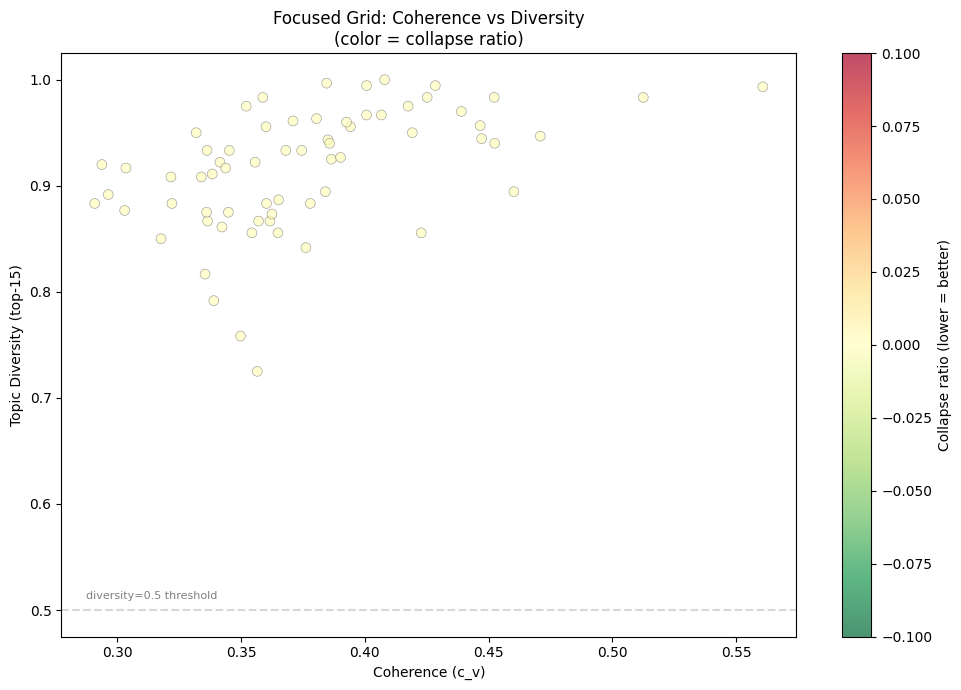

Saved → /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots/topic_correlation_focused_tfidf_bigram_k20.png


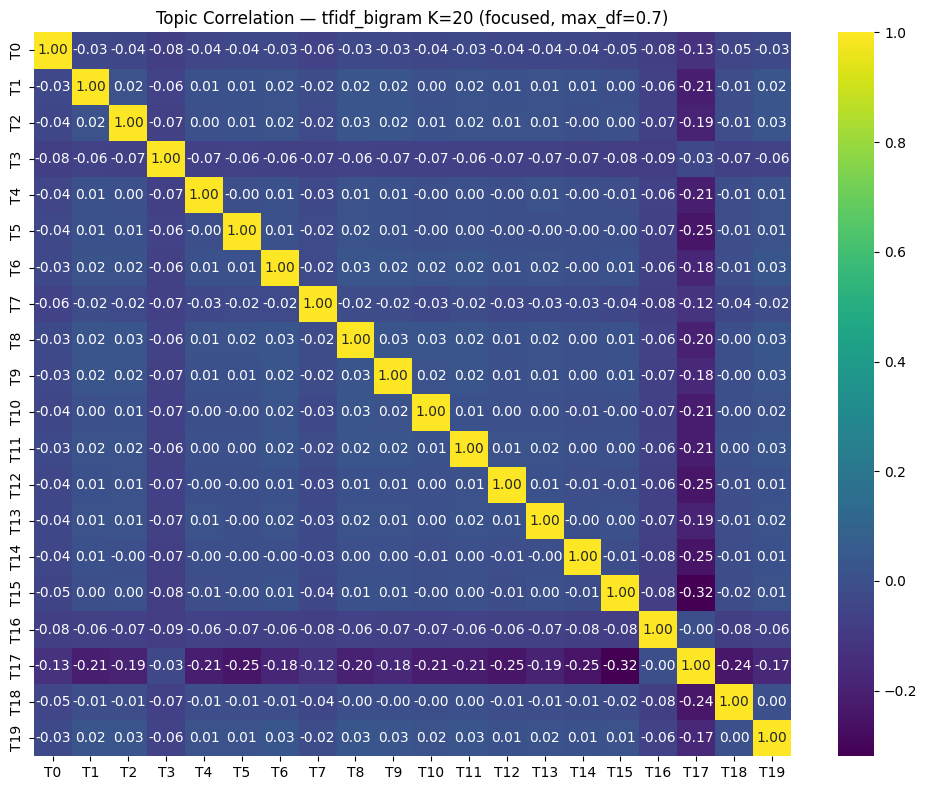

In [38]:
%%time
 

 
# %%
import umap
import matplotlib.pyplot as plt
import seaborn as sns
 
dominant_topic = theta.argmax(axis=1)
max_prob = theta.max(axis=1)
 
# UMAP on topic distributions (not DTM — faster and more interpretable)
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    metric='cosine', random_state=42)
embedding = reducer.fit_transform(theta)
 
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
 
# Left: colored by topic
cmap = 'tab20' if K > 10 else 'tab10'
sc1 = axes[0].scatter(embedding[:, 0], embedding[:, 1],
                      c=dominant_topic, cmap=cmap, alpha=0.5, s=8)
axes[0].set_title(f"Authors by Dominant Topic\n{rep} K={K} α={best['alpha']} η={best['eta']} "
                  f"(coh={best['coherence_c_v']:.3f}, div={best['diversity']:.3f})")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
plt.colorbar(sc1, ax=axes[0], label="Topic ID")
 
# Right: colored by assignment confidence
sc2 = axes[1].scatter(embedding[:, 0], embedding[:, 1],
                      c=max_prob, cmap='viridis', alpha=0.5, s=8)
axes[1].set_title("Authors by Topic Confidence\n(higher = more clearly in one topic)")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
plt.colorbar(sc2, ax=axes[1], label="Max P(topic)")
 
plt.tight_layout()
PLOT_DIR.mkdir(parents=True, exist_ok=True)
umap_path = PLOT_DIR / f"umap_focused_{rep}_k{K}.png"
plt.savefig(umap_path, dpi=150, bbox_inches='tight')
print(f"Saved → {umap_path}")
plt.show()
 
 
# %%
# Topic size bar chart
fig, ax = plt.subplots(figsize=(10, 5))
topic_counts = pd.Series(dominant_topic).value_counts().sort_index()
bars = ax.bar(topic_counts.index, topic_counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel("Topic ID")
ax.set_ylabel("Number of Authors")
ax.set_title(f"Topic Size Distribution — {rep} K={K} (focused grid, max_df={MAX_DF_NEW})")
ax.set_xticks(range(K))
for bar, count in zip(bars, topic_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(PLOT_DIR / f"topic_sizes_focused_{rep}_k{K}.png", dpi=150)
print(f"Saved → {PLOT_DIR / f'topic_sizes_focused_{rep}_k{K}.png'}")
plt.show()
 
 
# %%
# Coherence vs Diversity scatter — original grid vs focused
fig, ax = plt.subplots(figsize=(10, 7))
 
# Original grid (all models)                                      # skip when running from memory 
#ax.scatter(df_grid['coherence_c_v'], [np.nan]*len(df_grid),
 #          alpha=0)  # invisible — just to set x scale
 
# Focused grid
sc = ax.scatter(df_focused['coherence_c_v'], df_focused['diversity'],
                c=df_focused['collapse_ratio'], cmap='RdYlGn_r',
                s=50, alpha=0.7, edgecolors='gray', linewidths=0.5)
plt.colorbar(sc, ax=ax, label="Collapse ratio (lower = better)")
ax.set_xlabel("Coherence (c_v)")
ax.set_ylabel("Topic Diversity (top-15)")
ax.set_title("Focused Grid: Coherence vs Diversity\n(color = collapse ratio)")
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
ax.annotate("diversity=0.5 threshold", xy=(ax.get_xlim()[0] + 0.01, 0.51),
            fontsize=8, color='gray')
plt.tight_layout()
plt.savefig(PLOT_DIR / "coherence_vs_diversity_focused.png", dpi=150)
print(f"Saved → {PLOT_DIR / 'coherence_vs_diversity_focused.png'}")
plt.show()
 
 
# %%
# Correlation heatmap for best focused model
topic_cols_best = [c for c in df_theta_best.columns if c.startswith('topic_')]
corr = df_theta_best[topic_cols_best].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis",
            xticklabels=[f"T{i}" for i in range(K)],
            yticklabels=[f"T{i}" for i in range(K)])
plt.title(f"Topic Correlation — {rep} K={K} (focused, max_df={MAX_DF_NEW})")
plt.tight_layout()
plt.savefig(PLOT_DIR / f"topic_correlation_focused_{rep}_k{K}.png", dpi=150)
print(f"Saved → {PLOT_DIR / f'topic_correlation_focused_{rep}_k{K}.png'}")
plt.show()
 



# ## 10.8 HDBSCAN Clustering on Topic Distributions

HDBSCAN clusters: 129
Noise points: 1231 (15.4%)
Saved → /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots/hdbscan_vs_lda_tfidf_bigram_k20.png


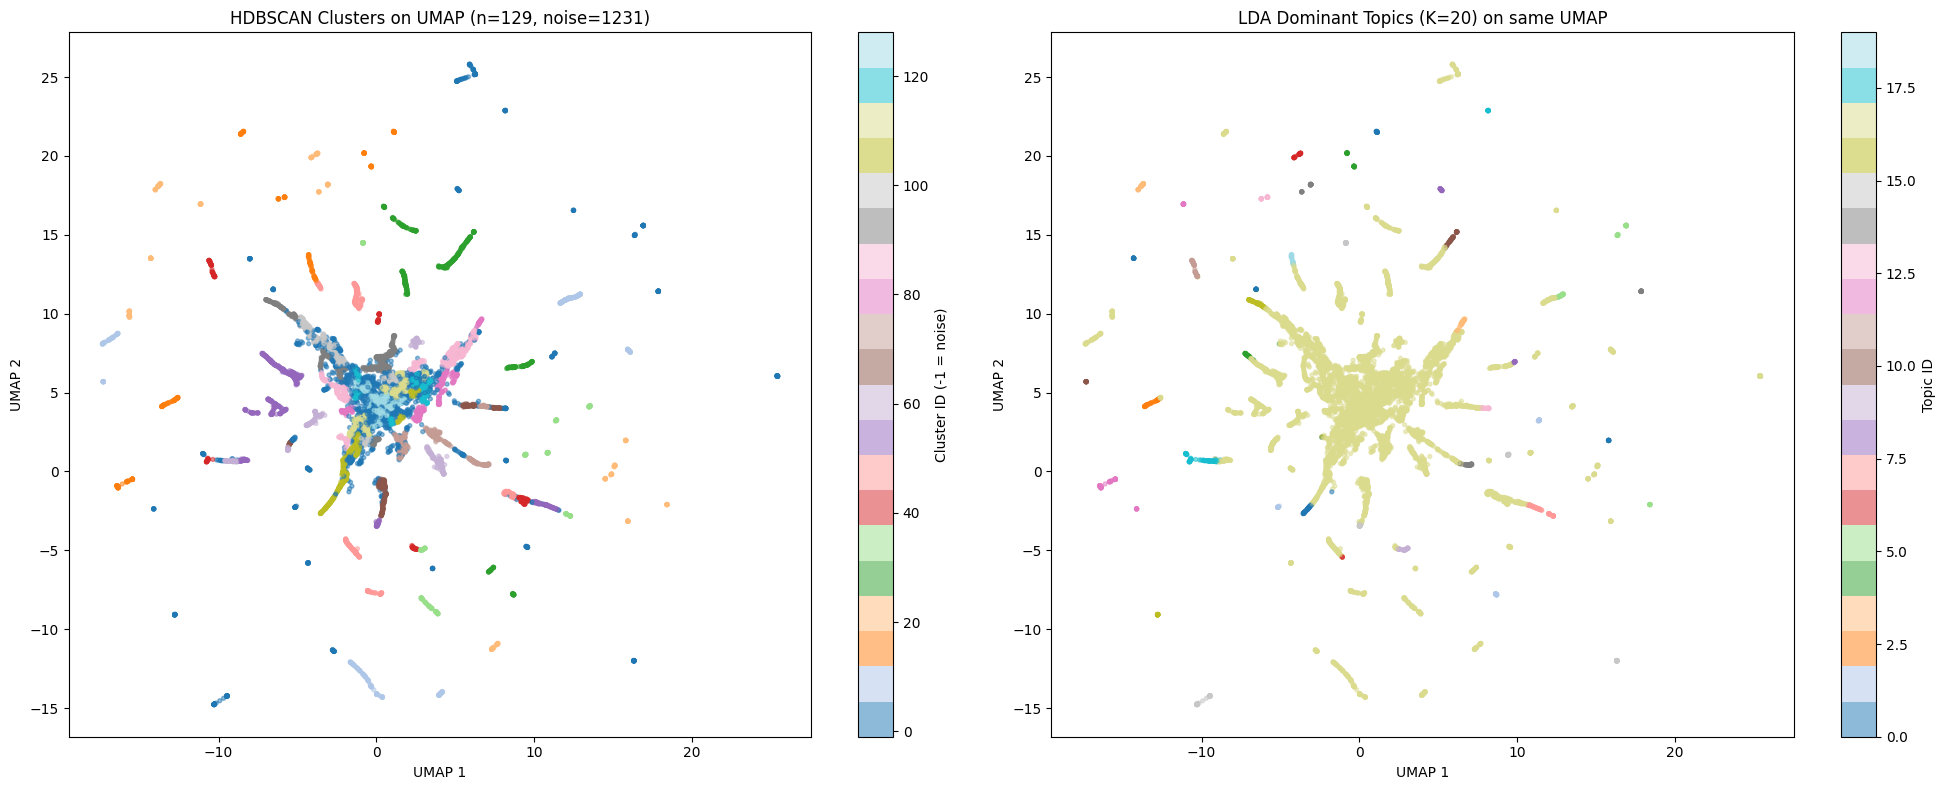

Saved → /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/hdbscan_author_clusters.csv


In [39]:
%%time

#
# Instead of using LDA's dominant topic assignment (hard argmax),
# cluster authors in UMAP space using HDBSCAN. This can reveal
# structure that LDA's topic assignments miss.
 
# %%
try:
    from hdbscan import HDBSCAN as HDBSCAN_cls
    HDBSCAN_OK = True
except ImportError:
    HDBSCAN_OK = False
    print("hdbscan not installed. Run:")
    print("  pip install hdbscan --break-system-packages")
    print("or in terminal:")
    print("  /projects/.../envs/twitter-ai/bin/pip install hdbscan")
 
if HDBSCAN_OK:
    clusterer = HDBSCAN_cls(
        min_cluster_size=20,
        min_samples=5,
        metric='euclidean',
    )
    hdb_labels = clusterer.fit_predict(embedding)  # clustering on UMAP 2D
 
    n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
    n_noise = list(hdb_labels).count(-1)
    print(f"HDBSCAN clusters: {n_clusters}")
    print(f"Noise points: {n_noise} ({100*n_noise/len(hdb_labels):.1f}%)")
 
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
 
    # Left: HDBSCAN clusters
    sc1 = axes[0].scatter(embedding[:, 0], embedding[:, 1],
                          c=hdb_labels, cmap='tab20', alpha=0.5, s=8)
    axes[0].set_title(f"HDBSCAN Clusters on UMAP (n={n_clusters}, noise={n_noise})")
    axes[0].set_xlabel("UMAP 1")
    axes[0].set_ylabel("UMAP 2")
    plt.colorbar(sc1, ax=axes[0], label="Cluster ID (-1 = noise)")
 
    # Right: LDA topics for comparison
    sc2 = axes[1].scatter(embedding[:, 0], embedding[:, 1],
                          c=dominant_topic, cmap='tab20' if K > 10 else 'tab10',
                          alpha=0.5, s=8)
    axes[1].set_title(f"LDA Dominant Topics (K={K}) on same UMAP")
    axes[1].set_xlabel("UMAP 1")
    axes[1].set_ylabel("UMAP 2")
    plt.colorbar(sc2, ax=axes[1], label="Topic ID")
 
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"hdbscan_vs_lda_{rep}_k{K}.png", dpi=150, bbox_inches='tight')
    print(f"Saved → {PLOT_DIR / f'hdbscan_vs_lda_{rep}_k{K}.png'}")
    plt.show()
 
    # Save assignments
    df_hdb = pd.DataFrame({
        'author_id': author_ids,
        'hdbscan_cluster': hdb_labels,
        'lda_dominant_topic': dominant_topic,
        'lda_max_prob': max_prob.round(4),
    })
    df_hdb.to_csv(OUT_DIR / "hdbscan_author_clusters.csv", index=False)
    print(f"Saved → {OUT_DIR / 'hdbscan_author_clusters.csv'}")

Largest topic: 1896 / 8000 (23.7%)
Topic 0 (n=764): chatgpt, design, new, ideas, let, post, looking, live, space, episode
Topic 1 (n=1558): chatgpt, google, openai, search, new, bing, microsoft, gpt, text, years
Topic 2 (n=254): notion, join, magic, waitlist, alpha, day, marketing, job, ways, playing
Topic 3 (n=310): intelligence, artificial, fun, thing, project, bot, using, character, year, new
Topic 4 (n=1331): going, just, like, model, things, chatgpt, does, think, gpt, change
Topic 5 (n=347): generated, look, did, chatgpt, like, images, code, start, weird, ask
Topic 6 (n=231): art, artists, free, know, don, artist, use, people, shit, lensa
Topic 7 (n=1896): chatgpt, use, writing, like, content, want, think, create, time, good
Topic 8 (n=213): latest, thanks, real, time, llama, chatbot, wow, stories, replaced, daily
Topic 9 (n=212): replace, midjourney, creativity, amazing, thank, weeks, blockchain, cases, use, single
Topic 10 (n=553): chatgpt, people, media, making, believe, twitte

/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/envs/twitter-ai/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


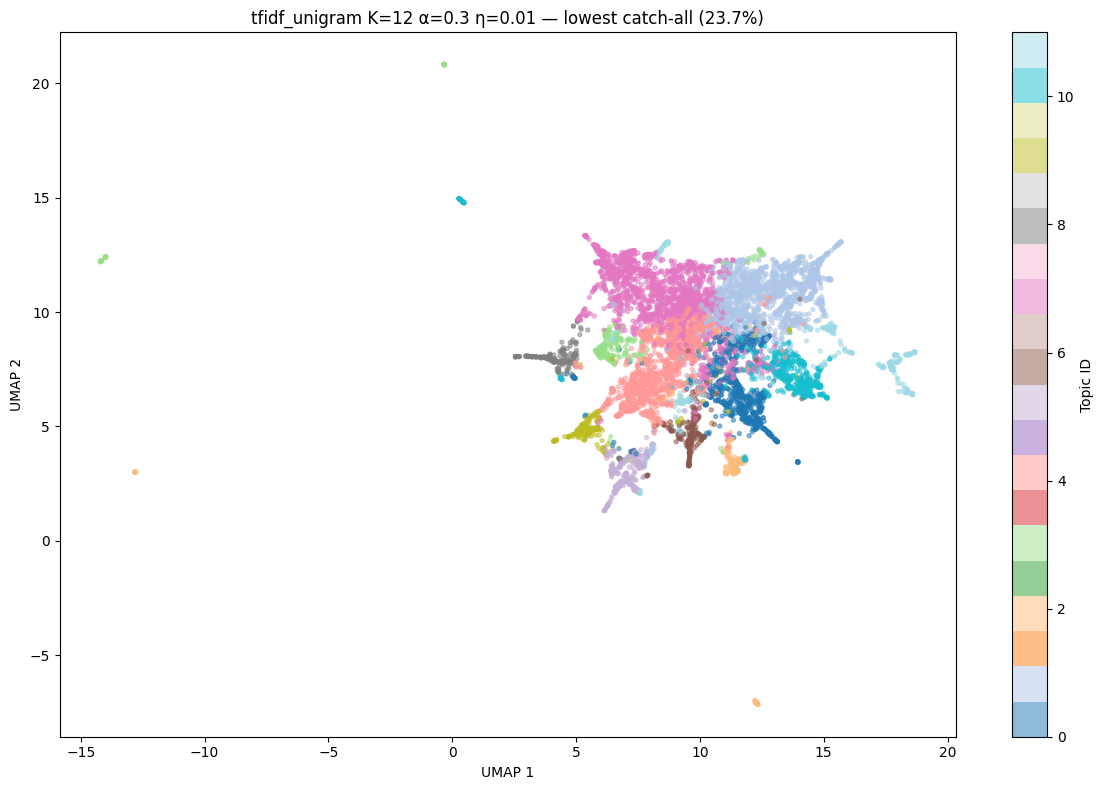

In [40]:
%%time
# Re-fit the lowest catch-all model
vec_low, dtm_low = focused_vecs['tfidf_unigram']
fn_low = vec_low.get_feature_names_out()

lda_low = LatentDirichletAllocation(
    n_components=12, doc_topic_prior=0.3, topic_word_prior=0.01,
    max_iter=50, random_state=42, learning_method='batch', verbose=0,
)
lda_low.fit(dtm_low)
theta_low = lda_low.transform(dtm_low)
dom_low = theta_low.argmax(axis=1)

print(f"Largest topic: {np.max(np.bincount(dom_low))} / {len(dom_low)} "
      f"({np.max(np.bincount(dom_low))/len(dom_low):.1%})")

# Topics
for t_idx, topic in enumerate(lda_low.components_):
    top_idx = topic.argsort()[:-11:-1]
    terms = [fn_low[i] for i in top_idx]
    n = np.sum(dom_low == t_idx)
    print(f"Topic {t_idx} (n={n}): {', '.join(terms)}")

# UMAP
reducer_low = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        metric='cosine', random_state=42)
emb_low = reducer_low.fit_transform(theta_low)

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(emb_low[:, 0], emb_low[:, 1], c=dom_low, cmap='tab20',
                alpha=0.5, s=8)
ax.set_title(f"tfidf_unigram K=12 α=0.3 η=0.01 — lowest catch-all (23.7%)")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
plt.colorbar(sc, ax=ax, label="Topic ID")
plt.tight_layout()
plt.savefig(PLOT_DIR / "umap_lowest_catchall_k12.png", dpi=150)
plt.show()

In [43]:
%%time
# Save everything for this model
np.save(str(OUT_DIR / "theta_lowest_catchall_k12.npy"), theta_low)
np.save(str(OUT_DIR / "embedding_lowest_catchall_k12.npy"), emb_low)
pd.Series(dom_low).to_csv(OUT_DIR / "dominant_topics_lowest_catchall_k12.csv", index=False)
print("Saved theta, embedding, and dominant topics")

Saved theta, embedding, and dominant topics


In [1]:
%%time
# Topic labels for the K=12 low-catch-all model
topic_labels = {
    0: "AI Design & Creative Ideas",
    1: "ChatGPT & Big Tech News",
    2: "Notion AI / Product Launches",
    3: "AI Bots & Fun Projects",
    4: "AI Discourse & Opinion",
    5: "AI-Generated Images & Code",
    6: "Artists vs AI / Lensa",
    7: "AI Writing & Content Tools",
    8: "AI Chatbots & Daily Use",
    9: "Midjourney & Creativity Debate",
    10: "AI & Social Media Reactions",
    11: "ChatGPT Prompts & Use Cases",
}

import umap
import matplotlib.pyplot as plt
import numpy as np

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    metric='cosine', random_state=42)
emb = reducer.fit_transform(theta_low)

fig, ax = plt.subplots(figsize=(14, 10))
for t_id in range(12):
    mask = dom_low == t_id
    ax.scatter(emb[mask, 0], emb[mask, 1], s=8, alpha=0.5,
               label=f"T{t_id}: {topic_labels[t_id]}")
    # Label at centroid
    cx, cy = emb[mask, 0].mean(), emb[mask, 1].mean()
    ax.annotate(topic_labels[t_id], (cx, cy), fontsize=7,
                fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_title("Author-Level LDA K=12 — Lowest Catch-All (23.7%)\ntfidf_unigram α=0.3 η=0.01", fontsize=13)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, markerscale=3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "umap_k12_labeled.png", dpi=150, bbox_inches='tight')
plt.show()

/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/envs/twitter-ai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'theta_low' is not defined

In [ ]:
%%time
# Re-fit the lowest catch-all model
vec_low, dtm_low = focused_vecs['tfidf_unigram']
fn_low = vec_low.get_feature_names_out()

lda_low = LatentDirichletAllocation(
    n_components=12, doc_topic_prior=0.3, topic_word_prior=0.01,
    max_iter=50, random_state=42, learning_method='batch', verbose=0,
)
lda_low.fit(dtm_low)
theta_low = lda_low.transform(dtm_low)
dom_low = theta_low.argmax(axis=1)

print(f"Largest topic: {np.max(np.bincount(dom_low))} / {len(dom_low)} "
      f"({np.max(np.bincount(dom_low))/len(dom_low):.1%})")

# Topics
for t_idx, topic in enumerate(lda_low.components_):
    top_idx = topic.argsort()[:-11:-1]
    terms = [fn_low[i] for i in top_idx]
    n = np.sum(dom_low == t_idx)
    print(f"Topic {t_idx} (n={n}): {', '.join(terms)}")

# UMAP
reducer_low = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        metric='cosine', random_state=42)
emb_low = reducer_low.fit_transform(theta_low)

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(emb_low[:, 0], emb_low[:, 1], c=dom_low, cmap='tab20',
                alpha=0.5, s=8)
ax.set_title(f"tfidf_unigram K=12 α=0.3 η=0.01 — lowest catch-all (23.7%)")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
plt.colorbar(sc, ax=ax, label="Topic ID")
plt.tight_layout()
plt.savefig(PLOT_DIR / "umap_lowest_catchall_k12.png", dpi=150)
plt.show()

### Expanded HSBSCAN


# # 10.9 Higher-K Grid Search

In [ ]:
%%time

#
# HDBSCAN found 58 clusters — K=20 is too low.
# Topic 18 (1,865/2,812 authors = 66%) is a catch-all.
# This grid explores K=[25, 30, 35, 40] to see if it splits
# into interpretable sub-topics.
#
# Estimated runtime: ~25 min (72 models on 2,812 docs)

# %%
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.decomposition import LatentDirichletAllocation

K_HIGH        = [25, 30, 35, 40]
ALPHA_HIGH    = [0.01, 0.05, 0.1]
ETA_HIGH      = [0.01, 0.05, 0.1]
REP_HIGH      = ['tfidf_unigram', 'tfidf_bigram']

n_models = len(REP_HIGH) * len(K_HIGH) * len(ALPHA_HIGH) * len(ETA_HIGH)
print(f"Higher-K grid: {n_models} models")
print(f"  K: {K_HIGH}")
print(f"  Alpha: {ALPHA_HIGH}")
print(f"  Eta: {ETA_HIGH}")
print(f"  Reps: {REP_HIGH}")
print(f"  Using focused_vecs (max_df=0.7, already built)")

# %%
high_k_results = []
n_done = 0
t0 = time.time()

for rep in REP_HIGH:
    vec, dtm = focused_vecs[rep]
    feature_names = vec.get_feature_names_out()

    for K in K_HIGH:
        for alpha in ALPHA_HIGH:
            for eta in ETA_HIGH:
                n_done += 1
                lda = LatentDirichletAllocation(
                    n_components=K,
                    doc_topic_prior=alpha,
                    topic_word_prior=eta,
                    max_iter=50,
                    random_state=42,
                    learning_method='batch',
                    verbose=0,
                )
                lda.fit(dtm)

                # Top terms
                topic_term_lists = []
                for topic in lda.components_:
                    top_idx = topic.argsort()[:-16:-1]
                    topic_term_lists.append([feature_names[i] for i in top_idx])

                # Coherence
                try:
                    cm = CoherenceModel(
                        topics=topic_term_lists,
                        texts=tokens_by_doc,
                        dictionary=gensim_dict,
                        coherence='c_v',
                    )
                    coh = cm.get_coherence()
                except:
                    coh = np.nan

                # Diversity & collapse
                div = compute_topic_diversity_lda(vec, lda)
                cr, nc, _ = detect_topic_collapse(vec, lda)

                # Perplexity
                try:
                    perp = float(np.exp(-lda.score(dtm) / dtm.sum()))
                except:
                    perp = np.nan

                # Largest topic share (the catch-all metric)
                theta_tmp = lda.transform(dtm)
                dom = theta_tmp.argmax(axis=1)
                largest_topic_pct = np.max(np.bincount(dom)) / len(dom)

                high_k_results.append({
                    'representation': rep, 'K': K,
                    'alpha': alpha, 'eta': eta,
                    'coherence_c_v': round(coh, 4) if not np.isnan(coh) else np.nan,
                    'diversity': round(div, 4),
                    'collapse_ratio': round(cr, 4),
                    'perplexity_like': round(perp, 2) if not np.isnan(perp) else np.nan,
                    'largest_topic_pct': round(largest_topic_pct, 4),
                    'max_df': 0.7,
                })

                if n_done % 12 == 0 or n_done == n_models:
                    elapsed = (time.time() - t0) / 60
                    print(f"  [{n_done}/{n_models}] {rep} K={K} α={alpha} η={eta} "
                          f"| coh={coh:.3f} div={div:.3f} coll={cr:.2f} "
                          f"largest={largest_topic_pct:.1%} | {elapsed:.1f} min")

df_high = pd.DataFrame(high_k_results)
df_high.to_csv(OUT_DIR / "high_k_grid_results.csv", index=False)
print(f"\nSaved {len(df_high)} models → {OUT_DIR / 'high_k_grid_results.csv'}")
print(f"Total time: {(time.time() - t0) / 60:.1f} min")






# ## 10.10 Rank Higher-K Models

In [ ]:
%%time


#
# Same combined score but now we also penalize catch-all dominance.
# A model where the largest topic has >50% of authors is suspicious.

# %%
df_h = df_high.copy()

# Normalize
for col in ['coherence_c_v', 'diversity']:
    mn, mx = df_h[col].min(), df_h[col].max()
    df_h[f'{col}_n'] = (df_h[col] - mn) / (mx - mn) if mx > mn else 0.5

df_h['collapse_n'] = 1.0 - df_h['collapse_ratio']

# Evenness: penalize models where one topic dominates
# Ideal largest_topic_pct = 1/K (uniform). We score as 1 - deviation from uniform.
df_h['evenness'] = 1.0 - (df_h['largest_topic_pct'] - 1.0 / df_h['K']).clip(lower=0)

df_h['combined_score'] = (
    0.25 * df_h['coherence_c_v_n'] +
    0.30 * df_h['diversity_n'] +
    0.15 * df_h['collapse_n'] +
    0.30 * df_h['evenness']
)
df_h = df_h.sort_values('combined_score', ascending=False)

print("=" * 90)
print("HIGHER-K GRID — Top 15 by combined score")
print("(0.25×coherence + 0.30×diversity + 0.15×(1-collapse) + 0.30×evenness)")
print("=" * 90)
print(df_h[['representation', 'K', 'alpha', 'eta',
            'coherence_c_v', 'diversity', 'collapse_ratio',
            'largest_topic_pct', 'combined_score']
          ].head(15).to_string(index=False))

# Compare: how does largest topic % change with K?
print("\n--- Largest topic % by K (median across all models) ---")
for k in K_HIGH:
    sub = df_high[df_high['K'] == k]
    print(f"  K={k}: median largest topic = {sub['largest_topic_pct'].median():.1%}, "
          f"mean coherence = {sub['coherence_c_v'].mean():.3f}")




# ## 10.11 Fit Best Higher-K Model & Display Topics

In [ ]:
%%time



# %%
best_h = df_h.iloc[0]
rep_h = best_h['representation']
K_h = int(best_h['K'])
print(f"Best higher-K model: {rep_h} K={K_h} α={best_h['alpha']} η={best_h['eta']}")
print(f"  Coherence:     {best_h['coherence_c_v']:.4f}")
print(f"  Diversity:     {best_h['diversity']:.4f}")
print(f"  Collapse:      {best_h['collapse_ratio']:.4f}")
print(f"  Largest topic: {best_h['largest_topic_pct']:.1%}")
print(f"  Combined:      {best_h['combined_score']:.4f}")

vec_h, dtm_h = focused_vecs[rep_h]
fn_h = vec_h.get_feature_names_out()

best_lda_h = LatentDirichletAllocation(
    n_components=K_h,
    doc_topic_prior=best_h['alpha'],
    topic_word_prior=best_h['eta'],
    max_iter=50, random_state=42,
    learning_method='batch', verbose=0,
)
best_lda_h.fit(dtm_h)

theta_h = best_lda_h.transform(dtm_h)
dom_h = theta_h.argmax(axis=1)
max_prob_h = theta_h.max(axis=1)

print(f"\n{'=' * 70}")
print(f"Topics — {rep_h} K={K_h} α={best_h['alpha']} η={best_h['eta']}")
print(f"{'=' * 70}")
for t_idx, topic in enumerate(best_lda_h.components_):
    top_idx = topic.argsort()[:-16:-1]
    terms = [fn_h[i] for i in top_idx]
    n_authors = np.sum(dom_h == t_idx)
    print(f"\nTopic {t_idx} (n={n_authors}): {', '.join(terms)}")

# Save artifacts
a_tag = str(best_h['alpha']).replace('.', 'p')
e_tag = str(best_h['eta']).replace('.', 'p')
rep_dir_h = OUT_DIR / rep_h
rep_dir_h.mkdir(parents=True, exist_ok=True)

df_theta_h = to_prob_df(theta_h, author_ids)
theta_out_h = rep_dir_h / f"author_topic_matrix_{rep_h}_k{K_h}_a{a_tag}_e{e_tag}_highK.csv"
df_theta_h.to_csv(theta_out_h, index=False)
print(f"\nSaved theta → {theta_out_h}")

rows_h = []
for t_idx, topic in enumerate(best_lda_h.components_):
    top_idx = topic.argsort()[:-21:-1]
    for rank, i in enumerate(top_idx):
        rows_h.append({
            'topic': t_idx, 'term': fn_h[i],
            'weight': float(topic[i]), 'rank': rank,
        })
terms_out_h = rep_dir_h / f"author_topics_{rep_h}_k{K_h}_a{a_tag}_e{e_tag}_highK_top_terms.csv"
pd.DataFrame(rows_h).to_csv(terms_out_h, index=False)
print(f"Saved top terms → {terms_out_h}")




# ## 10.12 Visualizations — Higher-K vs K=20 Comparison

In [41]:
%%time


# %%
# --- UMAP on higher-K theta ---
reducer_h = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                      metric='cosine', random_state=42)
embedding_h = reducer_h.fit_transform(theta_h)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left: K=20 (from earlier — recompute UMAP on same data for fair comparison)
# Use the best_lda from section 10.6
theta_k20 = best_lda.transform(dtm)
reducer_k20 = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        metric='cosine', random_state=42)
embedding_k20 = reducer_k20.fit_transform(theta_k20)
dom_k20 = theta_k20.argmax(axis=1)

sc1 = axes[0].scatter(embedding_k20[:, 0], embedding_k20[:, 1],
                      c=dom_k20, cmap='tab20', alpha=0.5, s=8)
axes[0].set_title(f"K=20 (focused) — largest topic: {np.max(np.bincount(dom_k20))/len(dom_k20):.0%}")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

# Right: higher K
cmap_h = 'nipy_spectral' if K_h > 20 else 'tab20'
sc2 = axes[1].scatter(embedding_h[:, 0], embedding_h[:, 1],
                      c=dom_h, cmap=cmap_h, alpha=0.5, s=8)
axes[1].set_title(f"K={K_h} — largest topic: {best_h['largest_topic_pct']:.0%}")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.suptitle(f"UMAP Comparison: K=20 vs K={K_h} ({rep_h})", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / f"umap_k20_vs_k{K_h}.png", dpi=150, bbox_inches='tight')
print(f"Saved → {PLOT_DIR / f'umap_k20_vs_k{K_h}.png'}")
plt.show()


# %%
# --- Topic size distributions side by side ---
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# K=20
counts_k20 = pd.Series(dom_k20).value_counts().sort_index()
axes[0].bar(counts_k20.index, counts_k20.values, color='steelblue', edgecolor='white')
axes[0].set_title(f"K=20 — Topic sizes")
axes[0].set_xlabel("Topic ID")
axes[0].set_ylabel("Authors")
for i, (tid, cnt) in enumerate(counts_k20.items()):
    if cnt > 50:
        axes[0].text(tid, cnt + 10, str(cnt), ha='center', fontsize=7)

# Higher K
counts_h = pd.Series(dom_h).value_counts().sort_index()
axes[1].bar(counts_h.index, counts_h.values, color='darkorange', edgecolor='white')
axes[1].set_title(f"K={K_h} — Topic sizes")
axes[1].set_xlabel("Topic ID")
axes[1].set_ylabel("Authors")
for i, (tid, cnt) in enumerate(counts_h.items()):
    if cnt > 50:
        axes[1].text(tid, cnt + 10, str(cnt), ha='center', fontsize=7)

plt.suptitle("Topic Size Distribution: K=20 vs Higher K", fontsize=13)
plt.tight_layout()
plt.savefig(PLOT_DIR / f"topic_sizes_k20_vs_k{K_h}.png", dpi=150, bbox_inches='tight')
print(f"Saved → {PLOT_DIR / f'topic_sizes_k20_vs_k{K_h}.png'}")
plt.show()


# %%
# --- Coherence vs K curve (combining focused + high-K grids) ---
df_all = pd.concat([df_focused, df_high], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: coherence vs K
for rep_name in REP_HIGH:
    sub = df_all[df_all['representation'] == rep_name]
    grouped = sub.groupby('K')['coherence_c_v'].agg(['mean', 'max'])
    axes[0].plot(grouped.index, grouped['max'], 'o-', label=f'{rep_name} (max)', alpha=0.8)
    axes[0].plot(grouped.index, grouped['mean'], 's--', label=f'{rep_name} (mean)', alpha=0.5)
axes[0].set_xlabel("K")
axes[0].set_ylabel("Coherence (c_v)")
axes[0].set_title("Coherence vs K")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Panel 2: diversity vs K
for rep_name in REP_HIGH:
    sub = df_all[df_all['representation'] == rep_name]
    grouped = sub.groupby('K')['diversity'].agg(['mean', 'max'])
    axes[1].plot(grouped.index, grouped['max'], 'o-', label=f'{rep_name} (max)', alpha=0.8)
    axes[1].plot(grouped.index, grouped['mean'], 's--', label=f'{rep_name} (mean)', alpha=0.5)
axes[1].set_xlabel("K")
axes[1].set_ylabel("Diversity")
axes[1].set_title("Topic Diversity vs K")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Panel 3: largest topic % vs K
for rep_name in REP_HIGH:
    sub = df_all[df_all['representation'] == rep_name]
    grouped = sub.groupby('K')['largest_topic_pct'].agg(['mean', 'min'])
    axes[2].plot(grouped.index, grouped['min'], 'o-', label=f'{rep_name} (min)', alpha=0.8)
    axes[2].plot(grouped.index, grouped['mean'], 's--', label=f'{rep_name} (mean)', alpha=0.5)
axes[2].set_xlabel("K")
axes[2].set_ylabel("Largest topic %")
axes[2].set_title("Catch-all Dominance vs K")
axes[2].axhline(y=0.5, color='red', linestyle='--', alpha=0.3, label='50% threshold')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle("Model Quality Across K (focused + high-K grids)", fontsize=13)
plt.tight_layout()
plt.savefig(PLOT_DIR / "quality_vs_K_combined.png", dpi=150, bbox_inches='tight')
print(f"Saved → {PLOT_DIR / 'quality_vs_K_combined.png'}")
plt.show()


# %%
# --- Confidence plot for higher-K model ---
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(embedding_h[:, 0], embedding_h[:, 1],
                c=max_prob_h, cmap='viridis', alpha=0.5, s=8)
ax.set_title(f"Topic Confidence — K={K_h}\n(higher = author more clearly in one topic)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.colorbar(sc, ax=ax, label="Max P(topic)")
plt.tight_layout()
plt.savefig(PLOT_DIR / f"umap_confidence_k{K_h}.png", dpi=150, bbox_inches='tight')
print(f"Saved → {PLOT_DIR / f'umap_confidence_k{K_h}.png'}")
plt.show()



# %%
# --- HDBSCAN on higher-K embedding ---
if HDBSCAN_OK:
    from hdbscan import HDBSCAN as HDBSCAN_cls
    clusterer_h = HDBSCAN_cls(min_cluster_size=20, min_samples=5, metric='euclidean')
    hdb_h = clusterer_h.fit_predict(embedding_h)

    n_cl_h = len(set(hdb_h)) - (1 if -1 in hdb_h else 0)
    n_noise_h = list(hdb_h).count(-1)
    print(f"HDBSCAN on K={K_h} embedding: {n_cl_h} clusters, {n_noise_h} noise ({100*n_noise_h/len(hdb_h):.1f}%)")

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    sc1 = axes[0].scatter(embedding_h[:, 0], embedding_h[:, 1],
                          c=hdb_h, cmap='tab20', alpha=0.5, s=8)
    axes[0].set_title(f"HDBSCAN on K={K_h} UMAP (n={n_cl_h}, noise={n_noise_h})")
    axes[0].set_xlabel("UMAP 1")
    axes[0].set_ylabel("UMAP 2")

    sc2 = axes[1].scatter(embedding_h[:, 0], embedding_h[:, 1],
                          c=dom_h, cmap='nipy_spectral' if K_h > 20 else 'tab20',
                          alpha=0.5, s=8)
    axes[1].set_title(f"LDA Topics (K={K_h}) on same UMAP")
    axes[1].set_xlabel("UMAP 1")
    axes[1].set_ylabel("UMAP 2")

    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"hdbscan_vs_lda_k{K_h}.png", dpi=150, bbox_inches='tight')
    print(f"Saved → {PLOT_DIR / f'hdbscan_vs_lda_k{K_h}.png'}")
    plt.show()



NameError: name 'theta_h' is not defined

In [ ]:
%%time
pip install pyLDAvis --break-system-packages

In [ ]:
%%time
from sklearn.decomposition import LatentDirichletAllocation

# Use the best model from the focused grid
rep = 'tfidf_bigram'
K = 20
alpha = 0.01
eta = 0.1

vec, dtm = focused_vecs[rep]

best_lda = LatentDirichletAllocation(
    n_components=K,
    doc_topic_prior=alpha,
    topic_word_prior=eta,
    max_iter=50, random_state=42,
    learning_method='batch', verbose=0,
)
best_lda.fit(dtm)
print(f"Re-fitted: {rep} K={K} α={alpha} η={eta}")

In [ ]:
%%time
import pyLDAvis
try:
    import pyLDAvis.sklearn as pyldavis_sklearn
except ImportError:
    import pyLDAvis.lda_model as pyldavis_sklearn

from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(vocabulary=vec.vocabulary_)
count_dtm = count_vec.fit_transform(corpus)

vis_data = pyldavis_sklearn.prepare(best_lda, count_dtm, count_vec, mds='tsne')
pyLDAvis.save_html(vis_data, str(OUT_DIR / f"pyldavis_{rep}_k{K}.html"))
print(f"Saved → {OUT_DIR / f'pyldavis_{rep}_k{K}.html'}")
pyLDAvis.display(vis_data)

In [ ]:
%%time
# After fitting best_lda and having vec, dtm, best_lda in memory:
import pyLDAvis
import pyLDAvis.sklearn

# pyLDAvis expects raw count matrix, not TF-IDF
# Rebuild a count vectorizer with same vocab
from sklearn.feature_extraction.text import CountVectorizer
count_vec = CountVectorizer(vocabulary=vec.vocabulary_)
count_dtm = count_vec.fit_transform(corpus)

vis_data = pyLDAvis.sklearn.prepare(best_lda, count_dtm, count_vec, mds='tsne')
pyLDAvis.save_html(vis_data, str(OUT_DIR / f"pyldavis_{rep}_k{K}.html"))
print(f"Saved → {OUT_DIR / f'pyldavis_{rep}_k{K}.html'}")
pyLDAvis.display(vis_data)


# ## 10.13 Summary: K=20 vs Higher-K

In [ ]:
%%time



# %%
print("=" * 80)
print("COMPARISON SUMMARY")
print("=" * 80)

k20_largest = np.max(np.bincount(dom_k20)) / len(dom_k20)

print(f"""
K=20 (focused grid best):
  Model:         {rep} K=20 α={best['alpha']} η={best['eta']}
  Coherence:     {best['coherence_c_v']:.4f}
  Diversity:     {best['diversity']:.4f}
  Largest topic: {k20_largest:.1%} of authors
  HDBSCAN:       58 clusters (14.2% noise)

K={K_h} (higher-K grid best):
  Model:         {rep_h} K={K_h} α={best_h['alpha']} η={best_h['eta']}
  Coherence:     {best_h['coherence_c_v']:.4f}
  Diversity:     {best_h['diversity']:.4f}
  Largest topic: {best_h['largest_topic_pct']:.1%} of authors
  HDBSCAN:       {n_cl_h if HDBSCAN_OK else '?'} clusters ({100*n_noise_h/len(hdb_h):.1f}% noise)

Key question: did the catch-all topic (66% at K=20) split into
interpretable sub-topics, or just fragment into noise?
Check the topic terms above to answer this.
""")

print("--- Largest topic % across K values (best model per K) ---")
df_combined = pd.concat([df_focused, df_high], ignore_index=True)
for k_val in sorted(df_combined['K'].unique()):
    sub = df_combined[df_combined['K'] == k_val]
    if 'largest_topic_pct' in sub.columns and sub['largest_topic_pct'].notna().any():
        best_row = sub.loc[sub['largest_topic_pct'].idxmin()]
        print(f"  K={k_val:3d}: {best_row['largest_topic_pct']:.1%} "
              f"(coh={best_row['coherence_c_v']:.3f}, div={best_row['diversity']:.3f})")
    else:
        best_row = sub.loc[sub['coherence_c_v'].idxmax()]
        print(f"  K={k_val:3d}: largest_topic_pct not computed "
              f"(coh={best_row['coherence_c_v']:.3f}, div={best_row['diversity']:.3f})")


# # 12. UMAP & HDBSCAN Dimensionality Experiments

In [ ]:
%%time

#
# The current pipeline clusters on 2D UMAP — this loses too much structure.
# HDBSCAN suffers from the curse of dimensionality on raw high-dim data,
# but 2D is too aggressive. The sweet spot is 5-15D for clustering,
# with a separate 2D projection for visualization only.
#
# References:
#   - Allaoui et al. (2020). "Considerably Improving Clustering Algorithms
#     Using UMAP." ICCSA 2020.
#   - Pugachev & Burtsev (2021). "Short Text Clustering with Transformers."
#     arXiv:2102.00541.
#   - UMAP docs: "Using UMAP for Clustering"
#     (umap-learn.readthedocs.io/en/latest/clustering.html)
 
# %%
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hdbscan import HDBSCAN as HDBSCAN_cls
 
# theta and best_lda should exist from section 10.6
# theta shape = (n_authors, K) = (2812, 20)
print(f"Theta shape: {theta.shape}")
print(f"  = {theta.shape[0]} authors × {theta.shape[1]} topic dimensions")
print(f"  This is the INPUT to UMAP")
 




# ## 12.1 HDBSCAN at Multiple UMAP Dimensions
#

In [ ]:
%%time

# Test UMAP → HDBSCAN with n_components = [2, 3, 5, 10, 15]
# and compare cluster counts, noise ratios, and silhouette scores.
 
# %%
from sklearn.metrics import silhouette_score
 
DIMS_TO_TEST = [2, 3, 5, 10, 15]
dim_results = []
 
for n_dim in DIMS_TO_TEST:
    # UMAP reduction
    reducer = umap.UMAP(
        n_components=n_dim,
        n_neighbors=15,
        min_dist=0.0 if n_dim > 2 else 0.1,  # tighter for clustering dims
        metric='cosine',
        random_state=42,
    )
    emb = reducer.fit_transform(theta)
 
    # HDBSCAN
    clusterer = HDBSCAN_cls(
        min_cluster_size=20,
        min_samples=5,
        metric='euclidean',
    )
    labels = clusterer.fit_predict(emb)
 
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = 100 * n_noise / len(labels)
 
    # Silhouette (excluding noise points)
    mask = labels != -1
    if len(set(labels[mask])) > 1:
        sil = silhouette_score(emb[mask], labels[mask])
    else:
        sil = np.nan
 
    dim_results.append({
        'umap_dims': n_dim,
        'clusters': n_clusters,
        'noise': n_noise,
        'noise_pct': round(noise_pct, 1),
        'silhouette': round(sil, 3) if not np.isnan(sil) else np.nan,
    })
 
    print(f"  UMAP {n_dim}D → {n_clusters} clusters, {n_noise} noise ({noise_pct:.1f}%), "
          f"silhouette={sil:.3f}" if not np.isnan(sil) else
          f"  UMAP {n_dim}D → {n_clusters} clusters, {n_noise} noise ({noise_pct:.1f}%), "
          f"silhouette=N/A")
 
df_dims = pd.DataFrame(dim_results)
print("\n--- UMAP Dimensionality Comparison ---")
print(df_dims.to_string(index=False))
df_dims.to_csv(OUT_DIR / "umap_dimensionality_comparison.csv", index=False)
 
# %%
# Visualize the comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
axes[0].plot(df_dims['umap_dims'], df_dims['clusters'], 'o-', color='steelblue')
axes[0].set_xlabel("UMAP dimensions")
axes[0].set_ylabel("HDBSCAN clusters")
axes[0].set_title("Clusters found vs UMAP dimensionality")
axes[0].grid(True, alpha=0.3)
 
axes[1].plot(df_dims['umap_dims'], df_dims['noise_pct'], 's-', color='darkorange')
axes[1].set_xlabel("UMAP dimensions")
axes[1].set_ylabel("Noise %")
axes[1].set_title("HDBSCAN noise vs UMAP dimensionality")
axes[1].grid(True, alpha=0.3)
 
axes[2].plot(df_dims['umap_dims'], df_dims['silhouette'], 'D-', color='green')
axes[2].set_xlabel("UMAP dimensions")
axes[2].set_ylabel("Silhouette score")
axes[2].set_title("Cluster quality vs UMAP dimensionality")
axes[2].grid(True, alpha=0.3)
 
plt.suptitle("Effect of UMAP target dimensionality on HDBSCAN clustering", fontsize=13)
plt.tight_layout()
plt.savefig(PLOT_DIR / "umap_dims_vs_hdbscan.png", dpi=150, bbox_inches='tight')
print(f"Saved → {PLOT_DIR / 'umap_dims_vs_hdbscan.png'}")
plt.show()
 



# ## 12.2 HDBSCAN on Raw Theta (no UMAP) vs Best UMAP

# Compare: does UMAP actually help, or does HDBSCAN work directly on the 20-dim theta?

In [ ]:
%%time
 

 
# %%
# HDBSCAN directly on 20-dim theta
clusterer_raw = HDBSCAN_cls(min_cluster_size=20, min_samples=5, metric='euclidean')
labels_raw = clusterer_raw.fit_predict(theta)
 
n_cl_raw = len(set(labels_raw)) - (1 if -1 in labels_raw else 0)
n_noise_raw = list(labels_raw).count(-1)
mask_raw = labels_raw != -1
sil_raw = silhouette_score(theta[mask_raw], labels_raw[mask_raw]) if len(set(labels_raw[mask_raw])) > 1 else np.nan
 
print(f"HDBSCAN on raw theta (20D): {n_cl_raw} clusters, "
      f"{n_noise_raw} noise ({100*n_noise_raw/len(labels_raw):.1f}%), "
      f"silhouette={sil_raw:.3f}" if not np.isnan(sil_raw) else "N/A")
 
# Best UMAP dim from the sweep
best_dim_row = df_dims.loc[df_dims['silhouette'].idxmax()] if df_dims['silhouette'].notna().any() else df_dims.iloc[0]
best_n_dim = int(best_dim_row['umap_dims'])
print(f"\nBest UMAP dim by silhouette: {best_n_dim}D "
      f"({int(best_dim_row['clusters'])} clusters, sil={best_dim_row['silhouette']})")
 
print(f"\nConclusion: {'UMAP helps' if best_dim_row['silhouette'] > sil_raw else 'Raw theta is better'}")
 
 



# ## 12.3 3D UMAP Visualization

In [ ]:
%%time

 
# %%
# 3D UMAP for interactive exploration
reducer_3d = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1,
                       metric='cosine', random_state=42)
emb_3d = reducer_3d.fit_transform(theta)
 
# HDBSCAN on 3D
clusterer_3d = HDBSCAN_cls(min_cluster_size=20, min_samples=5, metric='euclidean')
labels_3d = clusterer_3d.fit_predict(emb_3d)
 
fig = plt.figure(figsize=(16, 7))
 
# Left: colored by LDA topic
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(emb_3d[:, 0], emb_3d[:, 1], emb_3d[:, 2],
                  c=dominant_topic, cmap='nipy_spectral', alpha=0.4, s=5)
ax1.set_title(f"3D UMAP — LDA topics (K={K})")
ax1.set_xlabel("UMAP 1"); ax1.set_ylabel("UMAP 2"); ax1.set_zlabel("UMAP 3")
 
# Right: colored by HDBSCAN on 3D
ax2 = fig.add_subplot(122, projection='3d')
n_cl_3d = len(set(labels_3d)) - (1 if -1 in labels_3d else 0)
sc2 = ax2.scatter(emb_3d[:, 0], emb_3d[:, 1], emb_3d[:, 2],
                  c=labels_3d, cmap='tab20', alpha=0.4, s=5)
ax2.set_title(f"3D UMAP — HDBSCAN ({n_cl_3d} clusters)")
ax2.set_xlabel("UMAP 1"); ax2.set_ylabel("UMAP 2"); ax2.set_zlabel("UMAP 3")
 
plt.tight_layout()
plt.savefig(PLOT_DIR / "umap_3d_lda_vs_hdbscan.png", dpi=150, bbox_inches='tight')
print(f"Saved → {PLOT_DIR / 'umap_3d_lda_vs_hdbscan.png'}")
plt.show()
 


# ## 12.4 Best Clustering Configuration Summary

In [ ]:
%%time
 

 
# %%
print("=" * 70)
print("CLUSTERING CONFIGURATION COMPARISON")
print("=" * 70)
print(f"""
Pipeline: 5,520-dim DTM → LDA → 20-dim theta → UMAP → HDBSCAN
 
  Raw theta (20D, no UMAP):  {n_cl_raw} clusters, {100*n_noise_raw/len(labels_raw):.1f}% noise, sil={sil_raw:.3f}
  UMAP 2D → HDBSCAN:        {df_dims[df_dims['umap_dims']==2].iloc[0]['clusters']:.0f} clusters, {df_dims[df_dims['umap_dims']==2].iloc[0]['noise_pct']}% noise
  UMAP 3D → HDBSCAN:        {n_cl_3d} clusters
  UMAP 5D → HDBSCAN:        {df_dims[df_dims['umap_dims']==5].iloc[0]['clusters']:.0f} clusters, sil={df_dims[df_dims['umap_dims']==5].iloc[0]['silhouette']}
  Best UMAP dim:             {best_n_dim}D (sil={best_dim_row['silhouette']})
 
Key insight: UMAP to 2D is for VISUALIZATION only.
For CLUSTERING, use a higher intermediate dimension (5-15D).
 
Next step: The semantic embeddings notebook bypasses LDA entirely
and embeds author documents directly with sentence-transformers
(384D) → UMAP → HDBSCAN. This captures semantic similarity
that bag-of-words LDA misses entirely.
""")

# 13 best model and analysis

In [32]:
%%time
# ══════════════════════════════════════════════════════════════
# CELL 1: v3 stopwords + re-vectorize
# ══════════════════════════════════════════════════════════════
 
stopwords_v3 = sorted(list(set(ENGLISH_STOP_WORDS) | {
    'http','https','user','rt','amp','tco','www','co',
    'ai','chatgpt','gpt','openai','google','microsoft',
    'artificial','intelligence','machine','learning',
    'chat','bot','model','data','technology','tech',
    'latest','search','bing','chatbot','generative','llm','deeplearning',
    'like','just','don','know','think','people','make','going',
    'want','really','good','time','thing','say','way','look',
    'right','come','got','need','let','get','go','take',
    'see','tell','give','try','ask','feel','talk','keep',
    'start','lot','much','still','even','would','could',
    'one','also','well','back','day','year','new','said',
    'may','actually','thanks','use','work','write','read',
    'help','learn','build','create','tool','app','world','today','week',
    'lol','oh','yeah','yes','ok',
    'gonna','wanna','gotta','didnt','doesnt','dont','cant','wont',
    'im','ive','id','youre','hes','shes','theyre','thats',
    'theres','whats','whos','hows',
}))
 
stops_set = set(stopwords_v3)
 
vec_uni_v3 = TfidfVectorizer(lowercase=True, stop_words=stopwords_v3,
                              max_df=0.7, min_df=5, ngram_range=(1,1))
X_uni_v3 = vec_uni_v3.fit_transform(corpus)
print(f"tfidf_unigram v3: vocab={X_uni_v3.shape[1]:,}, docs={X_uni_v3.shape[0]:,}")
 
vec_bi_v3 = TfidfVectorizer(lowercase=True, stop_words=stopwords_v3,
                             max_df=0.7, min_df=5, ngram_range=(1,2))
X_bi_v3_raw = vec_bi_v3.fit_transform(corpus)
vocab_raw = vec_bi_v3.get_feature_names_out().tolist()
clean_vocab = [w for w in vocab_raw if len(w.split())==1 or all(p not in stops_set for p in w.split())]
vec_bi_v3 = TfidfVectorizer(vocabulary=clean_vocab)
X_bi_v3 = vec_bi_v3.fit_transform(corpus)
print(f"tfidf_bigram v3:  vocab={X_bi_v3.shape[1]:,} (filtered from {len(vocab_raw):,})")
 
 



tfidf_unigram v3: vocab=10,846, docs=8,000
tfidf_bigram v3:  vocab=19,350 (filtered from 19,350)


In [33]:
%%time
# ══════════════════════════════════════════════════════════════
# CELL 2: Styled UMAP functions
# ══════════════════════════════════════════════════════════════
 
TOPIC_COLORS = [
    "#E8787A", "#D4AB6A", "#C5D45A", "#6CCE6C", "#4DE0D0",
    "#7AB8E0", "#9A8AD2", "#D68AD2", "#E87A9A", "#B0B0B0",
    "#F0A858", "#80D080", "#58B8E0", "#C090E0", "#E0C858",
    "#68C8B0", "#D070A0", "#A0C870", "#E89070", "#7898D0",
]
 
def _colorbar_legend(ax, fig, topic_labels, colors):
    K = len(topic_labels)
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.78, box.height])
    panel_left = box.x0 + box.width * 0.82
    panel_width = 0.04
    band_h = box.height / K
    for i, (label, color) in enumerate(zip(reversed(topic_labels), reversed(colors[:K]))):
        y = box.y0 + i * band_h
        rect = fig.add_axes([panel_left, y, panel_width, band_h], frame_on=False)
        rect.set_xlim(0,1); rect.set_ylim(0,1)
        rect.add_patch(plt.Rectangle((0,0),1,1, fc=color, ec='white', lw=0.5))
        rect.set_xticks([]); rect.set_yticks([])
        rect.text(1.15, 0.5, label, va='center', ha='left', fontsize=8, transform=rect.transAxes)
    fig.text(panel_left + panel_width + 0.12, box.y0 + box.height/2,
             "Dominant Topic", va='center', ha='center', rotation=270, fontsize=10)
 
def plot_umap_styled(theta_array, topic_labels, K, save_path=None, seed=0):
    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric='cosine', random_state=seed)
    emb = reducer.fit_transform(theta_array)
    dominant = theta_array.argmax(axis=1)
    fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=False)
    for t in range(K):
        mask = dominant == t
        ax.scatter(emb[mask,0], emb[mask,1], c=TOPIC_COLORS[t%len(TOPIC_COLORS)],
                   s=8, alpha=0.5, edgecolors='none', rasterized=True)
    ax.set_xlabel('Dim 1', fontsize=11); ax.set_ylabel('Dim 2', fontsize=11)
    ax.set_title(f'UMAP of doc-topic vectors  (k={K}, seed={seed})', fontsize=12)
    _colorbar_legend(ax, fig, topic_labels, TOPIC_COLORS)
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()
    return emb, dominant
 
print("Styled plot functions ready ✓")
 
 

Styled plot functions ready ✓


In [35]:
%%time
PLOT_DIR = OUT_DIR / "plots_styled"
PLOT_DIR.mkdir(parents=True, exist_ok=True)


  best_combined_k20: tfidf_bigram K=20 α=0.1 η=0.1
  T 0 (n=  104,  1.3%): 80s, inner, childhood, entries, engage, ghibli, journal, dialogue, mar, gritty
  T 1 (n=   30,  0.4%): wes, toxic, exclusive, kenyan, outsourced, shining, investigat, anderson, earning, hour
  T 2 (n=   36,  0.4%): valiantly, foe, wh, invoke, fought, spaghetti, celebrate, claim, autocorrect, unlimited
  T 3 (n=   42,  0.5%): email, future, hilarious, sbaitso, 50, simulating, beer, iq, dr, 70
  T 4 (n=  104,  1.3%): waitlist, notion, alpha, join, magic, outcompete, tho, 1985, saves, taco
  T 5 (n=   26,  0.3%): knows, invest, drafting, 1000, fam, lea, giveaway, wasting, infosec, safe
  T 6 (n=   79,  1.0%): argues, sa, gaslights, favorite, cave, adobe, damn, ass, nick, stolen
  T 7 (n=   58,  0.7%): irreparable, damage, credibility, prosthetic, criminals, wearing, footage, 41, surveillance, extra
  T 8 (n=   36,  0.4%): text, sydne, win, t2c, t2n, t2t, t2d, t2g, gif, parlor
  T 9 (n=   26,  0.3%): mastered, lik,

/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/envs/twitter-ai/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved → /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots_styled/umap_best_combined_k20.png


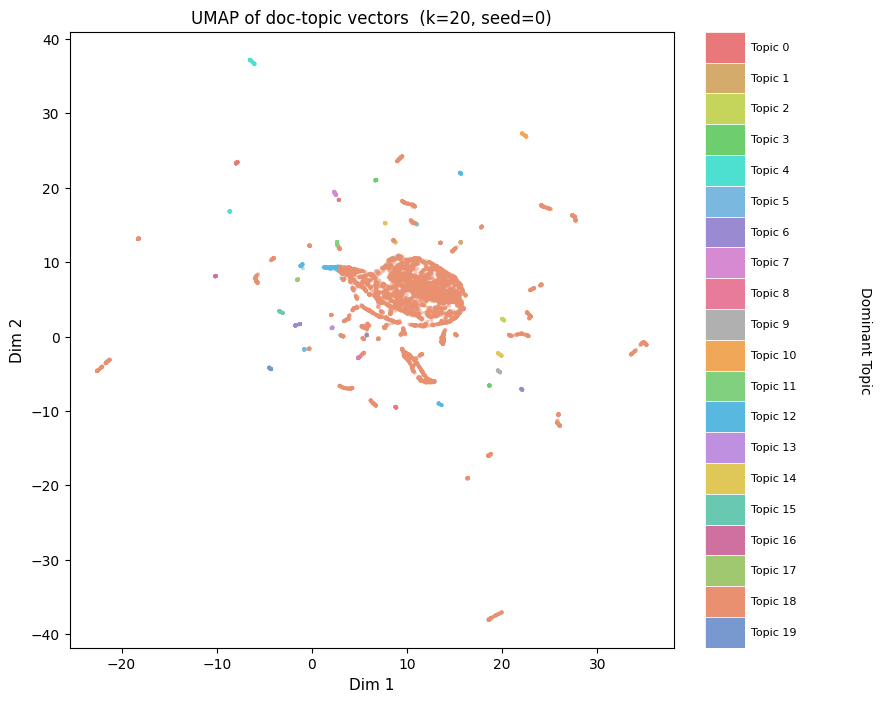

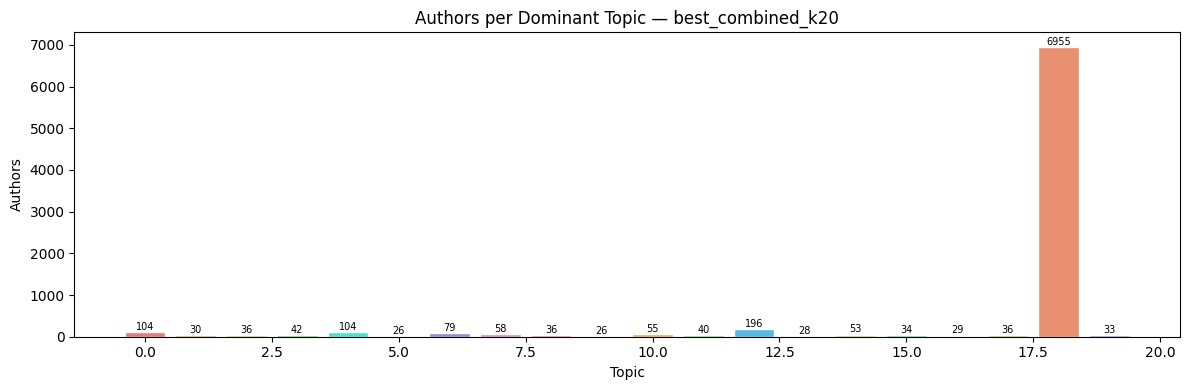

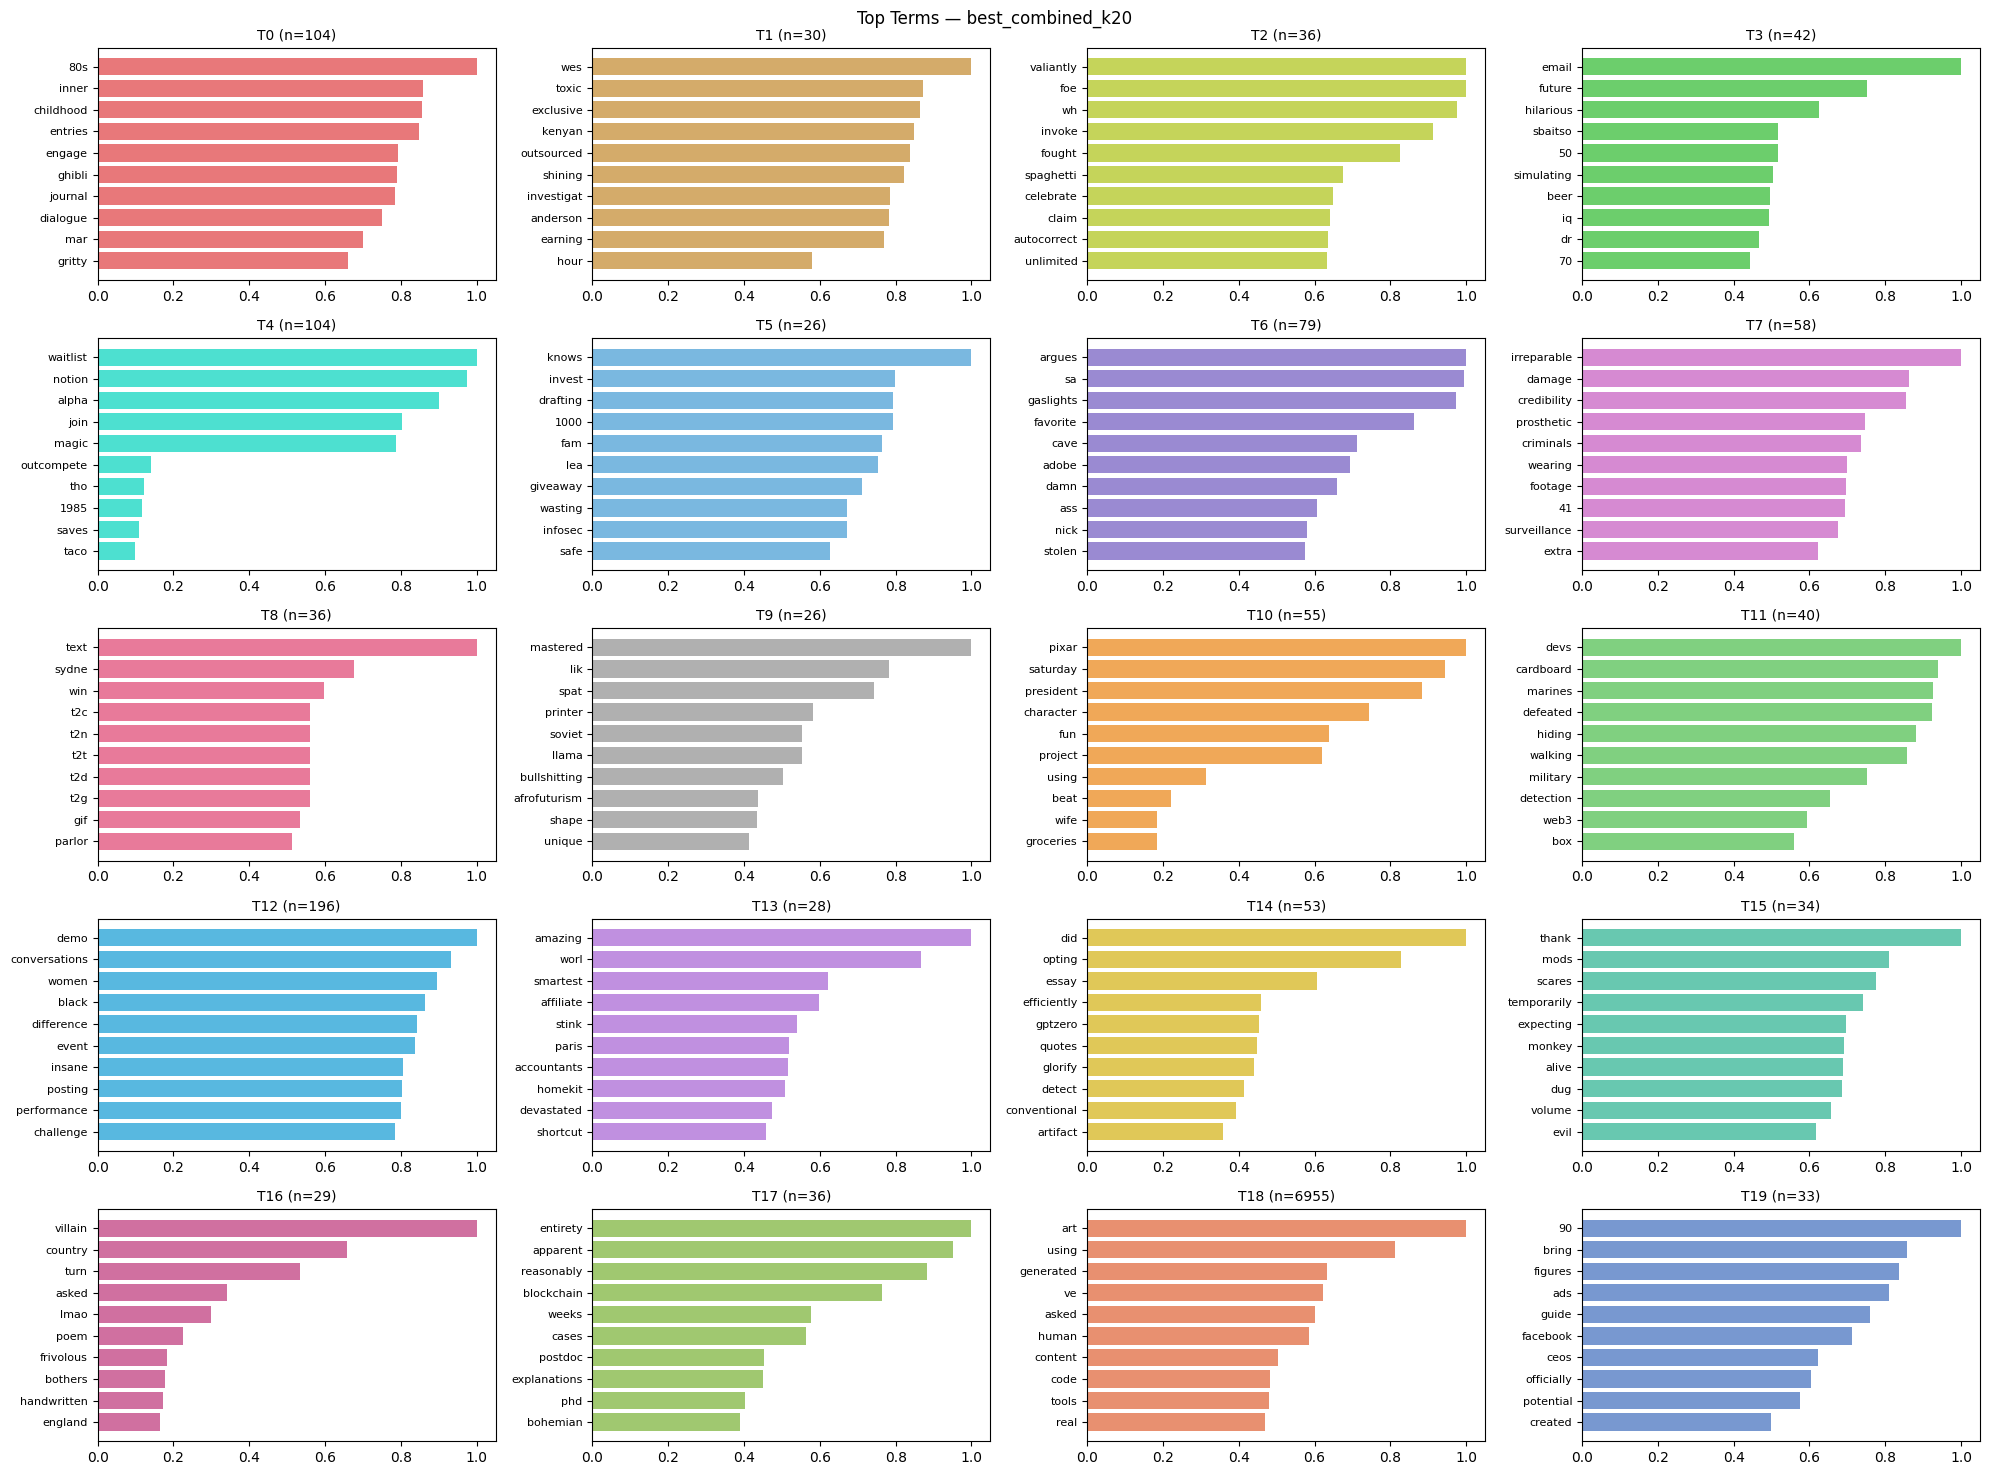


  lowest_catchall_k12: tfidf_unigram K=12 α=0.3 η=0.01
  T 0 (n=  373,  4.7%): did, song, better, asked, amazing, llama, impressive, movie, style, generated
  T 1 (n=  278,  3.5%): gt, art, saying, generated, bert, play, stop, man, funny, self
  T 2 (n=  298,  3.7%): fun, using, project, character, replace, cases, tried, pixar, president, saturday
  T 3 (n=  517,  6.5%): art, useful, aiart, called, weird, guess, cool, line, isn, image
  T 4 (n=  352,  4.4%): asked, questions, asking, talking, crypto, test, bias, political, having, turn
  T 5 (n=  448,  5.6%): models, language, large, industry, diffusion, web, agi, released, stable, bard
  T 6 (n=  237,  3.0%): fingers, shows, essays, generated, students, 30, joke, healthcare, idea, free
  T 7 (n= 4338, 54.2%): using, ve, content, human, tools, code, art, great, notion, join
  T 8 (n=  244,  3.0%): real, 2022, asked, midjourney, favorite, generated, image, prompt, generator, current
  T 9 (n=  298,  3.7%): email, bard, written, future,

/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/envs/twitter-ai/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved → /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots_styled/umap_lowest_catchall_k12.png


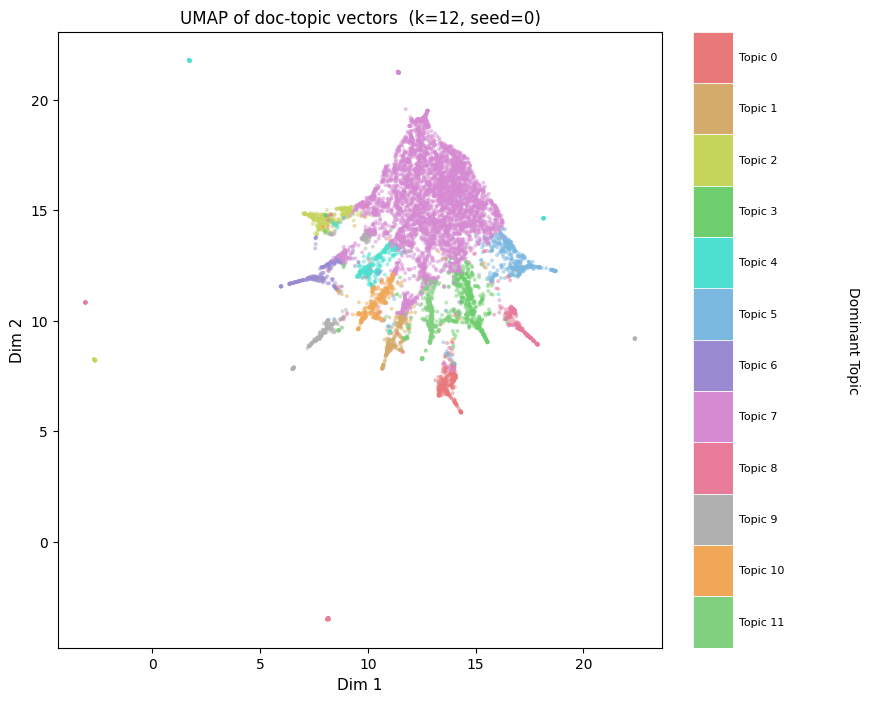

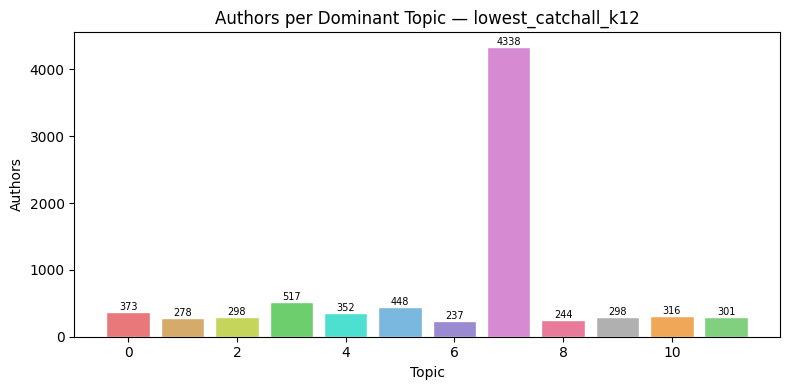

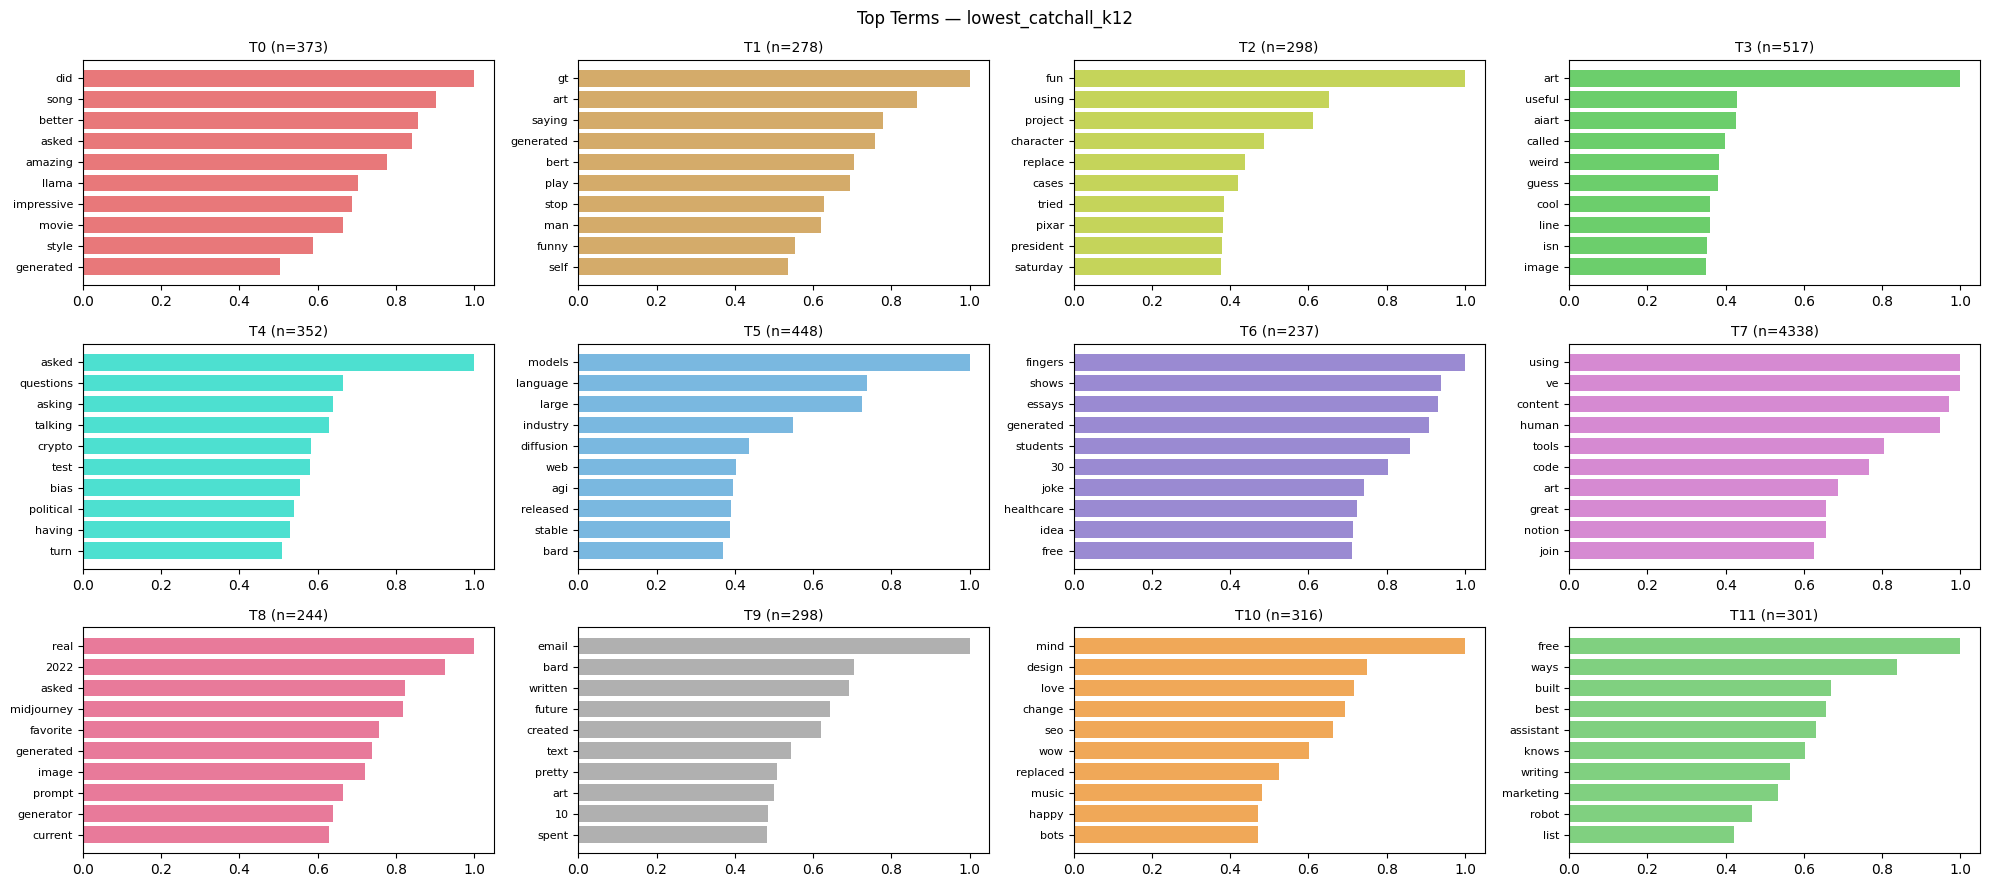


  compact_k8: tfidf_bigram K=8 α=0.01 η=0.1
  T 0 (n=  245,  3.1%): waitlist, notion, alpha, magic, join, prosthetic, criminals, wearing, footage, surveillance
  T 1 (n=  120,  1.5%): shudu, hired, industry, means, entirety, kenyan, toxic, outsourced, apparent, ways
  T 2 (n=   90,  1.1%): detection, celebrate, unlimited, cardboard, marines, defeated, free, hiding, walking, newest
  T 3 (n=  124,  1.6%): pixar, saturday, president, character, fun, project, addy, llama, using, opting
  T 4 (n=   96,  1.2%): argues, gaslights, sa, favorite, 2022, current, beat, tec, fav, humanartists
  T 5 (n=   95,  1.2%): email, patterns, future, interact, expected, slides, wake, translation, accessible, quote
  T 6 (n= 7128, 89.1%): art, using, generated, asked, ve, human, content, tools, code, real
  T 7 (n=  102,  1.3%): irreparable, damage, outcompete, credibility, sees, engineers, fb, political, months, effectively

  Largest topic: 89.1%


/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/envs/twitter-ai/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved → /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots_styled/umap_compact_k8.png


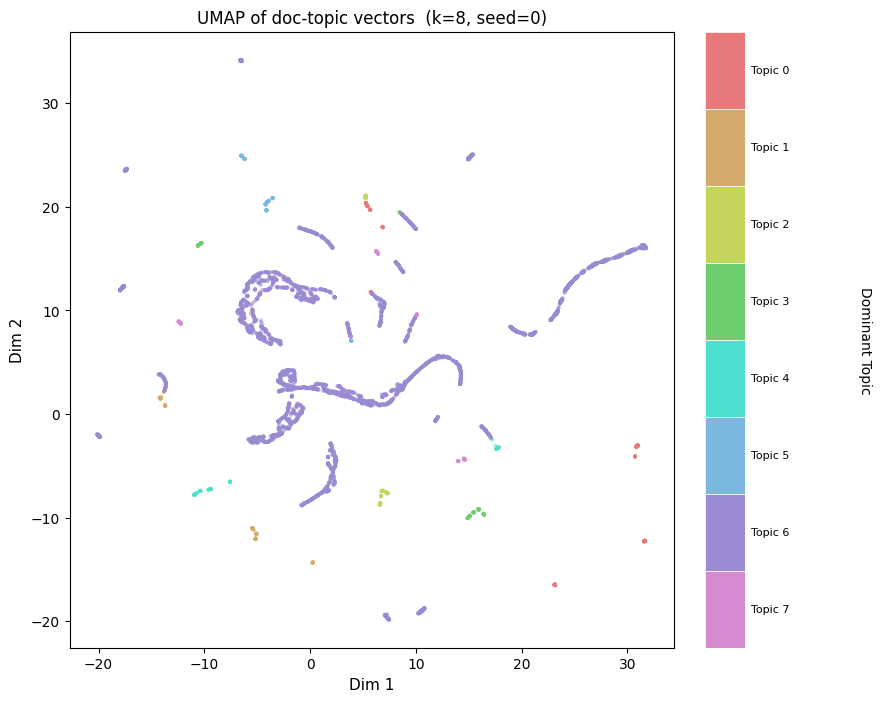

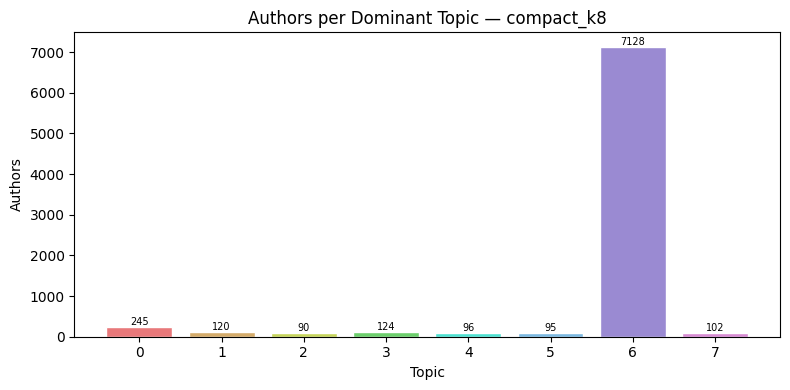

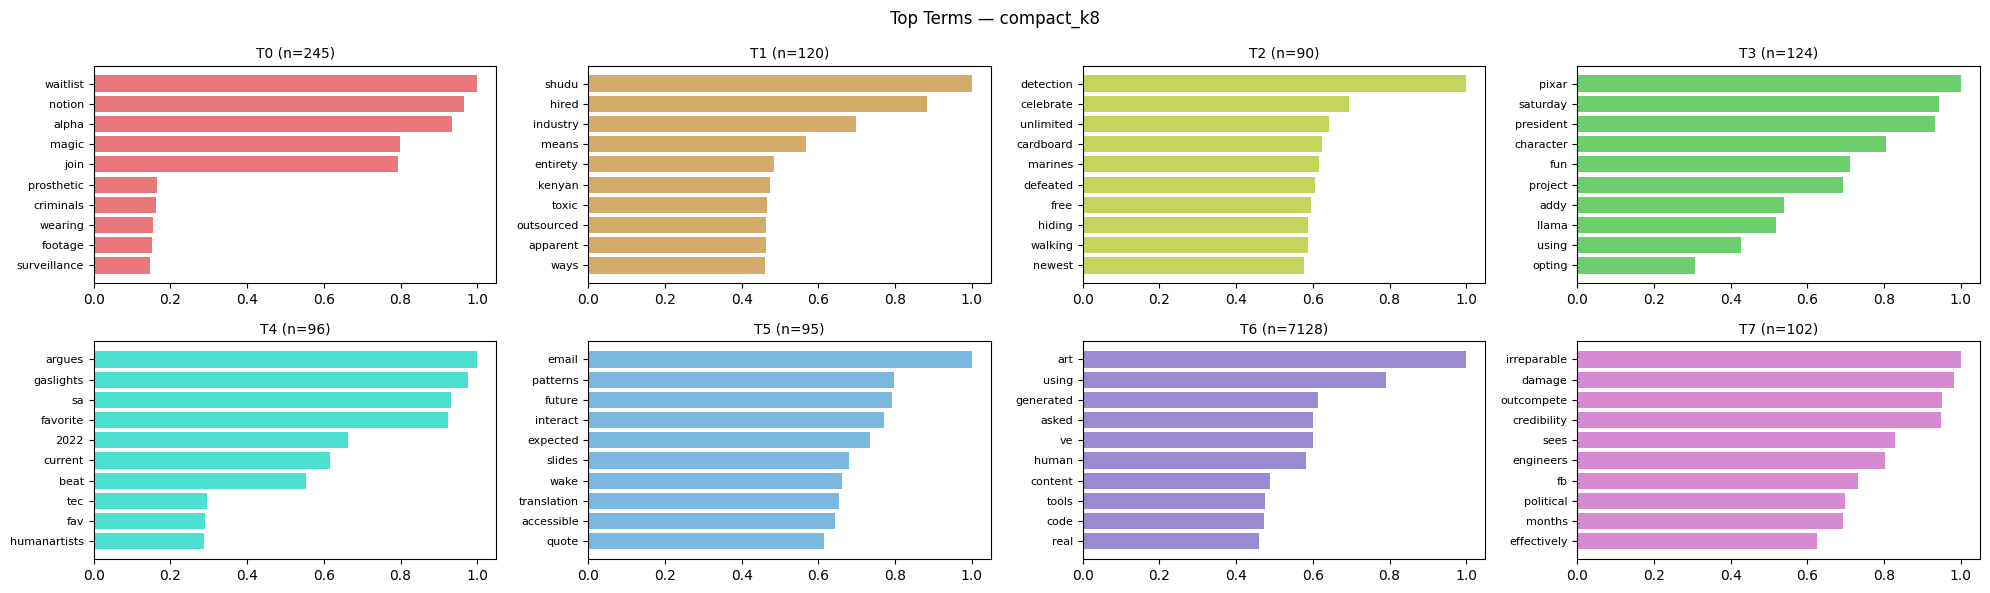


✓ Done — all plots saved to /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots_styled


In [36]:
%%time
# ══════════════════════════════════════════════════════════════
# CELL 3: Fit 3 models + all visuals
# ══════════════════════════════════════════════════════════════
 
models = [
    ("tfidf_bigram",  vec_bi_v3,  X_bi_v3,  20, 0.10, 0.10, "best_combined_k20"),
    ("tfidf_unigram", vec_uni_v3, X_uni_v3, 12, 0.30, 0.01, "lowest_catchall_k12"),
    ("tfidf_bigram",  vec_bi_v3,  X_bi_v3,   8, 0.01, 0.10, "compact_k8"),
]
 
for rep, vec, X, K, alpha, eta, label in models:
    fn = vec.get_feature_names_out()
 
    print(f"\n{'='*70}")
    print(f"  {label}: {rep} K={K} α={alpha} η={eta}")
    print(f"{'='*70}")
 
    lda = LatentDirichletAllocation(
        n_components=K, doc_topic_prior=alpha, topic_word_prior=eta,
        max_iter=50, random_state=42, learning_method='batch', verbose=0)
    lda.fit(X)
    theta = lda.transform(X)
    dom = theta.argmax(axis=1)
 
    for t in range(K):
        top_idx = lda.components_[t].argsort()[:-11:-1]
        terms = [fn[i] for i in top_idx]
        n = (dom == t).sum()
        print(f"  T{t:2d} (n={n:5d}, {n/len(dom):5.1%}): {', '.join(terms)}")
 
    largest_pct = np.max(np.bincount(dom)) / len(dom)
    print(f"\n  Largest topic: {largest_pct:.1%}")
 
    # Save theta
    a_tag = str(alpha).replace('.','p'); e_tag = str(eta).replace('.','p')
    model_dir = OUT_DIR / rep; model_dir.mkdir(parents=True, exist_ok=True)
    df_t = pd.DataFrame(theta, columns=[f"topic_{i}" for i in range(K)])
    df_t.insert(0, "author_id", author_ids)
    df_t.to_csv(model_dir / f"theta_v3stopwords_{rep}_k{K}_a{a_tag}_e{e_tag}.csv", index=False)
 
    # Styled UMAP
    topic_labels = [f"Topic {i}" for i in range(K)]
    plot_umap_styled(theta, topic_labels, K,
                     save_path=PLOT_DIR / f"umap_{label}.png", seed=0)
 
    # Topic sizes
    sizes = pd.Series(dom).value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(max(8, K*0.6), 4))
    bars = ax.bar(sizes.index, sizes.values,
                  color=[TOPIC_COLORS[i%len(TOPIC_COLORS)] for i in sizes.index], edgecolor='white')
    ax.set_xlabel('Topic'); ax.set_ylabel('Authors')
    ax.set_title(f'Authors per Dominant Topic — {label}')
    for bar, count in zip(bars, sizes.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                str(count), ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"sizes_{label}.png", dpi=150)
    plt.show()
 
    # Top terms
    ncols = min(4, K); nrows = math.ceil(K / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows))
    axes = np.array(axes).flatten() if K > 1 else [axes]
    for t_idx in range(K):
        top_idx = lda.components_[t_idx].argsort()[:-11:-1]
        terms = [fn[i] for i in top_idx]
        weights = [lda.components_[t_idx][j] for j in top_idx]
        w_max = max(weights)
        axes[t_idx].barh(terms[::-1], [w/w_max for w in weights[::-1]],
                         color=TOPIC_COLORS[t_idx % len(TOPIC_COLORS)])
        axes[t_idx].set_title(f'T{t_idx} (n={(dom==t_idx).sum()})', fontsize=10)
        axes[t_idx].tick_params(axis='y', labelsize=8)
    for t_idx in range(K, len(axes)): axes[t_idx].set_visible(False)
    plt.suptitle(f'Top Terms — {label}', fontsize=12)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'terms_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()
 
print(f"\n✓ Done — all plots saved to {PLOT_DIR}")
 

## Just K = 12 clean up

vocab: 10,821

K=12 v3b (tighter stopwords):

  T 0 (n=  681,  8.5%): tools, code, game, prompts, step, daily, python, blog, writing, voice
  T 1 (n=  318,  4.0%): amazing, seo, talking, essay, diffusion, trained, spent, quickly, stable, weeks
  T 2 (n= 1957, 24.5%): answers, models, answer, llms, coming, language, product, media, created, says
  T 3 (n= 2622, 32.8%): did, image, writing, stuff, isn, years, humans, things, doing, maybe
  T 4 (n=  283,  3.5%): love, artists, bert, hey, sure, cat, elon, night, result, war
  T 5 (n=  271,  3.4%): bard, design, knows, telling, absolutely, guys, adobe, poem, bullshit, wild
  T 6 (n=  289,  3.6%): midjourney, playing, job, examples, llama, wow, movie, goes, thank, prompt
  T 7 (n=  494,  6.2%): notion, join, magic, waitlist, alpha, article, check, questions, book, months
  T 8 (n=  271,  3.4%): replace, email, song, api, education, open, used, turn, saying, hour
  T 9 (n=  253,  3.2%): aiart, jobs, robot, photos, copilot, watch, list, 11, bo

/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/envs/twitter-ai/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved → /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots_styled/umap_k12_v3b_tighter.png


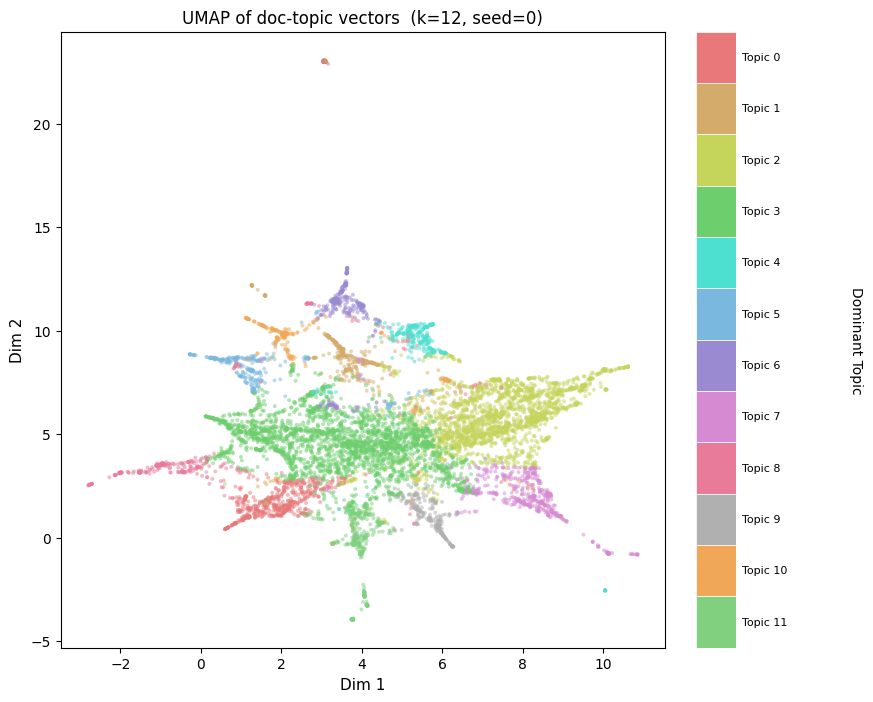

(array([[ 0.9630745,  5.145839 ],
        [ 6.0277524,  5.169568 ],
        [ 1.5970712,  5.365938 ],
        ...,
        [10.044605 , -2.5435529],
        [ 4.4802117,  0.7363569],
        [10.201144 ,  8.084044 ]], shape=(8000, 2), dtype=float32),
 array([3, 2, 3, ..., 4, 2, 2], shape=(8000,)))

In [37]:
%%time
# Add these corpus-wide terms that are still polluting
extra_stops = {
    'using', 'generated', 'asked', 'content', 'human',
    've', 'art', 'free', 'best', 'great', 'better',
    'written', 'future', 'real', 'pretty', 'cool',
    'ways', 'mind', 'change', 'called', 'stop',
    'funny', 'man', 'gt', 'self',
}

stopwords_v3b = sorted(list(set(stopwords_v3) | extra_stops))
stops_set = set(stopwords_v3b)

vec_uni_v3b = TfidfVectorizer(lowercase=True, stop_words=stopwords_v3b,
                               max_df=0.7, min_df=5, ngram_range=(1,1))
X_uni_v3b = vec_uni_v3b.fit_transform(corpus)
print(f"vocab: {X_uni_v3b.shape[1]:,}")

lda = LatentDirichletAllocation(
    n_components=12, doc_topic_prior=0.3, topic_word_prior=0.01,
    max_iter=50, random_state=42, learning_method='batch', verbose=0)
lda.fit(X_uni_v3b)
theta = lda.transform(X_uni_v3b)
dom = theta.argmax(axis=1)

fn = vec_uni_v3b.get_feature_names_out()
print("\nK=12 v3b (tighter stopwords):\n")
for t in range(12):
    top_idx = lda.components_[t].argsort()[:-11:-1]
    terms = [fn[i] for i in top_idx]
    n = (dom == t).sum()
    print(f"  T{t:2d} (n={n:5d}, {n/len(dom):5.1%}): {', '.join(terms)}")

print(f"\nLargest topic: {np.max(np.bincount(dom))/len(dom):.1%}")

plot_umap_styled(theta, [f"Topic {i}" for i in range(12)], 12,
                 save_path=PLOT_DIR / "umap_k12_v3b_tighter.png", seed=0)

K=12 α=0.3 η=0.01 (v3 stopwords):

  T 0 (n=  373,  4.7%): did, song, better, asked, amazing, llama, impressive, movie, style, generated
  T 1 (n=  278,  3.5%): gt, art, saying, generated, bert, play, stop, man, funny, self
  T 2 (n=  298,  3.7%): fun, using, project, character, replace, cases, tried, pixar, president, saturday
  T 3 (n=  517,  6.5%): art, useful, aiart, called, weird, guess, cool, line, isn, image
  T 4 (n=  352,  4.4%): asked, questions, asking, talking, crypto, test, bias, political, having, turn
  T 5 (n=  448,  5.6%): models, language, large, industry, diffusion, web, agi, released, stable, bard
  T 6 (n=  237,  3.0%): fingers, shows, essays, generated, students, 30, joke, healthcare, idea, free
  T 7 (n= 4338, 54.2%): using, ve, content, human, tools, code, art, great, notion, join
  T 8 (n=  244,  3.0%): real, 2022, asked, midjourney, favorite, generated, image, prompt, generator, current
  T 9 (n=  298,  3.7%): email, bard, written, future, created, text, prett

/projects/ComputationalPhilosophyLab/TwitterDataAnalysis/envs/twitter-ai/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved → /projects/ComputationalPhilosophyLab/TwitterDataAnalysis/Models/Topic Modeling/LDA/author_level/full_v2_cleaned/plots_styled/umap_k12_v3stopwords.png


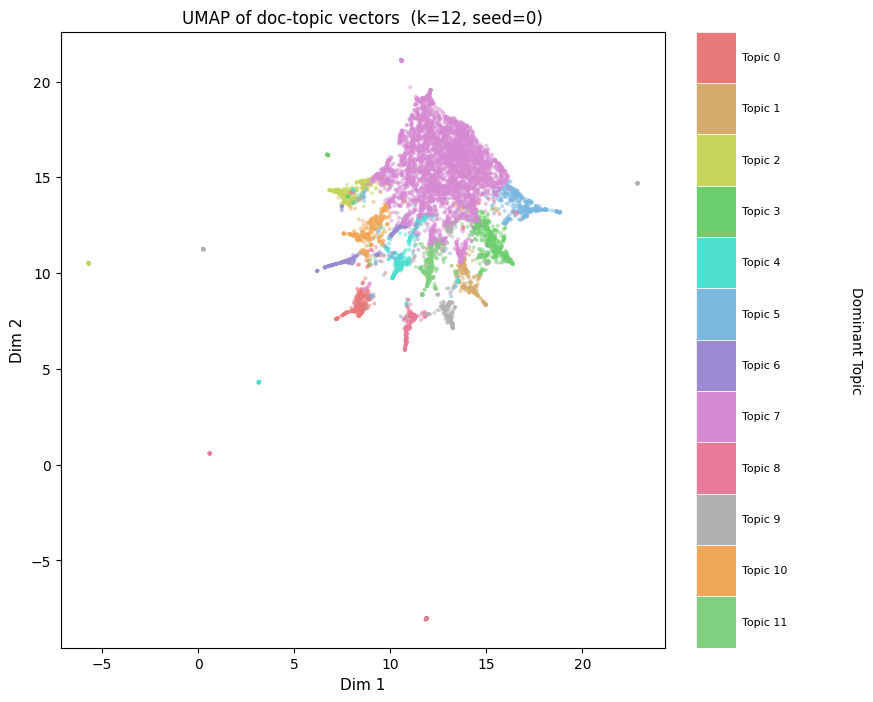

(array([[13.395004 ,  8.234971 ],
        [12.984138 , 14.45482  ],
        [12.123273 , 12.088196 ],
        ...,
        [11.974396 , 19.11082  ],
        [ 7.9835835, 14.146002 ],
        [ 7.0140724, 10.424047 ]], shape=(8000, 2), dtype=float32),
 array([9, 7, 7, ..., 7, 2, 6], shape=(8000,)))

In [38]:
%%time
PLOT_DIR = OUT_DIR / "plots_styled"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

lda = LatentDirichletAllocation(
    n_components=12, doc_topic_prior=0.3, topic_word_prior=0.01,
    max_iter=50, random_state=42, learning_method='batch', verbose=0)
lda.fit(X_uni_v3)
theta = lda.transform(X_uni_v3)
dom = theta.argmax(axis=1)

fn = vec_uni_v3.get_feature_names_out()
print("K=12 α=0.3 η=0.01 (v3 stopwords):\n")
for t in range(12):
    top_idx = lda.components_[t].argsort()[:-11:-1]
    terms = [fn[i] for i in top_idx]
    n = (dom == t).sum()
    print(f"  T{t:2d} (n={n:5d}, {n/len(dom):5.1%}): {', '.join(terms)}")

print(f"\nLargest topic: {np.max(np.bincount(dom))/len(dom):.1%}")

topic_labels = [f"Topic {i}" for i in range(12)]
plot_umap_styled(theta, topic_labels, 12,
                 save_path=PLOT_DIR / "umap_k12_v3stopwords.png", seed=0)

In [ ]:
# Disconnect from Colab runtime (no-op locally)
try:
    from google.colab import runtime
    runtime.unassign()
except ImportError:
    pass
